# Imports & Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from matplotlib.colors import to_rgba

In [2]:
# ── Load data ────────────────────────────────────────────────
df = pd.read_csv("9thCLEANED.csv")

In [3]:
print(df.columns)

print(len(df.columns))


Index(['X4EVERDROP', 'X1MTHEFF', 'X1SCIEFF', 'X1TXMTSCOR', 'S1M8GRADE',
       'S1S8GRADE', 'X1PAREDU', 'X1PAREDEXPCT', 'X1SCHOOLBEL', 'S1PLAN',
       'X1SCHOOLCLI', 'X1POVERTY', 'X1LOCALE', 'X1RACE', 'X1CONTROL',
       'X1REGION', 'S1EDUEXPECT', 'S1SUREHSGRAD', 'X1FAMINCOME', 'X2SEX',
       'S1FYAA', 'S1FYBA', 'S1FYLICENSE', 'S1FYAPPR', 'S1FYMILITARY',
       'S1FYJOB', 'S1FYFAMILY', 'S1FYTRAVEL', 'S1FYVOLUN', 'S1FYNOTSURE',
       'S1PAYOFF', 'S1GETINTOCLG', 'S1AFFORD', 'S1WORKING', 'STU_ID',
       'X1PAR_SURVEY_MISSING', 'X1_DUAL_PARENT', 'MATH_NO_CLASS',
       'SCI_NO_CLASS'],
      dtype='object')
39


# EDA - Step 1: Target Variable Analysis (X4EVERDROP)

  TARGET VARIABLE SUMMARY  (X4EVERDROP)
  Total students        : 15,900
  Dropout     (1)       : 2,443  (15.4%)
  No dropout  (0)       : 13,457  (84.6%)
  Imbalance ratio (0:1) : 5.5 : 1


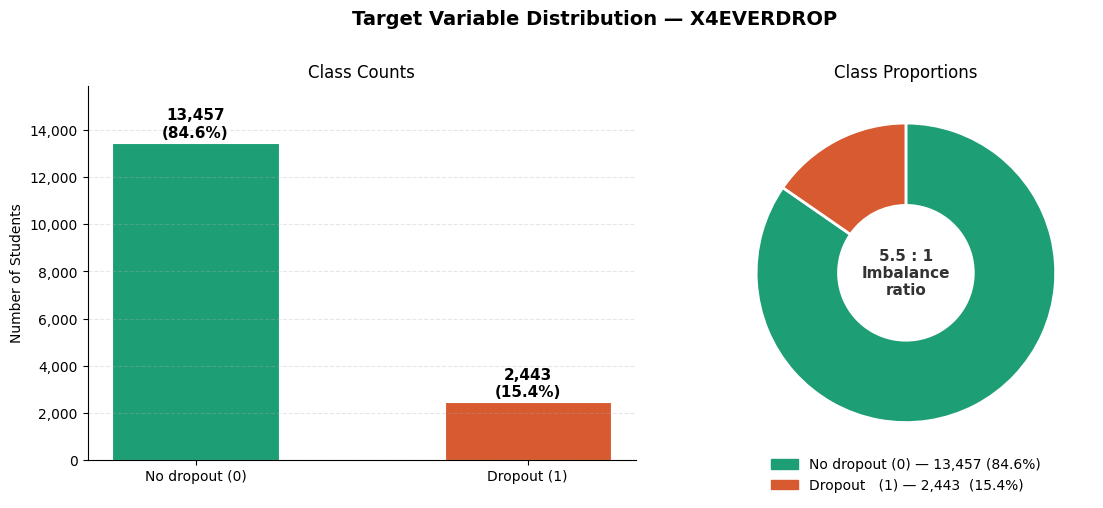


Plot saved → step1_target_variable.png


In [4]:
# ── Core counts ──────────────────────────────────────────────
total       = len(df)
dropped     = int(df["X4EVERDROP"].sum())
not_dropped = total - dropped
pct_drop    = dropped / total * 100
pct_no      = not_dropped / total * 100
ratio       = not_dropped / dropped

print("=" * 45)
print("  TARGET VARIABLE SUMMARY  (X4EVERDROP)")
print("=" * 45)
print(f"  Total students        : {total:,}")
print(f"  Dropout     (1)       : {dropped:,}  ({pct_drop:.1f}%)")
print(f"  No dropout  (0)       : {not_dropped:,}  ({pct_no:.1f}%)")
print(f"  Imbalance ratio (0:1) : {ratio:.1f} : 1")
print("=" * 45)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable Distribution — X4EVERDROP", fontsize=14, fontweight="bold", y=1.01)

COLORS = {"no_drop": "#1D9E75", "drop": "#D85A30"}

# --- Left: Bar chart ---
ax1 = axes[0]
bars = ax1.bar(
    ["No dropout (0)", "Dropout (1)"],
    [not_dropped, dropped],
    color=[COLORS["no_drop"], COLORS["drop"]],
    edgecolor="white",
    linewidth=0.8,
    width=0.5
)

# Annotate bars
for bar, count, pct in zip(bars, [not_dropped, dropped], [pct_no, pct_drop]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 120,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax1.set_title("Class Counts", fontsize=12)
ax1.set_ylabel("Number of Students")
ax1.set_ylim(0, not_dropped * 1.18)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", alpha=0.3, linestyle="--")

# --- Right: Pie / Donut chart ---
ax2 = axes[1]
wedge_sizes  = [not_dropped, dropped]
wedge_colors = [COLORS["no_drop"], COLORS["drop"]]
wedge_labels = [f"No dropout\n{pct_no:.1f}%", f"Dropout\n{pct_drop:.1f}%"]

wedges, texts = ax2.pie(
    wedge_sizes,
    labels=None,
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    counterclock=False
)

# Centre annotation
ax2.text(0, 0, f"{ratio:.1f} : 1\nImbalance\nratio", ha="center", va="center",
         fontsize=11, fontweight="bold", color="#333333")

ax2.set_title("Class Proportions", fontsize=12)

legend_patches = [
    mpatches.Patch(color=COLORS["no_drop"], label=f"No dropout (0) — {not_dropped:,} ({pct_no:.1f}%)"),
    mpatches.Patch(color=COLORS["drop"],    label=f"Dropout   (1) — {dropped:,}  ({pct_drop:.1f}%)")
]
ax2.legend(handles=legend_patches, loc="lower center",
           bbox_to_anchor=(0.5, -0.12), fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("step1_target_variable.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → step1_target_variable.png")

Key takeaways from Step 1:

- 15,900 students total — 2,443 (15.4%) dropout, 13,457 (84.6%) no dropout
- 5.5:1 imbalance ratio — a naive "always predict no dropout" model would be 84.6% accurate but useless
- Modeling must account for this: class weighting, SMOTE, or threshold tuning; and evaluation should focus on F1, Recall, and ROC-AUC over raw accuracy.

Hypothesis: Because missing a true at-risk student is far costlier than a false alarm from a school intervention standpoint, models optimized for recall on the dropout class will be more practically valuable. We expect class weighting or oversampling to meaningfully improve minority class detection without significantly hurting overall performance.

# EDA - Step 2: Missing Data Analysis

In [5]:
for col in ['X1SCIEFF', 'X1MTHEFF']:
    # Calculate null statistics
    nan_count = df[col].isnull().sum()
    nan_percent = df[col].isnull().mean() * 100

    print(f"--- Statistics for {col} ---")
    print(f"Number of NaN values: {nan_count}")
    print(f"Percentage of NaN values: {nan_percent:.2f}%")

    # Optional: Display unique values to check for other missing codes (like -9)
    print(f"Unique values: {sorted(df[col].unique())}")
    print("-" * 30)

--- Statistics for X1SCIEFF ---
Number of NaN values: 2526
Percentage of NaN values: 15.89%
Unique values: [np.float64(-2.91), np.float64(-2.49), np.float64(-2.48), np.float64(-2.19), np.float64(-2.17), np.float64(-2.08), np.float64(-2.07), np.float64(-2.06), np.float64(-2.05), np.float64(-2.04), np.float64(-1.88), np.float64(-1.75), np.float64(-1.74), np.float64(-1.63), np.float64(-1.62), np.float64(-1.61), np.float64(-1.34), np.float64(-1.33), np.float64(-1.3), np.float64(-1.23), np.float64(-1.22), np.float64(-1.21), np.float64(-1.2), np.float64(-1.02), np.float64(-0.91), np.float64(-0.9), np.float64(-0.89), np.float64(-0.78), np.float64(-0.77), np.float64(-0.75), np.float64(-0.61), np.float64(-0.59), np.float64(-0.58), np.float64(-0.57), np.float64(-0.49), np.float64(-0.48), np.float64(-0.47), np.float64(-0.46), np.float64(-0.44), np.float64(-0.18), np.float64(-0.17), np.float64(-0.16), np.float64(-0.05), np.float64(-0.03), np.float64(0.05), np.float64(0.066042468072011), np.float64

  MISSING DATA SUMMARY — Wave 1 Features
                Missing Count  Missing %                                              Type
X1FAMINCOME              3017      18.97                 MNAR — parent did not take survey
X1POVERTY                3017      18.97                 MNAR — parent did not take survey
X1PAREDEXPCT             3017      18.97                 MNAR — parent did not take survey
X1PAREDU                 3017      18.97                 MNAR — parent did not take survey
X1_DUAL_PARENT           3017      18.97                 MNAR — parent did not take survey
X1SCIEFF                 2526      15.89  Structural — student did not take Science course
X1MTHEFF                 1476       9.28     Structural — student did not take Math course

Columns with no missing values : 29 / 36
Columns with missing values    : 7 / 36

  STRUCTURAL MISSINGNESS — No-Course Students

  X1MTHEFF
    NaN count                      : 1,476
    MATH_NO_CLASS == 1          : 1,476   [Exac

/tmp/ipykernel_6870/4213604959.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


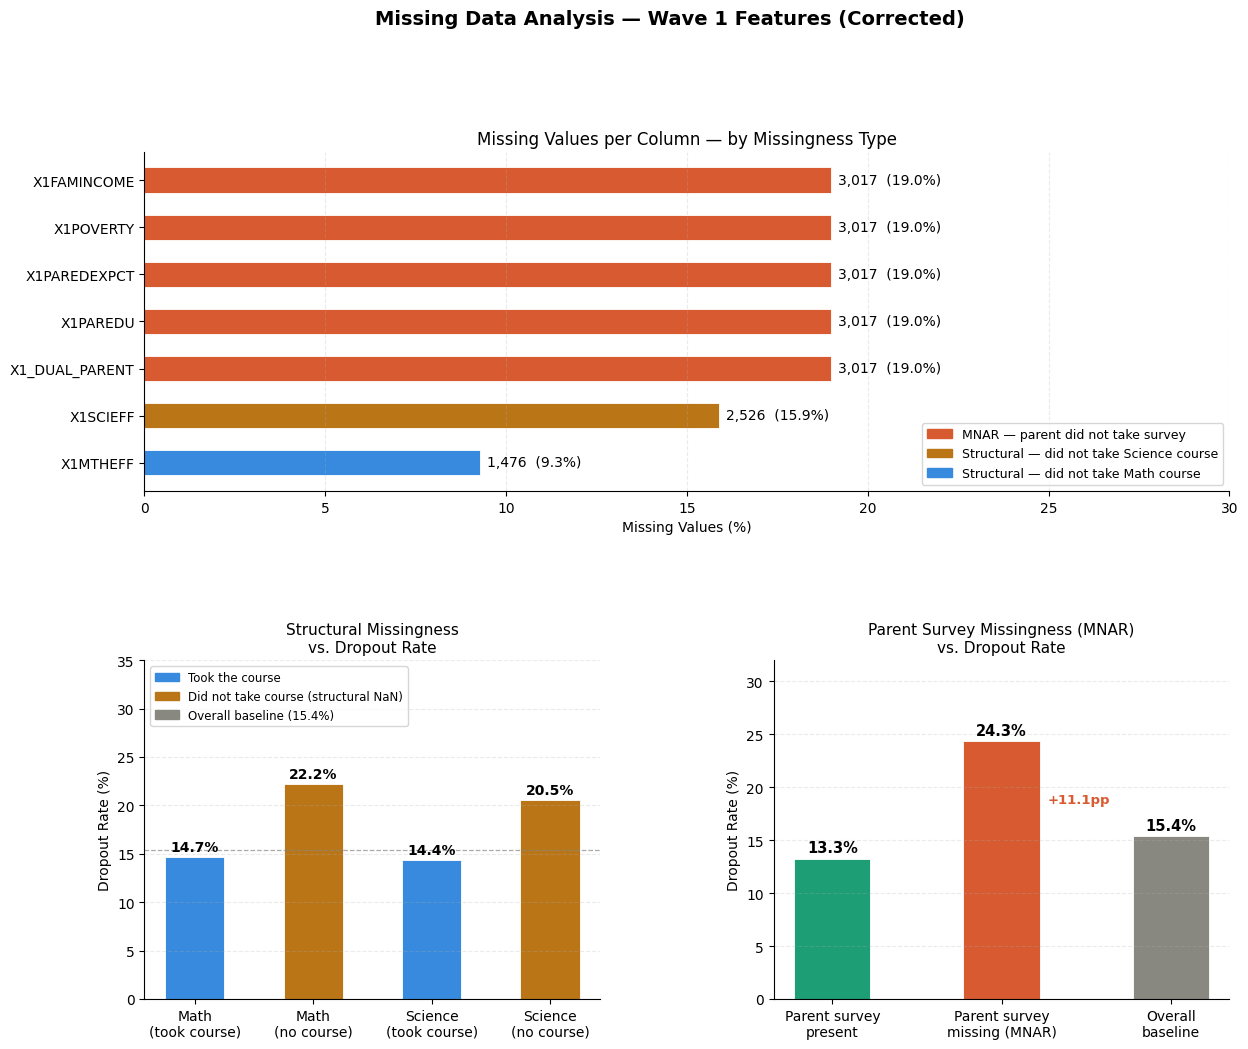


Plot saved → step2_missing_data.png


In [6]:
# ── Feature lists ─────────────────────────────────────────────
wave1_cols = [c for c in df.columns if c.startswith("X1") or c.startswith("S1")]
engineered = ["MATH_NO_CLASS", "SCI_NO_CLASS"]
all_w1 = wave1_cols + engineered

# ── Dynamic baseline dropout rate ────────────────────────────
baseline = df["X4EVERDROP"].mean() * 100

# ── Missing summary ───────────────────────────────────────────
miss_count = df[all_w1].isnull().sum().sort_values(ascending=False)
miss_pct   = (miss_count / len(df) * 100).round(2)
miss_df    = pd.DataFrame({"Missing Count": miss_count, "Missing %": miss_pct})
miss_df    = miss_df[miss_df["Missing Count"] > 0]

miss_type = {
    "X1PAREDEXPCT"  : "MNAR — parent did not take survey",
    "X1PAREDU"      : "MNAR — parent did not take survey",
    "X1_DUAL_PARENT": "MNAR — parent did not take survey",
    "X1FAMINCOME"   : "MNAR — parent did not take survey",
    "X1POVERTY"     : "MNAR — parent did not take survey",
    "X1SCIEFF"      : "Structural — student did not take Science course",
    "X1MTHEFF"      : "Structural — student did not take Math course",
}
miss_df["Type"] = miss_df.index.map(miss_type)

print("=" * 65)
print("  MISSING DATA SUMMARY — Wave 1 Features")
print("=" * 65)
print(miss_df.to_string())
print(f"\nColumns with no missing values : {(miss_count == 0).sum()} / {len(all_w1)}")
print(f"Columns with missing values    : {(miss_count > 0).sum()} / {len(all_w1)}")

# ── Structural missingness: no-course students ────────────────
print("\n" + "=" * 65)
print("  STRUCTURAL MISSINGNESS — No-Course Students")
print("=" * 65)
for col, flag in [("X1MTHEFF", "MATH_NO_CLASS"), ("X1SCIEFF", "SCI_NO_CLASS")]:
    n_flag     = int(df[flag].sum())
    n_nan      = int(df[col].isnull().sum())
    dr_noclass = df.loc[df[flag] == 1, "X4EVERDROP"].mean() * 100
    dr_class   = df.loc[df[flag] == 0, "X4EVERDROP"].mean() * 100
    match      = "Exact match" if n_flag == n_nan else f"Mismatch ({n_flag} vs {n_nan})"
    print(f"\n  {col}")
    print(f"    NaN count                      : {n_nan:,}")
    print(f"    {flag} == 1          : {n_flag:,}   [{match}]")
    print(f"    Dropout rate (no course taken) : {dr_noclass:.1f}%")
    print(f"    Dropout rate (course taken)    : {dr_class:.1f}%")
    print(f"    Difference                     : +{dr_noclass - dr_class:.1f}pp")

# ── Parent-survey missingness ─────────────────────────────────
print("\n" + "=" * 65)
print("  PARENT-SURVEY MISSINGNESS  (MNAR)")
print("=" * 65)
n_par_miss     = int(df["X1PAR_SURVEY_MISSING"].sum())
pct_par_miss   = n_par_miss / len(df) * 100
dr_par_miss    = df.loc[df["X1PAR_SURVEY_MISSING"] == 1, "X4EVERDROP"].mean() * 100
dr_par_present = df.loc[df["X1PAR_SURVEY_MISSING"] == 0, "X4EVERDROP"].mean() * 100

print(f"  Rows where parent did not survey : {n_par_miss:,} ({pct_par_miss:.1f}%)")
print(f"  Dropout rate — parent MISSING    : {dr_par_miss:.1f}%")
print(f"  Dropout rate — parent PRESENT    : {dr_par_present:.1f}%")
print(f"  Difference                       : +{dr_par_miss - dr_par_present:.1f}pp")
print(f"\n  X1PAR_SURVEY_MISSING flag retained as a predictive feature.")
print(f"  Parent-block variables: impute with within-group median (MNAR group separately).")

# ── Handling recommendation summary ──────────────────────────
print("\n" + "=" * 65)
print("  HANDLING RECOMMENDATION SUMMARY")
print("=" * 65)
recs = [
    ("X1MTHEFF",       "Fill NaN with 0 (scale mean); keep MATH_NO_CLASS flag"),
    ("X1SCIEFF",       "Fill NaN with 0 (scale mean); keep SCI_NO_CLASS flag"),
    ("X1PAREDU",       "Impute with within-group median; keep X1PAR_SURVEY_MISSING flag"),
    ("X1PAREDEXPCT",   "Impute with within-group median; keep X1PAR_SURVEY_MISSING flag"),
    ("X1POVERTY",      "Impute with within-group median; keep X1PAR_SURVEY_MISSING flag"),
    ("X1FAMINCOME",    "Impute with within-group median; keep X1PAR_SURVEY_MISSING flag"),
    ("X1_DUAL_PARENT", "Impute with within-group median; keep X1PAR_SURVEY_MISSING flag"),
]
for col, rec in recs:
    print(f"  {col:<18} : {rec}")

# NOTE: X1MTHEFF and X1SCIEFF are standardized scales (mean=0, SD=1).
# Filling NaNs with 0 assigns the scale mean to no-course students.
# This is acceptable here because MATH_NO_CLASS / SCI_NO_CLASS flags
# already distinguish these students from true average-efficacy students.
df["X1MTHEFF"] = df["X1MTHEFF"].fillna(0)
df["X1SCIEFF"] = df["X1SCIEFF"].fillna(0)

# ── Plots ─────────────────────────────────────────────────────
CORAL = "#D85A30"
TEAL  = "#1D9E75"
GRAY  = "#888780"
BLUE  = "#378ADD"
AMBER = "#BA7517"

fig = plt.figure(figsize=(14, 11))
fig.suptitle("Missing Data Analysis — Wave 1 Features (Corrected)",
             fontsize=14, fontweight="bold", y=1.01)
gs = GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.38)

# ── Plot 1: Horizontal bar — missing % with type colour ───────
ax1 = fig.add_subplot(gs[0, :])

color_map = {
    "MNAR — parent did not take survey"                : CORAL,
    "Structural — student did not take Science course" : AMBER,
    "Structural — student did not take Math course"    : BLUE,
}
bar_colors = [color_map[t] for t in miss_df["Type"]]

bars = ax1.barh(miss_df.index, miss_df["Missing %"], color=bar_colors,
                edgecolor="white", linewidth=0.6, height=0.55)
for bar, cnt, pct in zip(bars, miss_df["Missing Count"], miss_df["Missing %"]):
    ax1.text(pct + 0.2, bar.get_y() + bar.get_height() / 2,
             f"{cnt:,}  ({pct:.1f}%)", va="center", fontsize=10)

ax1.set_xlabel("Missing Values (%)")
ax1.set_title("Missing Values per Column — by Missingness Type", fontsize=12)
ax1.set_xlim(0, 30)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="x", alpha=0.25, linestyle="--")
ax1.invert_yaxis()

legend_patches = [
    mpatches.Patch(color=CORAL, label="MNAR — parent did not take survey"),
    mpatches.Patch(color=AMBER, label="Structural — did not take Science course"),
    mpatches.Patch(color=BLUE,  label="Structural — did not take Math course"),
]
ax1.legend(handles=legend_patches, fontsize=9, loc="lower right")

# ── Plot 2: Structural missingness dropout rates ───────────────
ax2 = fig.add_subplot(gs[1, 0])

dr_math_yes = df.loc[df["MATH_NO_CLASS"] == 0, "X4EVERDROP"].mean() * 100
dr_math_no  = df.loc[df["MATH_NO_CLASS"] == 1, "X4EVERDROP"].mean() * 100
dr_sci_yes  = df.loc[df["SCI_NO_CLASS"]  == 0, "X4EVERDROP"].mean() * 100
dr_sci_no   = df.loc[df["SCI_NO_CLASS"]  == 1, "X4EVERDROP"].mean() * 100

labels2 = ["Math\n(took course)", "Math\n(no course)", "Science\n(took course)", "Science\n(no course)"]
vals2   = [dr_math_yes, dr_math_no, dr_sci_yes, dr_sci_no]
cols2   = [BLUE, AMBER, BLUE, AMBER]

bars2 = ax2.bar(labels2, vals2, color=cols2, edgecolor="white", linewidth=0.6, width=0.5)
for bar, v in zip(bars2, vals2):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax2.axhline(y=baseline, color=GRAY, linestyle="--", linewidth=0.9, alpha=0.7)
ax2.set_ylabel("Dropout Rate (%)")
ax2.set_title("Structural Missingness\nvs. Dropout Rate", fontsize=11)
ax2.set_ylim(0, 35)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", alpha=0.25, linestyle="--")

legend2 = [
    mpatches.Patch(color=BLUE,  label="Took the course"),
    mpatches.Patch(color=AMBER, label="Did not take course (structural NaN)"),
    mpatches.Patch(color=GRAY,  label=f"Overall baseline ({baseline:.1f}%)"),
]
ax2.legend(handles=legend2, fontsize=8.5, loc="upper left")

# ── Plot 3: Parent survey missingness dropout rates ───────────
ax3 = fig.add_subplot(gs[1, 1])

groups3 = ["Parent survey\npresent", "Parent survey\nmissing (MNAR)", "Overall\nbaseline"]
rates3  = [dr_par_present, dr_par_miss, baseline]
cols3   = [TEAL, CORAL, GRAY]

bars3 = ax3.bar(groups3, rates3, color=cols3, edgecolor="white",
                linewidth=0.6, width=0.45)
for bar, rate in zip(bars3, rates3):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{rate:.1f}%", ha="center", va="bottom", fontsize=10.5, fontweight="bold")

ax3.annotate("", xy=(1, dr_par_miss), xytext=(1, dr_par_present),
             arrowprops=dict(arrowstyle="<->", color=CORAL, lw=1.5))
ax3.text(1.27, (dr_par_miss + dr_par_present) / 2,
         f"+{dr_par_miss - dr_par_present:.1f}pp", color=CORAL,
         fontsize=9.5, fontweight="bold", va="center")

ax3.set_ylabel("Dropout Rate (%)")
ax3.set_title("Parent Survey Missingness (MNAR)\nvs. Dropout Rate", fontsize=11)
ax3.set_ylim(0, 32)
ax3.spines[["top", "right"]].set_visible(False)
ax3.grid(axis="y", alpha=0.25, linestyle="--")

plt.tight_layout()
plt.savefig("step2_missing_data.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → step2_missing_data.png")

Key takeaways from Step 2:

- There are **two completely different types of missingness** in this dataset, and they must not be handled the same way.

- **The parent-survey block** (5 variables, 3,017 rows, ~19%) is **MNAR** — parents who didn't participate are associated with a 24.3% dropout rate, vs. 13.3% for those who did (+11.1pp). The `X1PAR_SURVEY_MISSING` flag must be kept as a feature. The underlying variables might be imputed using within-group medians to avoid leaking information from the non-missing group.

- The **efficacy columns** (`X1MTHEFF`, `X1SCIEFF`) are **structurally missing** — the NaN count matches the `MATH_NO_CLASS` / `SCI_NO_CLASS` flags exactly (1,476 and 2,526 respectively), confirming these students simply didn't take the course. Students with no Math course drop out at 22.2% (+7.6pp above baseline); no Science course at 20.5% (+6.2pp). These NaNs might be filled with 0, and the flags retained as features.



Hypothesis: The two missingness patterns both point in the same direction — disengagement is a precursor to dropout. A parent who skips the survey and a student who skips a core subject in 9th grade are each showing an early warning signal. We expect `X1PAR_SURVEY_MISSING`, `MATH_NO_CLASS`, and `SCI_NO_CLASS` to appear as meaningful predictors in the final model, not merely as data-quality bookkeeping columns.

# EDA - Step 3: Univariate Distributions

In [7]:
df.columns

Index(['X4EVERDROP', 'X1MTHEFF', 'X1SCIEFF', 'X1TXMTSCOR', 'S1M8GRADE',
       'S1S8GRADE', 'X1PAREDU', 'X1PAREDEXPCT', 'X1SCHOOLBEL', 'S1PLAN',
       'X1SCHOOLCLI', 'X1POVERTY', 'X1LOCALE', 'X1RACE', 'X1CONTROL',
       'X1REGION', 'S1EDUEXPECT', 'S1SUREHSGRAD', 'X1FAMINCOME', 'X2SEX',
       'S1FYAA', 'S1FYBA', 'S1FYLICENSE', 'S1FYAPPR', 'S1FYMILITARY',
       'S1FYJOB', 'S1FYFAMILY', 'S1FYTRAVEL', 'S1FYVOLUN', 'S1FYNOTSURE',
       'S1PAYOFF', 'S1GETINTOCLG', 'S1AFFORD', 'S1WORKING', 'STU_ID',
       'X1PAR_SURVEY_MISSING', 'X1_DUAL_PARENT', 'MATH_NO_CLASS',
       'SCI_NO_CLASS'],
      dtype='object')

In [8]:
df.shape

(15900, 39)

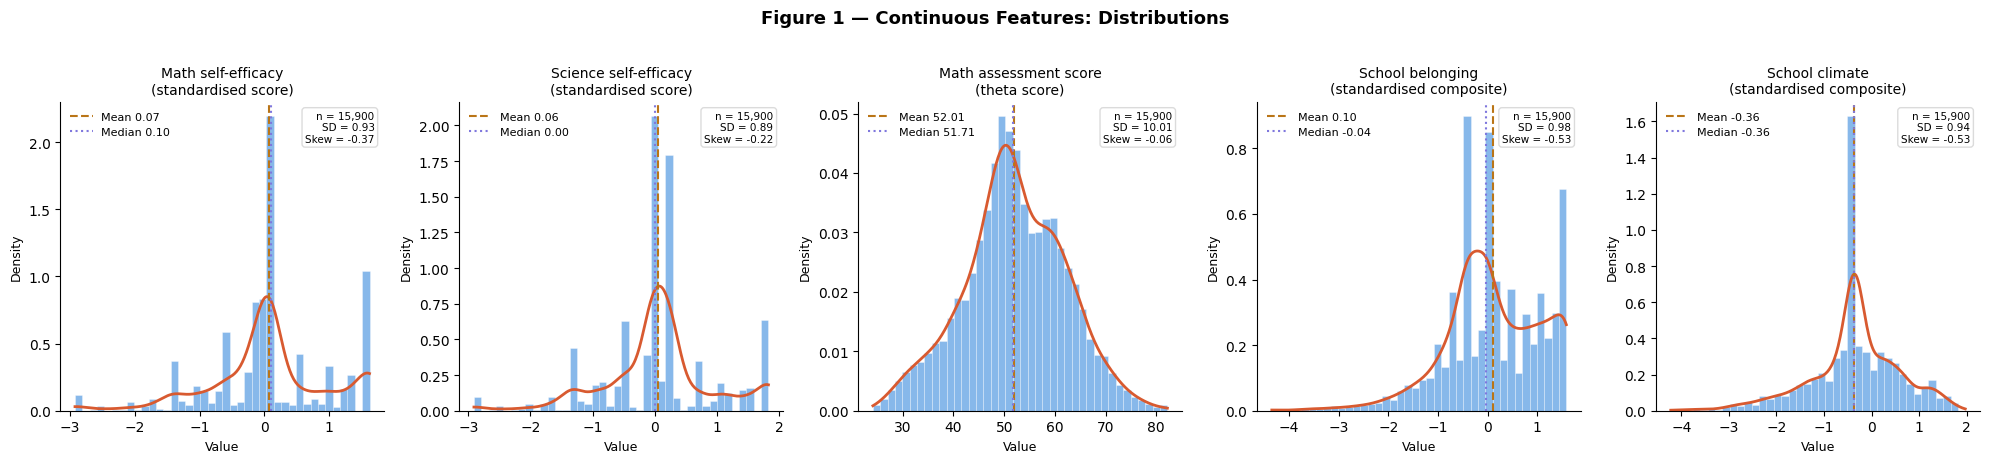

Saved → step3_fig1_continuous.png


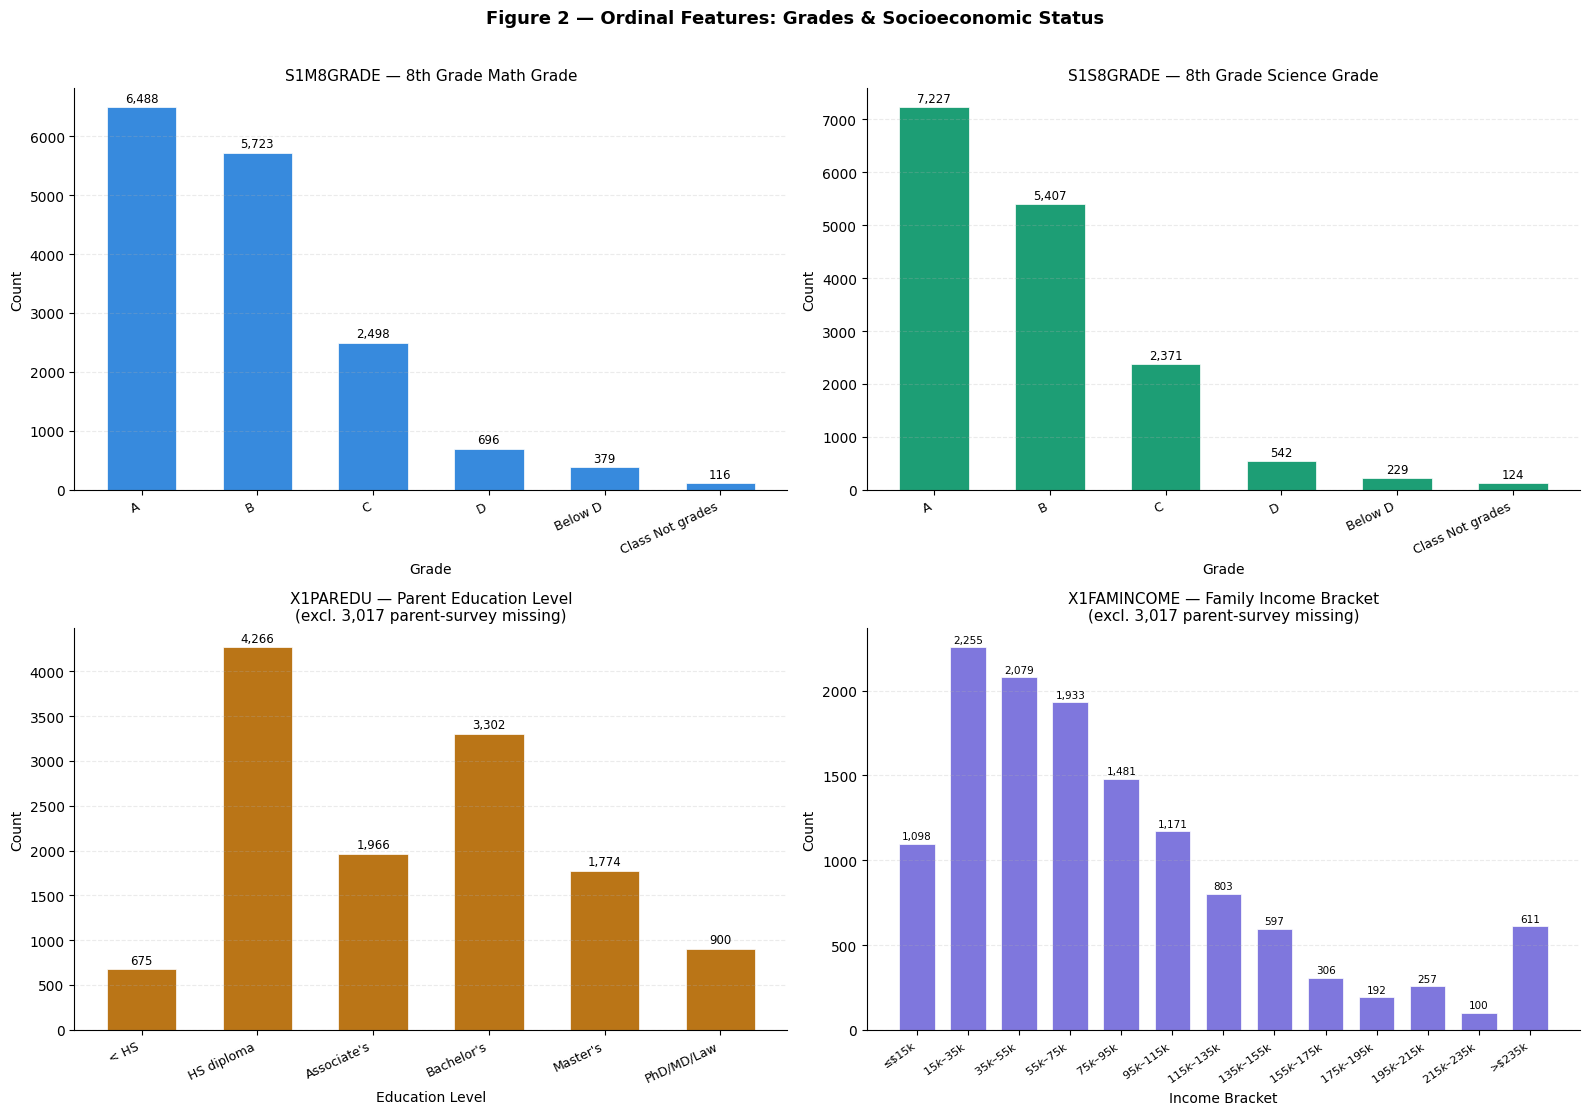

Saved → step3_fig2_ordinal_ses.png


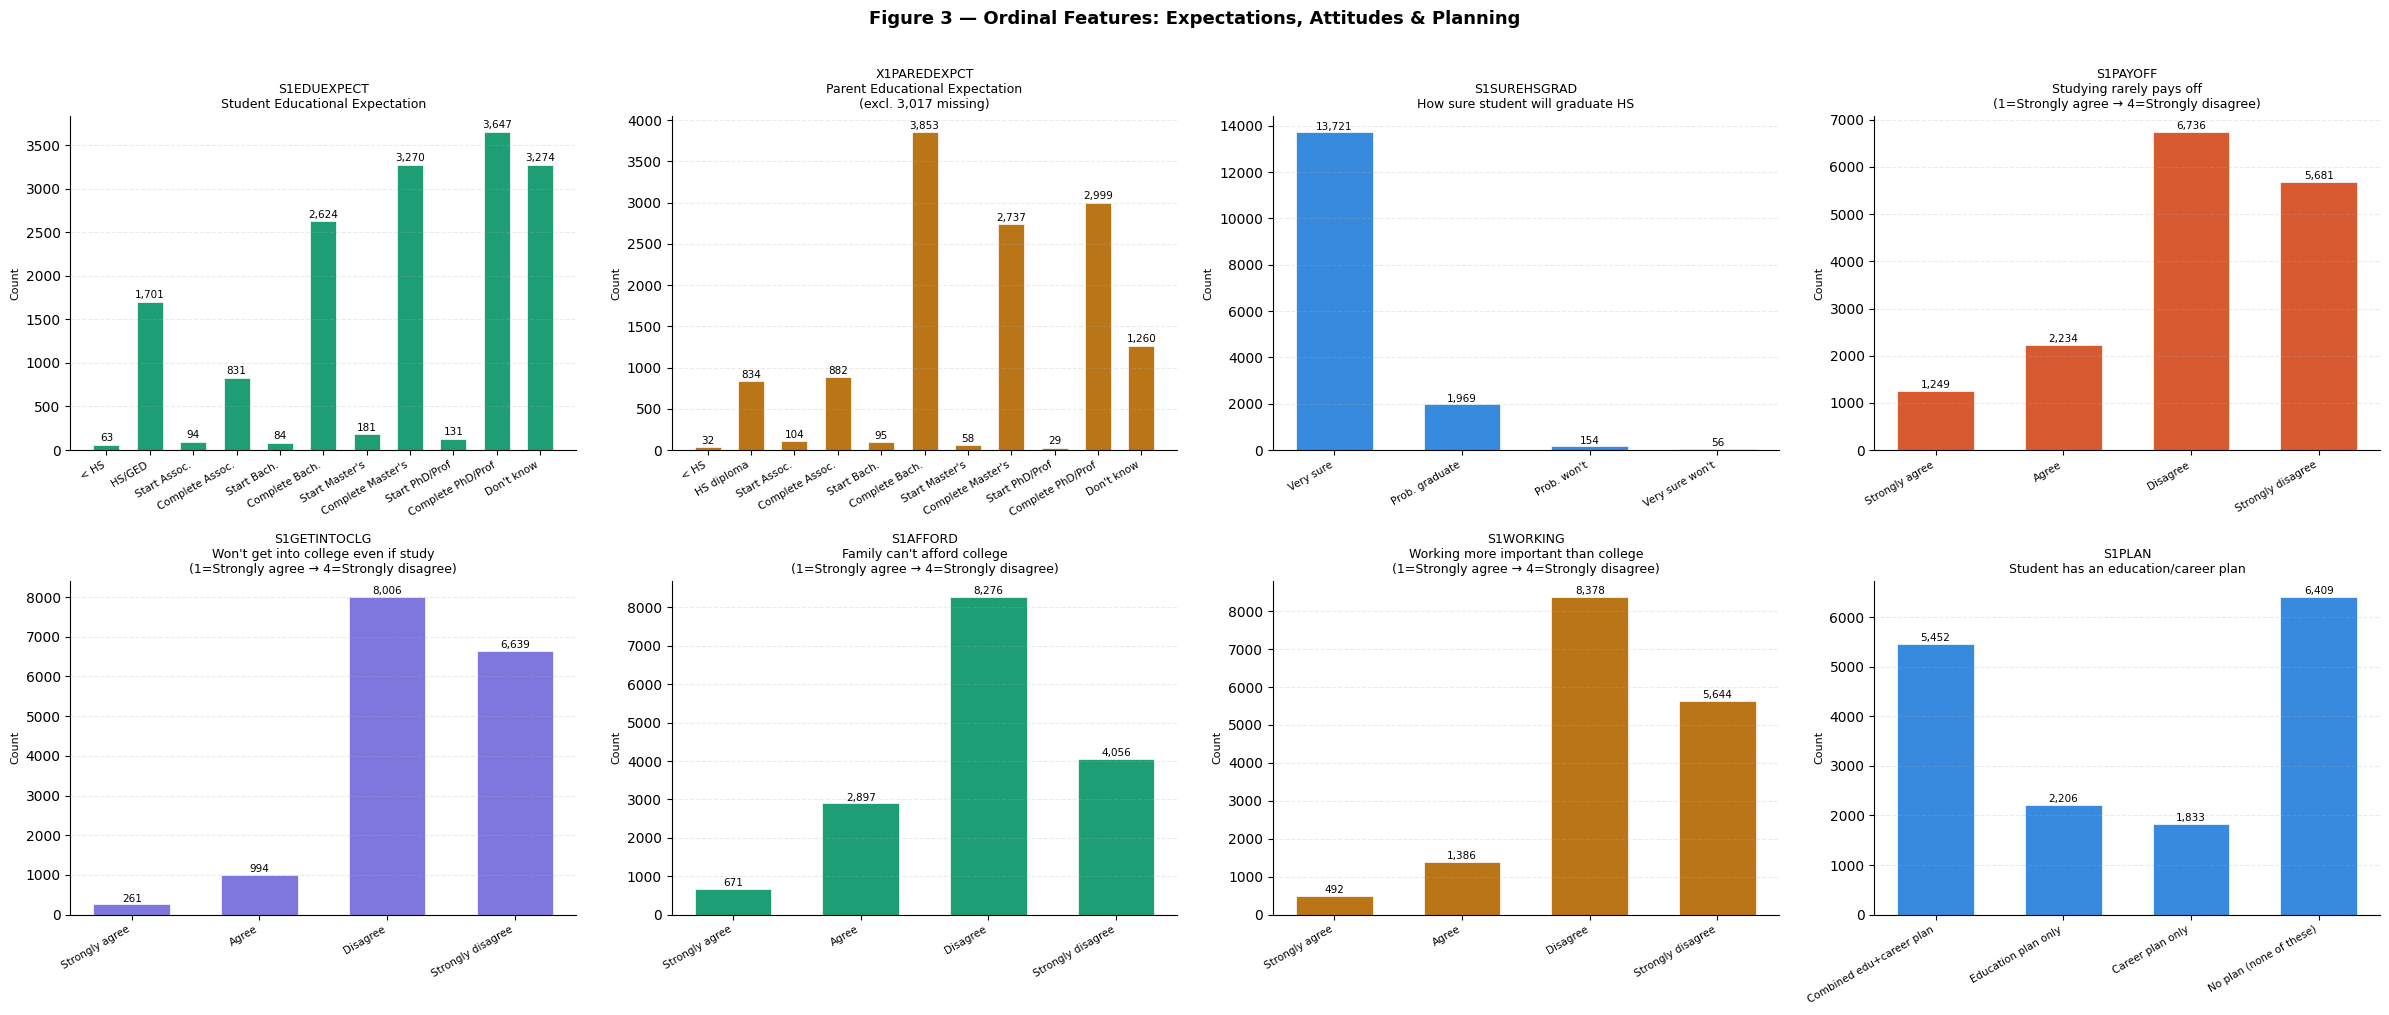

Saved → step3_fig3_ordinal_expectations.png


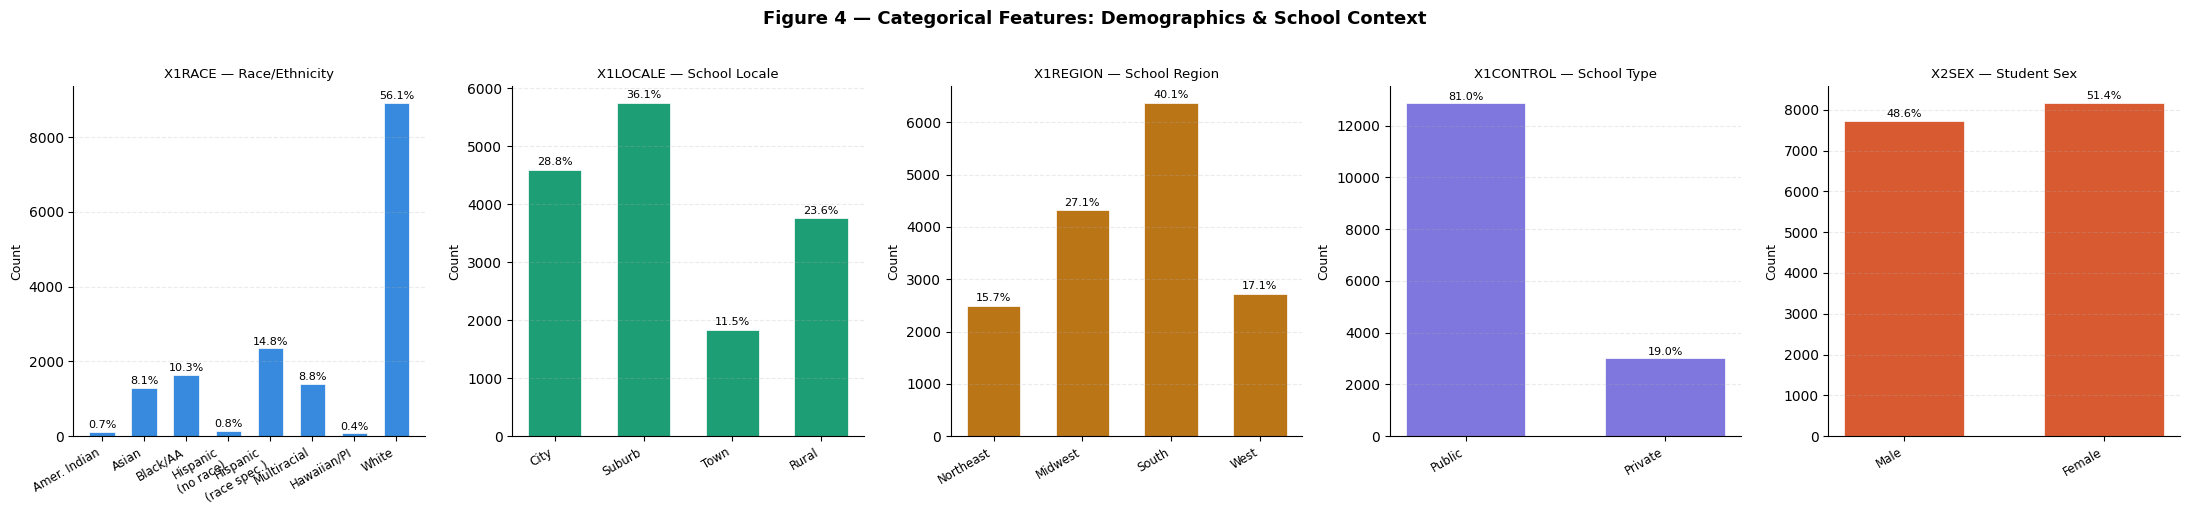

Saved → step3_fig4_categorical.png


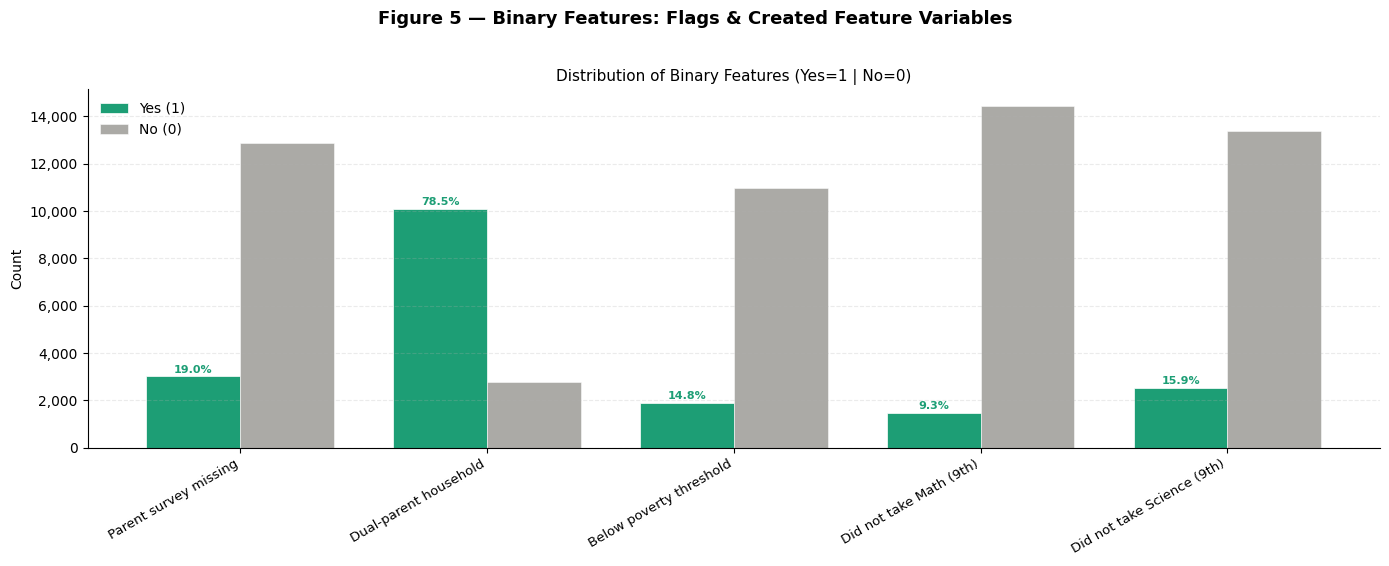

Saved → step3_fig5_binary.png


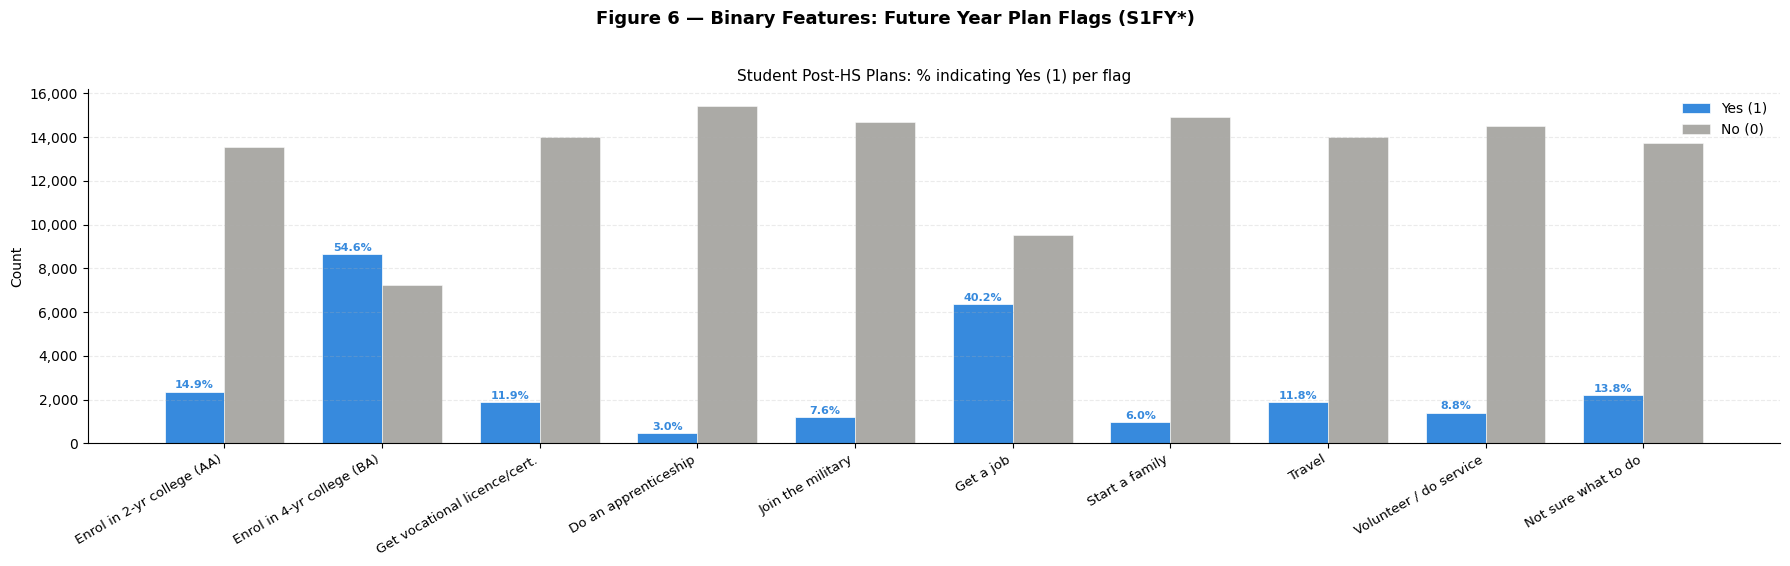

Saved → step3_fig6_future_plans.png

  UNIVARIATE SUMMARY — KEY STATISTICS

--- Continuous ---
  X1MTHEFF       : mean=0.07, sd=0.93, skew=-0.37, n=15,900
  X1SCIEFF       : mean=0.06, sd=0.89, skew=-0.22, n=15,900
  X1TXMTSCOR     : mean=52.01, sd=10.01, skew=-0.06, n=15,900
  X1SCHOOLBEL    : mean=0.10, sd=0.98, skew=-0.53, n=15,900
  X1SCHOOLCLI    : mean=-0.36, sd=0.94, skew=-0.53, n=15,900

--- Binary (% Yes) ---
  X1PAR_SURVEY_MISSING     : 19.0% Yes
  X1_DUAL_PARENT           : 78.5% Yes
  X1POVERTY                : 14.8% Yes
  MATH_NO_CLASS            : 9.3% Yes
  SCI_NO_CLASS             : 15.9% Yes

--- Binary: Future Year Plans (% Yes) ---
  S1FYAA         : 14.9% Yes
  S1FYBA         : 54.6% Yes
  S1FYLICENSE    : 11.9% Yes
  S1FYAPPR       : 3.0% Yes
  S1FYMILITARY   : 7.6% Yes
  S1FYJOB        : 40.2% Yes
  S1FYFAMILY     : 6.0% Yes
  S1FYTRAVEL     : 11.8% Yes
  S1FYVOLUN      : 8.8% Yes
  S1FYNOTSURE    : 13.8% Yes


In [9]:
# ── Palette ───────────────────────────────────────────────────
C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

# ─────────────────────────────────────────────────────────────
# FIGURE 1 — Continuous Features
# ─────────────────────────────────────────────────────────────
continuous = {
    "X1MTHEFF"   : "Math self-efficacy\n(standardised score)",
    "X1SCIEFF"   : "Science self-efficacy\n(standardised score)",
    "X1TXMTSCOR" : "Math assessment score\n(theta score)",
    "X1SCHOOLBEL": "School belonging\n(standardised composite)",
    "X1SCHOOLCLI": "School climate\n(standardised composite)",
}

fig1, axes = plt.subplots(1, 5, figsize=(20, 4.5))
fig1.suptitle("Figure 1 — Continuous Features: Distributions",
              fontsize=13, fontweight="bold", y=1.02)

for ax, (col, label) in zip(axes, continuous.items()):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=C_BLUE, alpha=0.6, edgecolor="white",
            linewidth=0.4, density=True)

    kde = gaussian_kde(data, bw_method=0.2)
    x_range = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_range, kde(x_range), color=C_CORAL, linewidth=2)

    ax.axvline(data.mean(),   color=C_AMBER, linestyle="--", linewidth=1.5,
               label=f"Mean {data.mean():.2f}")
    ax.axvline(data.median(), color=C_PURP,  linestyle=":",  linewidth=1.5,
               label=f"Median {data.median():.2f}")

    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8, frameon=False)

    stats_text = (f"n = {len(data):,}\nSD = {data.std():.2f}\n"
                  f"Skew = {data.skew():.2f}")
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            fontsize=7.5, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.8))

plt.tight_layout()
plt.savefig("step3_fig1_continuous.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step3_fig1_continuous.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 2 — Ordinal: Grades & Socioeconomic Status
# ─────────────────────────────────────────────────────────────

grade_labels  = {1:"A", 2:"B", 3:"C",
                 4:"D", 5:"Below D", 6:"Class Not grades"}
paredu_labels = {1:"< HS", 2:"HS diploma", 3:"Associate's",
                 4:"Bachelor's", 5:"Master's", 7:"PhD/MD/Law"}
income_labels = {
    1:"≤$15k", 2:"$15k–$35k", 3:"$35k–$55k", 4:"$55k–$75k", 5:"$75k–$95k",
    6:"$95k–$115k", 7:"$115k–$135k", 8:"$135k–$155k", 9:"$155k–$175k",
    10:"$175k–$195k", 11:"$195k–$215k", 12:"$215k–$235k", 13:">$235k"
}

fig2, axes = plt.subplots(2, 2, figsize=(16, 11))
fig2.suptitle("Figure 2 — Ordinal Features: Grades & Socioeconomic Status",
              fontsize=13, fontweight="bold", y=1.01)

# 2a — 8th grade Math grade
ax = axes[0, 0]
vc = df["S1M8GRADE"].value_counts().sort_index()
bars = ax.bar([grade_labels[k] for k in vc.index], vc.values,
              color=C_BLUE, edgecolor="white", linewidth=0.5, width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8.5)
ax.set_title("S1M8GRADE — 8th Grade Math Grade", fontsize=11)
ax.set_ylabel("Count"); ax.set_xlabel("Grade")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)

# 2b — 8th grade Science grade
ax = axes[0, 1]
vc = df["S1S8GRADE"].value_counts().sort_index()
bars = ax.bar([grade_labels[k] for k in vc.index], vc.values,
              color=C_TEAL, edgecolor="white", linewidth=0.5, width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8.5)
ax.set_title("S1S8GRADE — 8th Grade Science Grade", fontsize=11)
ax.set_ylabel("Count"); ax.set_xlabel("Grade")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)

# 2c — Parent education
ax = axes[1, 0]
vc = df["X1PAREDU"].value_counts().sort_index().dropna()
keys = [int(k) for k in vc.index]
bars = ax.bar([paredu_labels[k] for k in keys], vc.values,
              color=C_AMBER, edgecolor="white", linewidth=0.5, width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8.5)
ax.set_title("X1PAREDU — Parent Education Level\n(excl. 3,017 parent-survey missing)", fontsize=11)
ax.set_ylabel("Count"); ax.set_xlabel("Education Level")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)

# 2d — Family income
ax = axes[1, 1]
vc = df["X1FAMINCOME"].value_counts().sort_index().dropna()
keys = [int(k) for k in vc.index]
bars = ax.bar([income_labels[k] for k in keys], vc.values,
              color=C_PURP, edgecolor="white", linewidth=0.5, width=0.7)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=7.5)
ax.set_title("X1FAMINCOME — Family Income Bracket\n(excl. 3,017 parent-survey missing)", fontsize=11)
ax.set_ylabel("Count"); ax.set_xlabel("Income Bracket")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("step3_fig2_ordinal_ses.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step3_fig2_ordinal_ses.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 3 — Ordinal: Expectations, Attitudes & Planning
# ─────────────────────────────────────────────────────────────

# Correct labels: these are start/complete pairs, Don't know = 11
eduexpect_labels = {
    1:"< HS", 2:"HS/GED",
    3:"Start Assoc.", 4:"Complete Assoc.",
    5:"Start Bach.", 6:"Complete Bach.",
    7:"Start Master's", 8:"Complete Master's",
    9:"Start PhD/Prof", 10:"Complete PhD/Prof",
    11:"Don't know"
}
paredexpct_labels = {
    1:"< HS", 2:"HS diploma",
    3:"Start Assoc.", 4:"Complete Assoc.",
    5:"Start Bach.", 6:"Complete Bach.",
    7:"Start Master's", 8:"Complete Master's",
    9:"Start PhD/Prof", 10:"Complete PhD/Prof",
    11:"Don't know"
}
sure_labels  = {1:"Very sure", 2:"Prob. graduate",
                3:"Prob. won't", 4:"Very sure won't"}

# NOTE: S1PAYOFF, S1GETINTOCLG, S1AFFORD, S1WORKING are
# negatively framed Likert scales (1=Strongly agree with a
# negative statement, 4=Strongly disagree). Labels kept as
# the standard Likert scale to preserve directional clarity.
likert_labels = {1:"Strongly agree", 2:"Agree",
                 3:"Disagree", 4:"Strongly disagree"}

plan_labels = {
    1:"Combined edu+career plan",
    2:"Education plan only",
    3:"Career plan only",
    4:"No plan (none of these)"
}

fig3, axes = plt.subplots(2, 4, figsize=(24, 10))
fig3.suptitle("Figure 3 — Ordinal Features: Expectations, Attitudes & Planning",
              fontsize=13, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

specs = [
    ("S1EDUEXPECT",  "Student Educational Expectation",                  eduexpect_labels,  C_TEAL),
    ("X1PAREDEXPCT", "Parent Educational Expectation\n(excl. 3,017 missing)", paredexpct_labels, C_AMBER),
    ("S1SUREHSGRAD", "How sure student will graduate HS",                 sure_labels,       C_BLUE),
    ("S1PAYOFF",     "Studying rarely pays off\n(1=Strongly agree → 4=Strongly disagree)", likert_labels, C_CORAL),
    ("S1GETINTOCLG", "Won't get into college even if study\n(1=Strongly agree → 4=Strongly disagree)", likert_labels, C_PURP),
    ("S1AFFORD",     "Family can't afford college\n(1=Strongly agree → 4=Strongly disagree)", likert_labels, C_TEAL),
    ("S1WORKING",    "Working more important than college\n(1=Strongly agree → 4=Strongly disagree)", likert_labels, C_AMBER),
    ("S1PLAN",       "Student has an education/career plan",              plan_labels,       C_BLUE),
]

for i, (col, title, label_map, color) in enumerate(specs):
    ax = axes_flat[i]
    vc = df[col].value_counts().sort_index().dropna()
    keys = [int(k) for k in vc.index]
    labels = [label_map.get(k, str(k)) for k in keys]
    bars = ax.bar(labels, vc.values, color=color, edgecolor="white",
                  linewidth=0.5, width=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=7.5)
    ax.set_title(f"{col}\n{title}", fontsize=9)
    ax.set_ylabel("Count", fontsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7.5)

plt.tight_layout()
plt.savefig("step3_fig3_ordinal_expectations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step3_fig3_ordinal_expectations.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4 — Categorical: Demographics & School Context
# ─────────────────────────────────────────────────────────────

race_labels    = {1:"Amer. Indian", 2:"Asian", 3:"Black/AA",
                  4:"Hispanic\n(no race)", 5:"Hispanic\n(race spec.)",
                  6:"Multiracial", 7:"Hawaiian/PI", 8:"White"}
locale_labels  = {1:"City", 2:"Suburb", 3:"Town", 4:"Rural"}
region_labels  = {1:"Northeast", 2:"Midwest", 3:"South", 4:"West"}
control_labels = {1:"Public", 2:"Private"}
sex_labels     = {1:"Male", 2:"Female"}

fig4, axes = plt.subplots(1, 5, figsize=(22, 5))
fig4.suptitle("Figure 4 — Categorical Features: Demographics & School Context",
              fontsize=13, fontweight="bold", y=1.02)

cat_specs = [
    ("X1RACE",    "X1RACE — Race/Ethnicity",  race_labels,    C_BLUE),
    ("X1LOCALE",  "X1LOCALE — School Locale", locale_labels,  C_TEAL),
    ("X1REGION",  "X1REGION — School Region", region_labels,  C_AMBER),
    ("X1CONTROL", "X1CONTROL — School Type",  control_labels, C_PURP),
    ("X2SEX",     "X2SEX — Student Sex",      sex_labels,     C_CORAL),
]

for ax, (col, title, label_map, color) in zip(axes, cat_specs):
    vc = df[col].value_counts().sort_index()
    keys = [int(k) for k in vc.index]
    labels = [label_map.get(k, str(k)) for k in keys]
    pcts = (vc.values / len(df) * 100).round(1)

    bars = ax.bar(labels, vc.values, color=color, edgecolor="white",
                  linewidth=0.5, width=0.6)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

    ax.set_title(title, fontsize=9.5)
    ax.set_ylabel("Count", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8.5)

plt.tight_layout()
plt.savefig("step3_fig4_categorical.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step3_fig4_categorical.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5 — Binary: Flags & Created Features
# ─────────────────────────────────────────────────────────────

binary_features = {
    "X1PAR_SURVEY_MISSING" : "Parent survey missing",
    "X1_DUAL_PARENT"       : "Dual-parent household",
    "X1POVERTY"            : "Below poverty threshold",
    "MATH_NO_CLASS"        : "Did not take Math (9th)",
    "SCI_NO_CLASS"         : "Did not take Science (9th)",
}

fig5, ax = plt.subplots(figsize=(14, 5.5))
fig5.suptitle("Figure 5 — Binary Features: Flags & Created Feature Variables",
              fontsize=13, fontweight="bold", y=1.02)

labels_list, yes_vals, no_vals, yes_pcts = [], [], [], []

for col, label in binary_features.items():
    total_valid = df[col].notna().sum()
    yes = int((df[col] == 1).sum())
    no  = int((df[col] == 0).sum())
    yes_pct = yes / total_valid * 100
    labels_list.append(label)
    yes_vals.append(yes)
    no_vals.append(no)
    yes_pcts.append(yes_pct)

x = np.arange(len(labels_list))
w = 0.38

b1 = ax.bar(x - w/2, yes_vals, width=w, color=C_TEAL, label="Yes (1)",
            edgecolor="white", linewidth=0.5)
b2 = ax.bar(x + w/2, no_vals,  width=w, color=C_GRAY, label="No (0)",
            edgecolor="white", linewidth=0.5, alpha=0.7)

for bar, pct in zip(b1, yes_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=8,
            color=C_TEAL, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels_list, rotation=30, ha="right", fontsize=9.5)
ax.set_ylabel("Count")
ax.set_title("Distribution of Binary Features (Yes=1 | No=0)", fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("step3_fig5_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step3_fig5_binary.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 6 — Binary: Future Year Plan Flags (S1FY*)
# ─────────────────────────────────────────────────────────────

future_plan_features = {
    "S1FYAA"       : "Enrol in 2-yr college (AA)",
    "S1FYBA"       : "Enrol in 4-yr college (BA)",
    "S1FYLICENSE"  : "Get vocational licence/cert.",
    "S1FYAPPR"     : "Do an apprenticeship",
    "S1FYMILITARY" : "Join the military",
    "S1FYJOB"      : "Get a job",
    "S1FYFAMILY"   : "Start a family",
    "S1FYTRAVEL"   : "Travel",
    "S1FYVOLUN"    : "Volunteer / do service",
    "S1FYNOTSURE"  : "Not sure what to do",
}

fig6, ax = plt.subplots(figsize=(18, 5.5))
fig6.suptitle("Figure 6 — Binary Features: Future Year Plan Flags (S1FY*)",
              fontsize=13, fontweight="bold", y=1.02)

labels_list6, yes_vals6, no_vals6, yes_pcts6 = [], [], [], []

for col, label in future_plan_features.items():
    total_valid = df[col].notna().sum()
    yes = int((df[col] == 1).sum())
    no  = int((df[col] == 0).sum())
    yes_pct = yes / total_valid * 100 if total_valid > 0 else 0
    labels_list6.append(label)
    yes_vals6.append(yes)
    no_vals6.append(no)
    yes_pcts6.append(yes_pct)

x6 = np.arange(len(labels_list6))
w6 = 0.38

b1 = ax.bar(x6 - w6/2, yes_vals6, width=w6, color=C_BLUE, label="Yes (1)",
            edgecolor="white", linewidth=0.5)
b2 = ax.bar(x6 + w6/2, no_vals6,  width=w6, color=C_GRAY, label="No (0)",
            edgecolor="white", linewidth=0.5, alpha=0.7)

for bar, pct in zip(b1, yes_pcts6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=8,
            color=C_BLUE, fontweight="bold")

ax.set_xticks(x6)
ax.set_xticklabels(labels_list6, rotation=30, ha="right", fontsize=9.5)
ax.set_ylabel("Count")
ax.set_title("Student Post-HS Plans: % indicating Yes (1) per flag", fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("step3_fig6_future_plans.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step3_fig6_future_plans.png")


# ── Printed summary ───────────────────────────────────────────
print("\n" + "=" * 55)
print("  UNIVARIATE SUMMARY — KEY STATISTICS")
print("=" * 55)

print("\n--- Continuous ---")
for col, label in continuous.items():
    d = df[col].dropna()
    print(f"  {col:<15}: mean={d.mean():.2f}, sd={d.std():.2f}, "
          f"skew={d.skew():.2f}, n={len(d):,}")

print("\n--- Binary (% Yes) ---")
for col, label in binary_features.items():
    total_valid = df[col].notna().sum()
    yes_pct = (df[col] == 1).sum() / total_valid * 100
    print(f"  {col:<25}: {yes_pct:.1f}% Yes")

print("\n--- Binary: Future Year Plans (% Yes) ---")
for col, label in future_plan_features.items():
    total_valid = df[col].notna().sum()
    yes_pct = (df[col] == 1).sum() / total_valid * 100 if total_valid > 0 else float("nan")
    print(f"  {col:<15}: {yes_pct:.1f}% Yes")

Key takeaways from Step 3:

Figure 1 — Continuous features
- All five are roughly bell-shaped and near-normally distributed, consistent with them being standardised composite scores.
- `X1SCHOOLCLI` (school climate) has a notably negative mean (−0.36) and median (−0.36) — students tend to rate their school climate below average, which is worth flagging going into modeling.
- `X1SCHOOLBEL` and both efficacy scores show a mild-to-moderate left skew (skew ≈ −0.37 to −0.53), meaning a small group of students rate themselves very negatively on belonging and self-efficacy.
- `X1TXMTSCOR` is the cleanest distribution (mean=52.01, SD=10.01, skew ≈ −0.06, no missing), making it the most reliable continuous predictor going into modeling.

Figure 2 — Grades & SES
- Both 8th grade grade distributions are heavily right-skewed toward A/B, which is typical of self-reported data — very few students admit to below-D grades.
- Parent education peaks at HS diploma (4,266), followed by Bachelor's — a wide spread across the SES ladder.
- Family income is left-heavy, with the most students clustering in the $15k–$75k bands, then thinning out at higher incomes.

Figure 3 — Expectations, attitudes & planning
- `S1SUREHSGRAD` is overwhelmingly "Very sure" (13,721 / 86.3%) — this is a low-variance feature and may have limited discriminative power unless the minority "not sure" group is highly predictive.
- `S1PAYOFF`, `S1GETINTOCLG`, `S1AFFORD`, and `S1WORKING` are all negatively framed Likert scales — most students Disagree or Strongly disagree with the negative statements, meaning they believe school is worth it, think they can get in, and don't prioritise work over college.
- `X1PAREDEXPCT` has a prominent spike at "Complete a Bachelor's degree" (3,853) and a large "Don't know" count (1,260) — notable uncertainty in parental expectations.
- `S1PLAN`: 34.3% have a combined education and career plan, while 40.3% report having no plan at all ("None of these") — the largest single group entering 9th grade with no clear direction.

Figure 4 — Categorical / demographics
- The sample is predominantly White (56.1%), then Hispanic (14.8%), Black/AA (10.3%), and Asian (8.1%) — a nationally representative composition.
- 81% of students attend public schools, with only 19% in private.
- The sex split is near-even: 48.6% male, 51.4% female.

Figure 5 — Binary flags
- 19.0% have a parent-survey-missing flag and 14.8% live below the poverty threshold — both are comparable in scale to the typical dropout rate (~15%), suggesting strong overlap with the at-risk population.
- 78.5% come from dual-parent households, meaning roughly 1 in 5 students does not — a meaningful minority worth tracking in the bivariate step.
- 9.3% did not take Math and 15.9% did not take Science in 9th grade — the Science gap is notably larger and likely proxies for early academic disengagement or course avoidance.

Figure 6 — Future year plan flags (S1FY\*)
- **54.6%** plan to enrol in a 4-year college (`S1FYBA`) — the single most common post-HS intention by a wide margin.
- **40.2%** plan to get a full-time job (`S1FYJOB`) — high enough that work-orientation likely competes directly with college-going intent for a large share of students, and these two flags are not mutually exclusive.
- Only **14.9%** plan a 2-year college (`S1FYAA`), meaning the combined "any college" group is roughly 69.5% — but the BA vs AA split matters for modeling, as they likely carry different dropout risk profiles.
- **13.8%** are flagged as `S1FYNOTSURE` (not sure what to do) — undecided students who likely overlap with the 40.3% who reported no plan in `S1PLAN`.
- Low-frequency plans — apprenticeship (3.0%), staying home for family (6.0%), military (7.6%), volunteering (8.8%), travel (11.8%) — are rare but potentially high-signal categories worth retaining as individual features rather than collapsing.


Hypotheses for the report:

1. **Students with no plan at all are at elevated risk.** With 13.8% of students flagged as `S1FYNOTSURE` and 40.3% reporting no education or career plan whatsoever in `S1PLAN` (category: "None of these"), a large segment enters high school with no clear direction. We expect these students to show meaningfully higher dropout rates in the bivariate analysis — the absence of any plan is a stronger signal than simple indecision.

2. **School climate may be a sleeper predictor.** The consistently negative mean of `X1SCHOOLCLI` (−0.36) suggests students broadly perceive their school environment as below average. Even small variation in climate scores may correlate with dropout, particularly for students already on the margin.

3. **High confidence may mask low information.** Variables like `S1SUREHSGRAD` (86.3% "Very sure") and the four attitude variables are heavily concentrated in the top response — their predictive value will depend almost entirely on the small group who answered otherwise. These may need to be recoded as binary (top category vs. rest) before modeling.

# EDA - Step 4: Bivariate Analysis  (Feature vs. X4EVERDROP)

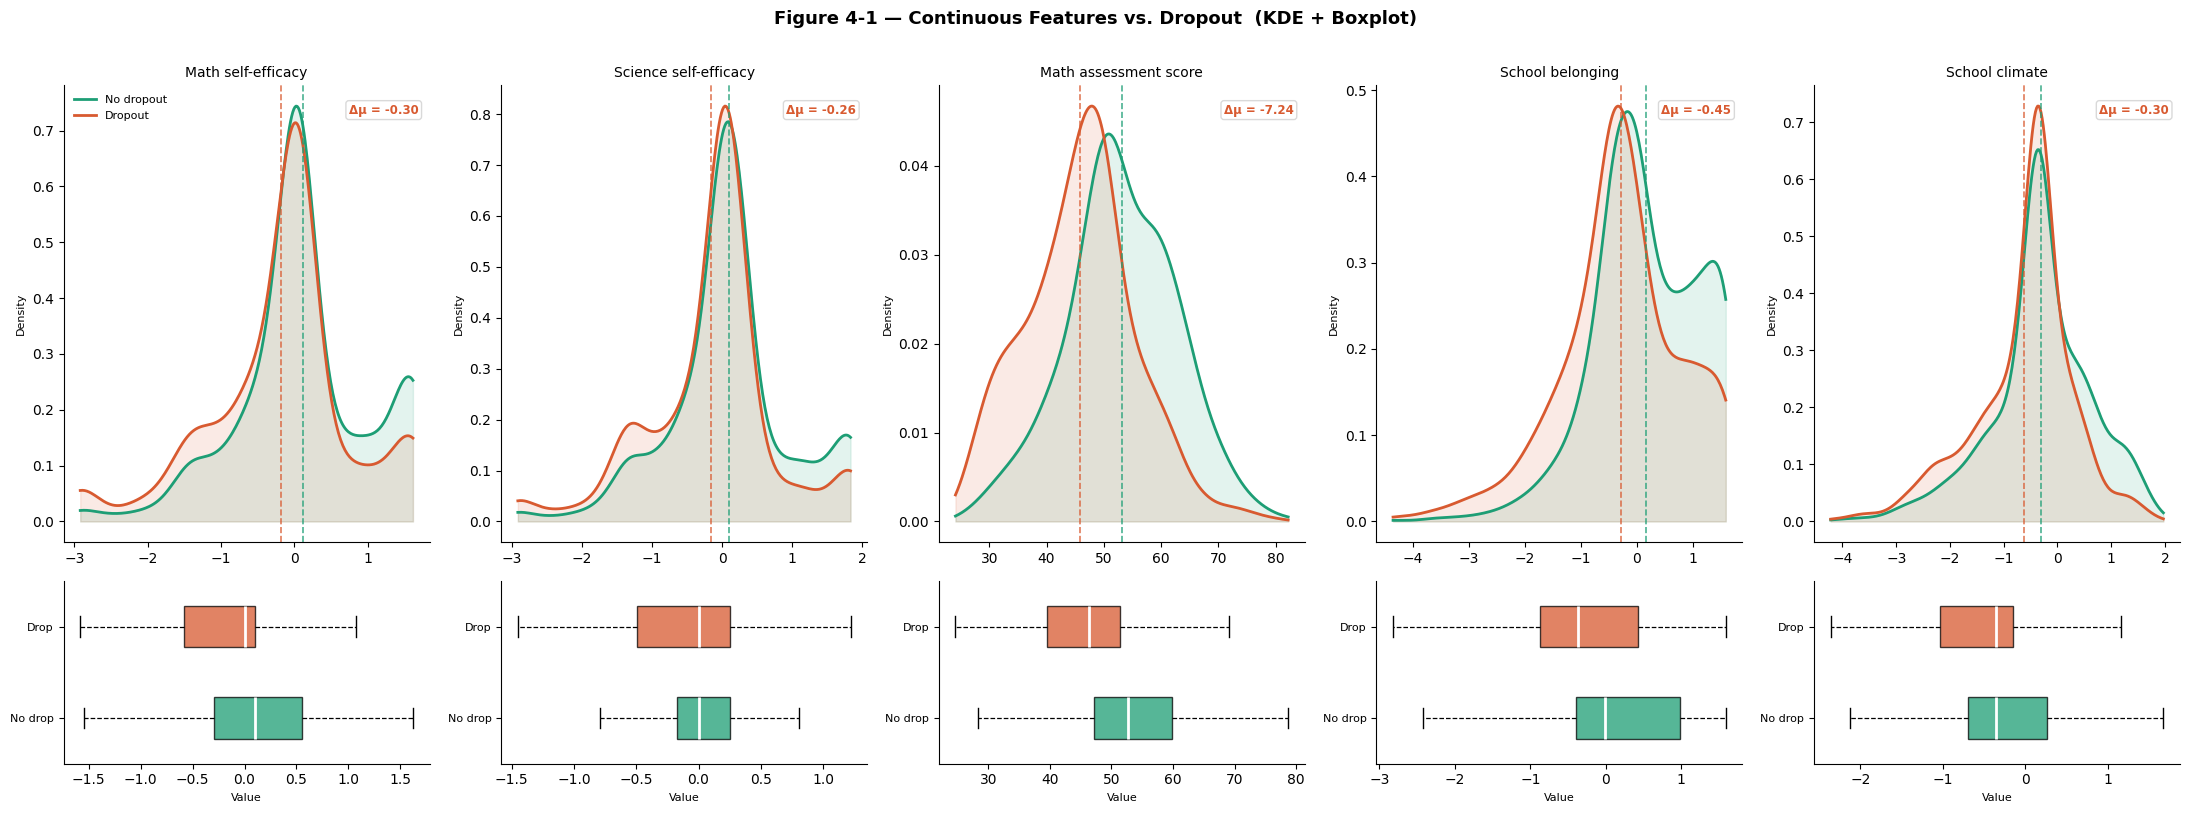

Saved → step4_fig1_continuous_bivariate.png


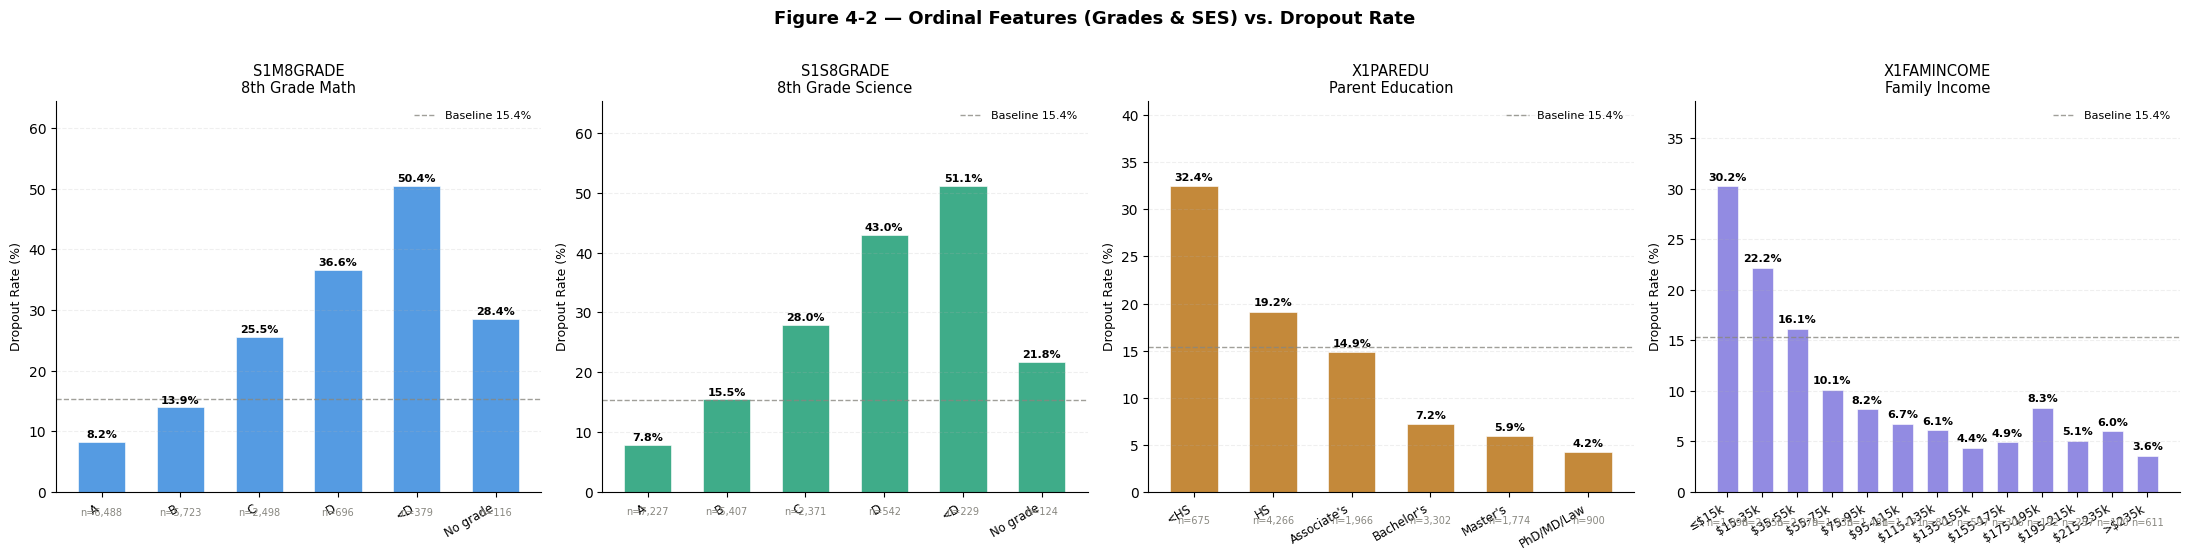

Saved → step4_fig2_grades_ses_bivariate.png


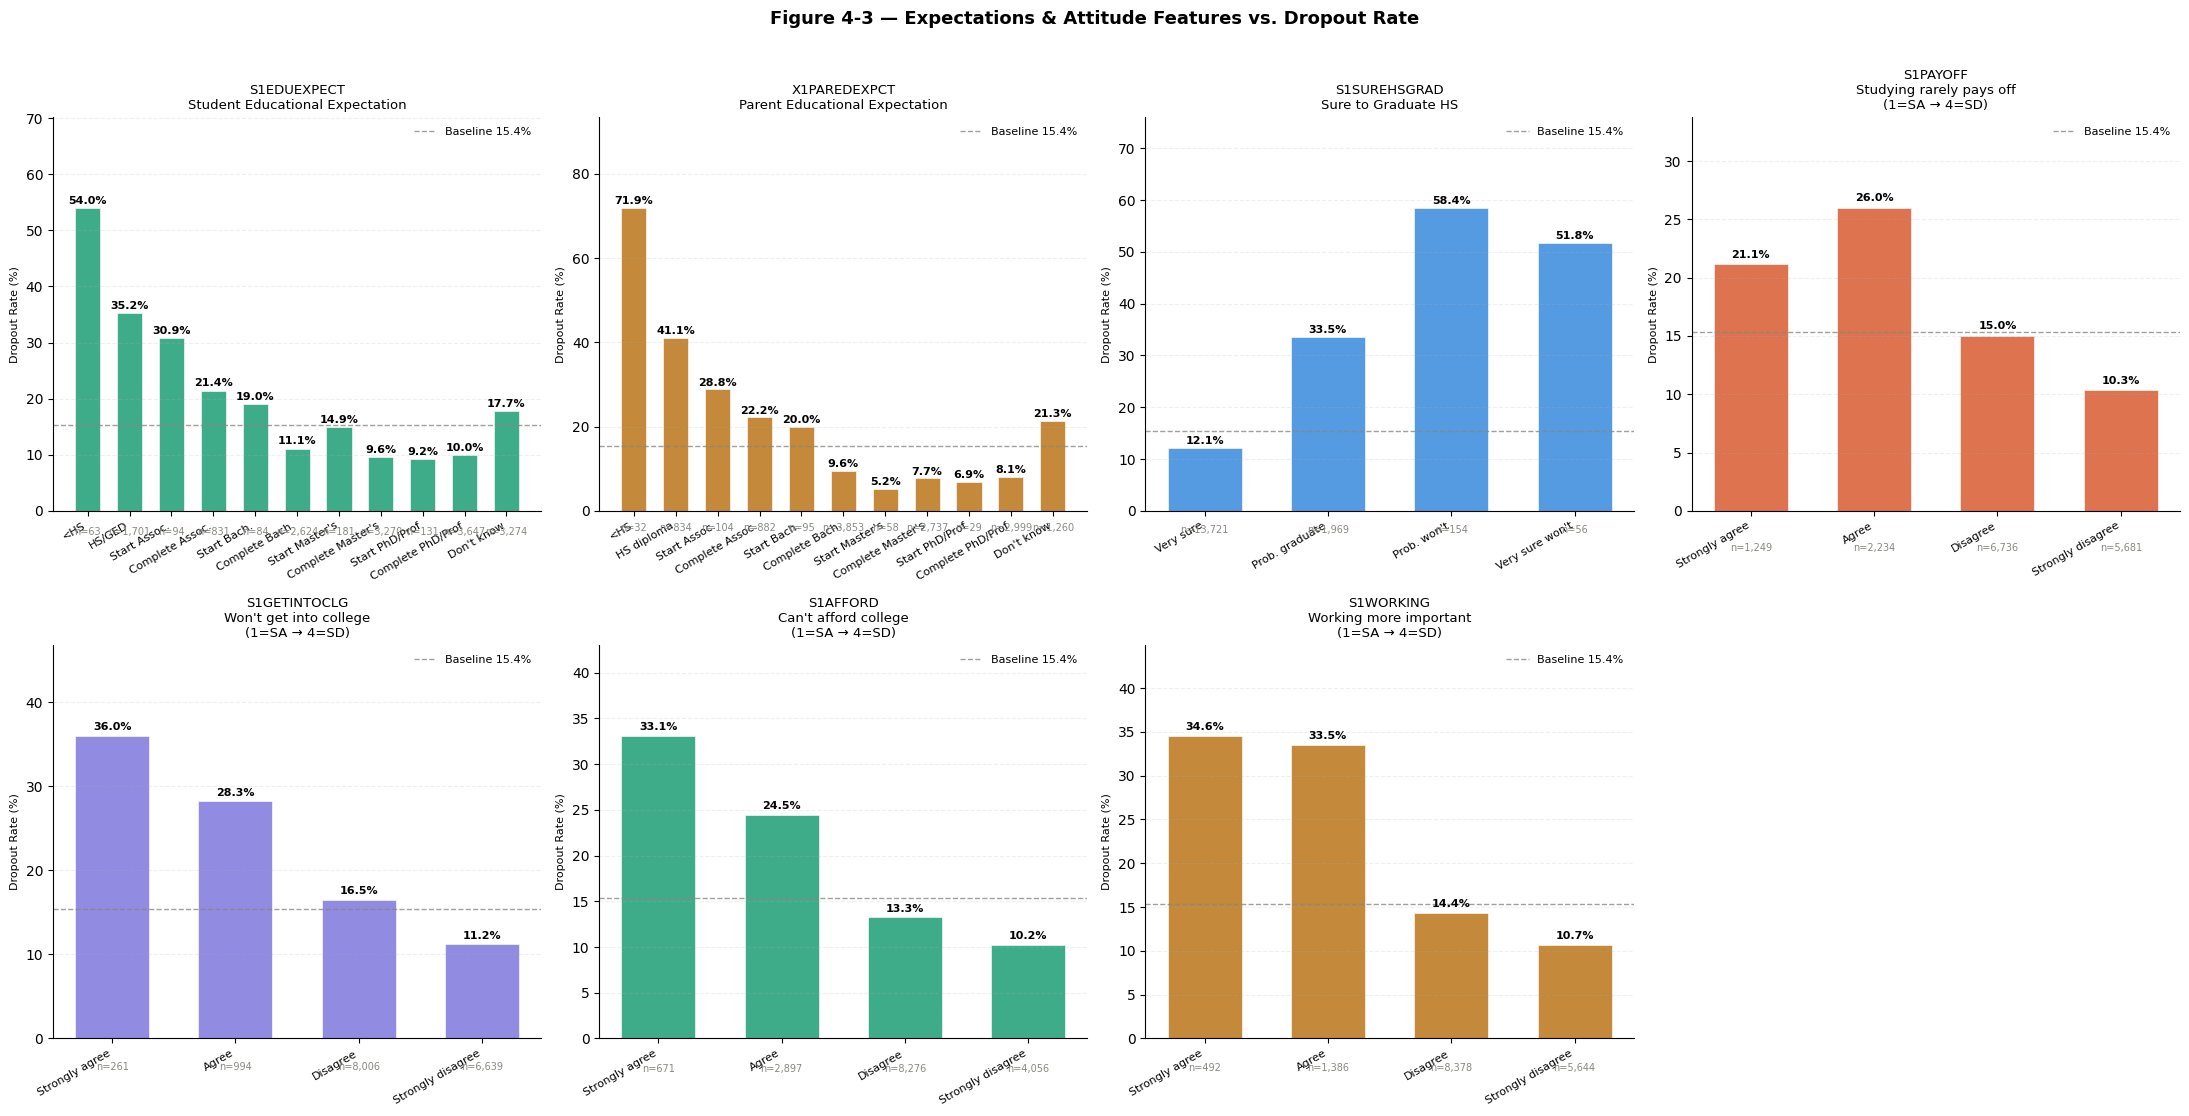

Saved → step4_fig3_expectations_bivariate.png


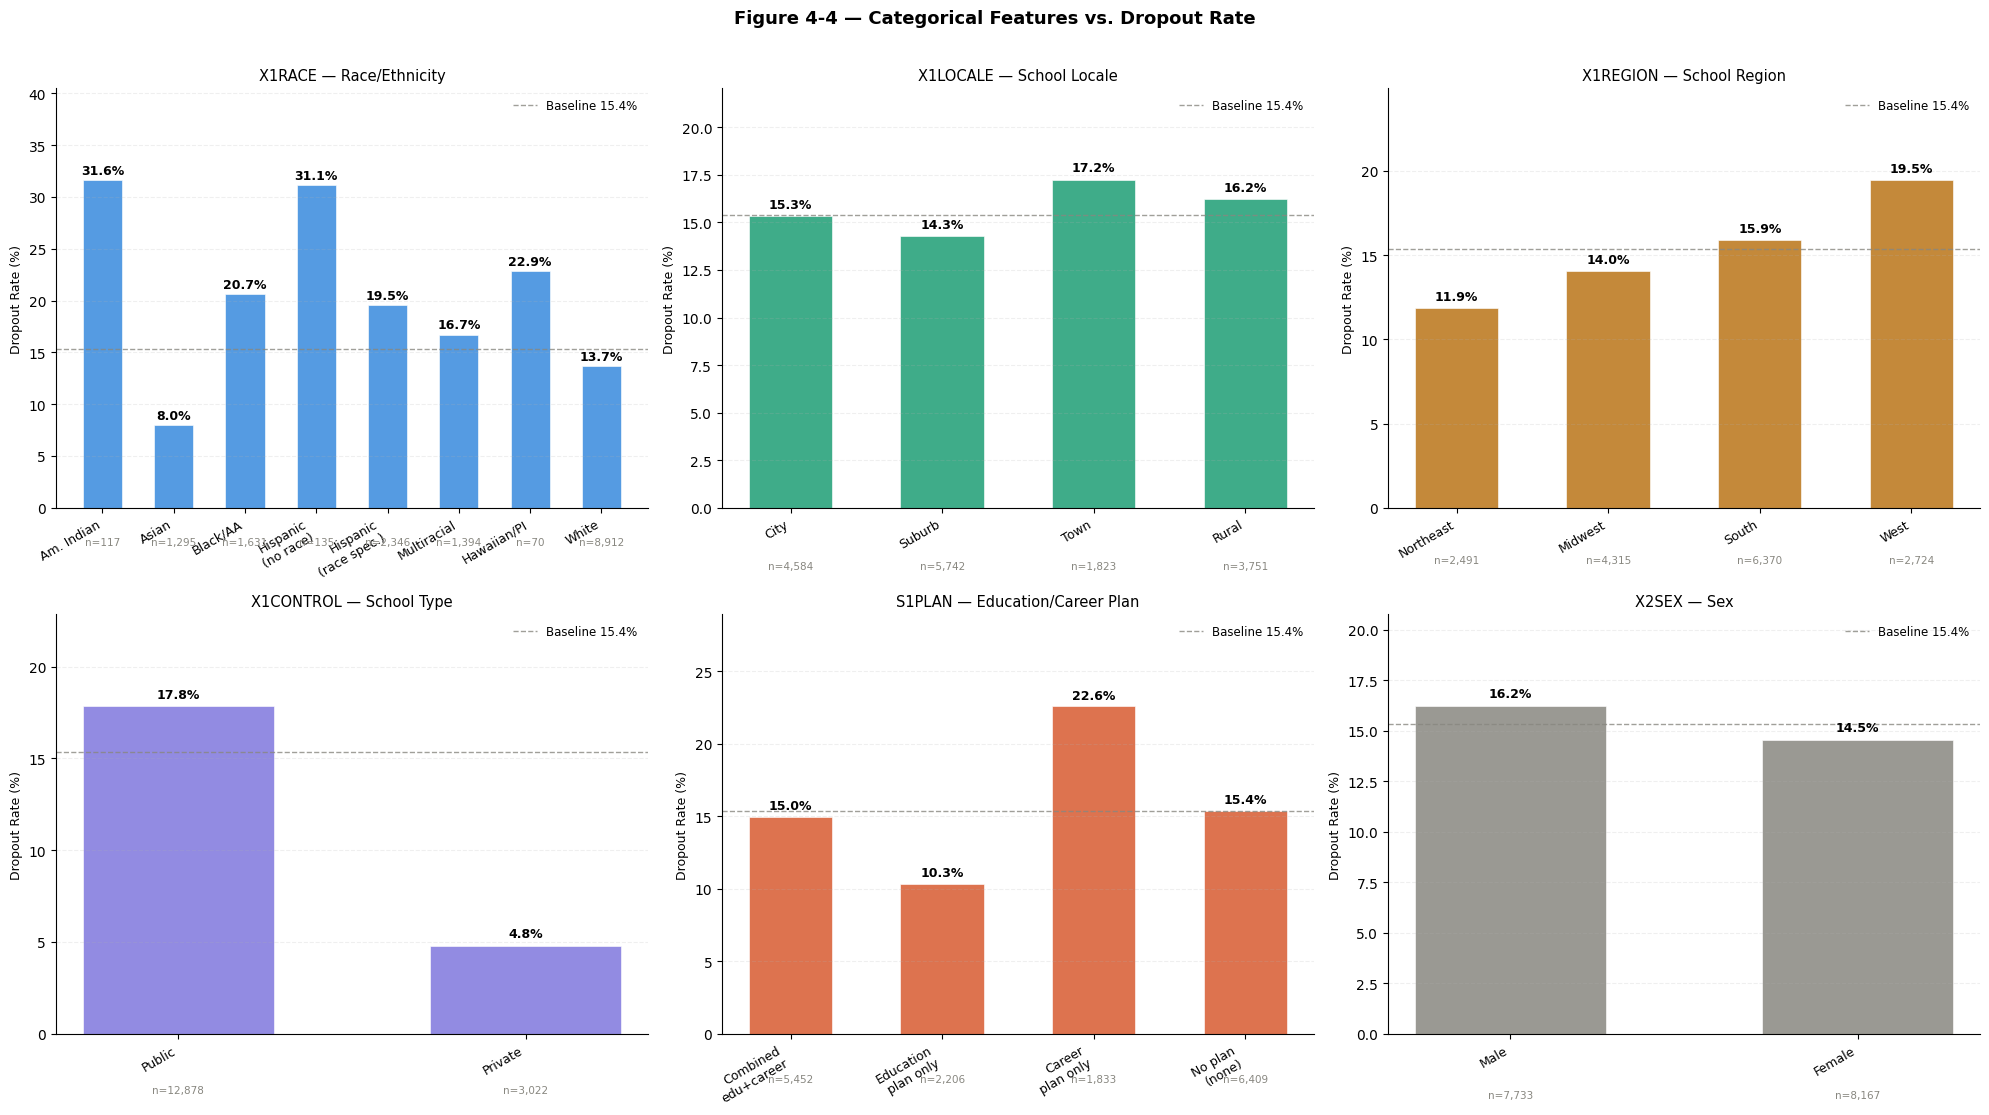

Saved → step4_fig4_categorical_bivariate.png


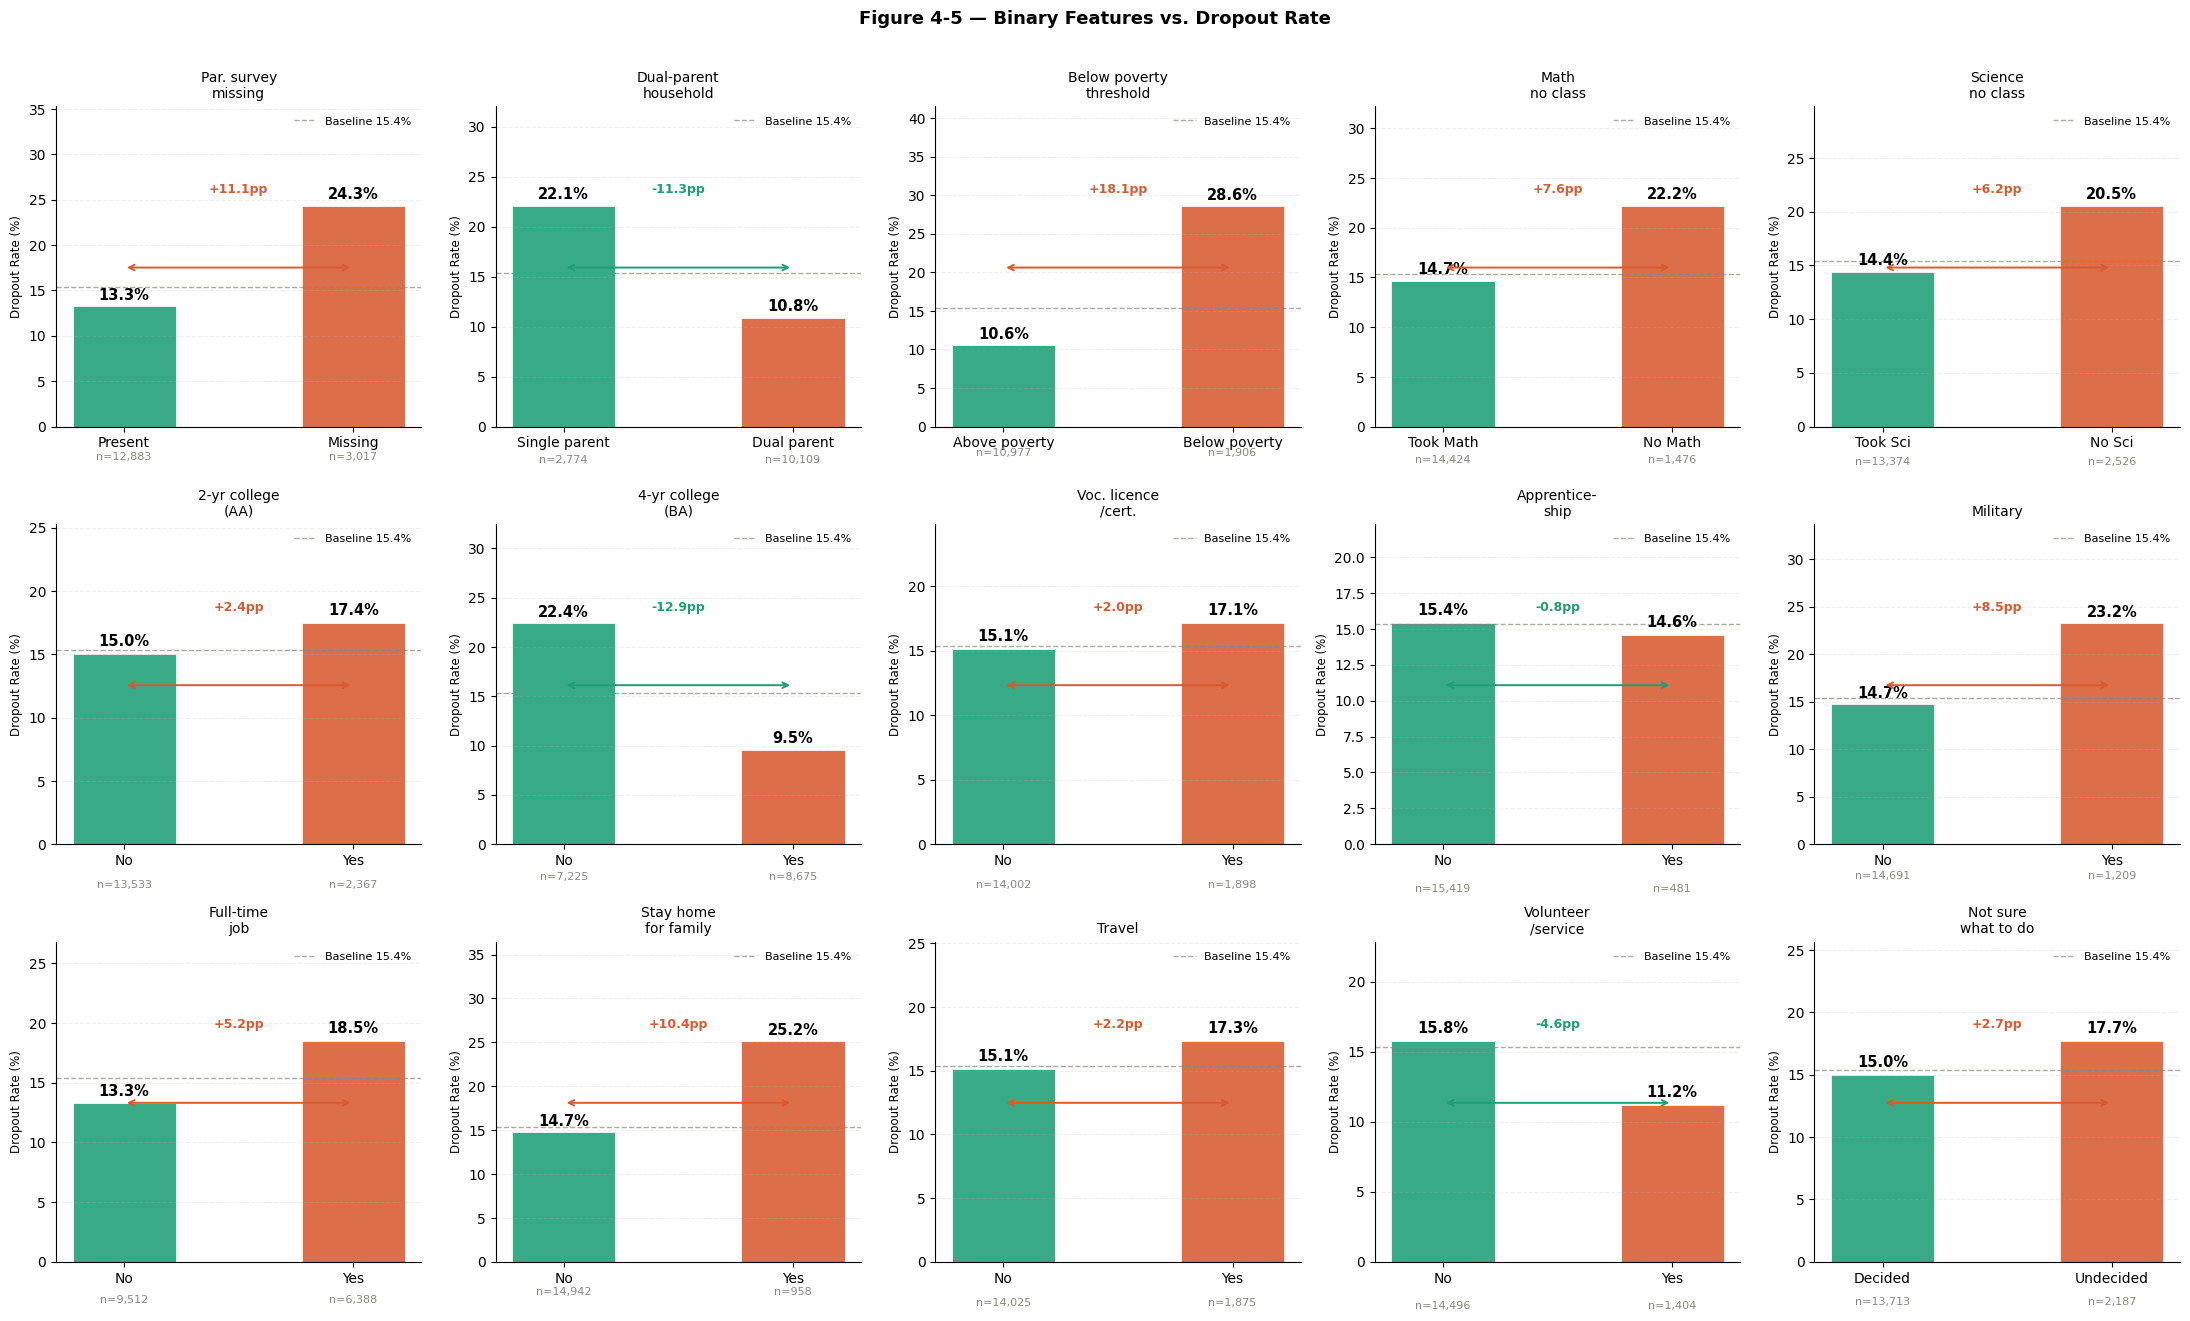

Saved → step4_fig5_binary_bivariate.png

  STEP 4 — BIVARIATE SUMMARY: TOP DISCRIMINATING FEATURES

--- Continuous: mean(Dropout) vs mean(No Dropout) + correlation ---
  X1MTHEFF        : μ_drop=-0.19  μ_nodrop=0.11  Δ=-0.30  r=-0.116  p=<0.001
  X1SCIEFF        : μ_drop=-0.16  μ_nodrop=0.10  Δ=-0.26  r=-0.104  p=<0.001
  X1TXMTSCOR      : μ_drop=45.88  μ_nodrop=53.13  Δ=-7.24  r=-0.261  p=<0.001
  X1SCHOOLBEL     : μ_drop=-0.28  μ_nodrop=0.17  Δ=-0.45  r=-0.166  p=<0.001
  X1SCHOOLCLI     : μ_drop=-0.62  μ_nodrop=-0.31  Δ=-0.30  r=-0.116  p=<0.001

--- Binary: dropout rate by group ---
  X1PAR_SURVEY_MISSING     : Present=13.3%  Missing=24.3%  Δ=+11.1pp
  X1_DUAL_PARENT           : Single parent=22.1%  Dual parent=10.8%  Δ=-11.3pp
  X1POVERTY                : Above poverty=10.6%  Below poverty=28.6%  Δ=+18.1pp
  MATH_NO_CLASS            : Took Math=14.7%  No Math=22.2%  Δ=+7.6pp
  SCI_NO_CLASS             : Took Sci=14.4%  No Sci=20.5%  Δ=+6.2pp
  S1FYAA                   : No=15.0%  

In [10]:
# ── Palette & baseline ────────────────────────────────────────
C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"
BASE_DR = df["X4EVERDROP"].mean() * 100

# ── helper ────────────────────────────────────────────────────
def dropout_by_group(col, label_map=None):
    """Return grouped dropout rates sorted by col value."""
    grp = df.groupby(col)["X4EVERDROP"].agg(["mean","count"]).reset_index()
    grp.columns = [col, "rate", "n"]
    grp["rate"] *= 100
    if label_map:
        grp["label"] = grp[col].astype(int).map(label_map)
    else:
        grp["label"] = grp[col].astype(str)
    return grp

# ─────────────────────────────────────────────────────────────
# FIGURE 4-1 — Continuous Features: KDE split + Boxplot
# ─────────────────────────────────────────────────────────────
continuous = ["X1MTHEFF","X1SCIEFF","X1TXMTSCOR","X1SCHOOLBEL","X1SCHOOLCLI"]
cont_labels = {
    "X1MTHEFF"   : "Math self-efficacy",
    "X1SCIEFF"   : "Science self-efficacy",
    "X1TXMTSCOR" : "Math assessment score",
    "X1SCHOOLBEL": "School belonging",
    "X1SCHOOLCLI": "School climate",
}

fig, axes = plt.subplots(2, 5, figsize=(22, 8),
                         gridspec_kw={"height_ratios": [2.5, 1]})
fig.suptitle("Figure 4-1 — Continuous Features vs. Dropout  (KDE + Boxplot)",
             fontsize=13, fontweight="bold", y=1.01)

for j, col in enumerate(continuous):
    ax_kde = axes[0, j]
    ax_box = axes[1, j]

    d0 = df.loc[df["X4EVERDROP"]==0, col].dropna()
    d1 = df.loc[df["X4EVERDROP"]==1, col].dropna()

    for d, color, lbl in [(d0, C_TEAL, "No dropout"), (d1, C_CORAL, "Dropout")]:
        kde = gaussian_kde(d, bw_method=0.25)
        xr  = np.linspace(min(d0.min(), d1.min()),
                           max(d0.max(), d1.max()), 300)
        ax_kde.plot(xr, kde(xr), color=color, linewidth=2, label=lbl)
        ax_kde.fill_between(xr, kde(xr), alpha=0.12, color=color)

    ax_kde.set_title(cont_labels[col], fontsize=10)
    ax_kde.set_ylabel("Density", fontsize=8)
    ax_kde.spines[["top","right"]].set_visible(False)
    if j == 0:
        ax_kde.legend(fontsize=8, frameon=False)

    ax_kde.axvline(d0.mean(), color=C_TEAL,  linestyle="--", linewidth=1.2,
                   alpha=0.8, label=f"μ₀={d0.mean():.2f}")
    ax_kde.axvline(d1.mean(), color=C_CORAL, linestyle="--", linewidth=1.2,
                   alpha=0.8, label=f"μ₁={d1.mean():.2f}")

    delta = d1.mean() - d0.mean()
    sign  = "+" if delta >= 0 else ""
    ax_kde.text(0.97, 0.96,
                f"Δμ = {sign}{delta:.2f}",
                transform=ax_kde.transAxes, ha="right", va="top",
                fontsize=8.5, fontweight="bold",
                color=C_CORAL if delta < 0 else C_AMBER,
                bbox=dict(boxstyle="round,pad=0.25", fc="white",
                          ec="lightgray", alpha=0.85))

    bp = ax_box.boxplot([d0, d1], vert=False, patch_artist=True,
                         widths=0.45, showfliers=False,
                         medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], [C_TEAL, C_CORAL]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for whisker in bp["whiskers"]:
        whisker.set(linestyle="--", linewidth=0.9)

    ax_box.set_yticks([1, 2])
    ax_box.set_yticklabels(["No drop", "Drop"], fontsize=8)
    ax_box.set_xlabel("Value", fontsize=8)
    ax_box.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("step4_fig1_continuous_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step4_fig1_continuous_bivariate.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4-2 — Ordinal: Grades & SES → dropout rate bars
# ─────────────────────────────────────────────────────────────
grade_labels  = {1:"A",2:"B",3:"C",4:"D",5:"<D",6:"No grade"}
# Category 7 = PhD/MD/Law (NOT "Don't know")
paredu_labels = {1:"<HS",2:"HS",3:"Associate's",4:"Bachelor's",
                 5:"Master's",7:"PhD/MD/Law"}
income_labels = {1:"≤$15k",2:"$15-35k",3:"$35-55k",4:"$55-75k",5:"$75-95k",
                 6:"$95-115k",7:"$115-135k",8:"$135-155k",9:"$155-175k",
                 10:"$175-195k",11:"$195-215k",12:"$215-235k",13:">$235k"}

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
fig.suptitle("Figure 4-2 — Ordinal Features (Grades & SES) vs. Dropout Rate",
             fontsize=13, fontweight="bold", y=1.01)

ses_specs = [
    ("S1M8GRADE",   "S1M8GRADE\n8th Grade Math",    grade_labels,  C_BLUE),
    ("S1S8GRADE",   "S1S8GRADE\n8th Grade Science",  grade_labels,  C_TEAL),
    ("X1PAREDU",    "X1PAREDU\nParent Education",     paredu_labels, C_AMBER),
    ("X1FAMINCOME", "X1FAMINCOME\nFamily Income",     income_labels, C_PURP),
]

for ax, (col, title, lmap, color) in zip(axes, ses_specs):
    grp = dropout_by_group(col, lmap)
    bars = ax.bar(grp["label"], grp["rate"], color=color,
                  edgecolor="white", linewidth=0.5, width=0.6, alpha=0.85)
    for bar, r, n in zip(bars, grp["rate"], grp["n"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f"{r:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
        ax.text(bar.get_x()+bar.get_width()/2, -2.5,
                f"n={n:,}", ha="center", va="top", fontsize=7, color=C_GRAY)

    ax.axhline(BASE_DR, color=C_GRAY, linestyle="--", linewidth=1, alpha=0.8,
               label=f"Baseline {BASE_DR:.1f}%")
    ax.set_title(title, fontsize=10.5)
    ax.set_ylabel("Dropout Rate (%)", fontsize=9)
    ax.set_ylim(0, max(grp["rate"]) * 1.28)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(fontsize=8, frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8.5)

plt.tight_layout()
plt.savefig("step4_fig2_grades_ses_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step4_fig2_grades_ses_bivariate.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4-3 — Ordinal: Expectations & Attitudes → dropout rate
# ─────────────────────────────────────────────────────────────
# Correct: start/complete pairs, Don't know = 11
eduexpect_labels = {
    1:"<HS", 2:"HS/GED",
    3:"Start Assoc.", 4:"Complete Assoc.",
    5:"Start Bach.", 6:"Complete Bach.",
    7:"Start Master's", 8:"Complete Master's",
    9:"Start PhD/Prof", 10:"Complete PhD/Prof",
    11:"Don't know"
}
paredexpct_labels = {
    1:"<HS", 2:"HS diploma",
    3:"Start Assoc.", 4:"Complete Assoc.",
    5:"Start Bach.", 6:"Complete Bach.",
    7:"Start Master's", 8:"Complete Master's",
    9:"Start PhD/Prof", 10:"Complete PhD/Prof",
    11:"Don't know"
}
sure_labels  = {1:"Very sure",2:"Prob. graduate",
                3:"Prob. won't",4:"Very sure won't"}
# Negatively framed — 1=Strongly agree with negative statement
likert_labels = {1:"Strongly agree",2:"Agree",
                 3:"Disagree",4:"Strongly disagree"}

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle("Figure 4-3 — Expectations & Attitude Features vs. Dropout Rate",
             fontsize=13, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

exp_specs = [
    ("S1EDUEXPECT",  "S1EDUEXPECT\nStudent Educational Expectation",            eduexpect_labels,  C_TEAL),
    ("X1PAREDEXPCT", "X1PAREDEXPCT\nParent Educational Expectation",            paredexpct_labels, C_AMBER),
    ("S1SUREHSGRAD", "S1SUREHSGRAD\nSure to Graduate HS",                       sure_labels,       C_BLUE),
    ("S1PAYOFF",     "S1PAYOFF\nStudying rarely pays off\n(1=SA → 4=SD)",       likert_labels,     C_CORAL),
    ("S1GETINTOCLG", "S1GETINTOCLG\nWon't get into college\n(1=SA → 4=SD)",    likert_labels,     C_PURP),
    ("S1AFFORD",     "S1AFFORD\nCan't afford college\n(1=SA → 4=SD)",          likert_labels,     C_TEAL),
    ("S1WORKING",    "S1WORKING\nWorking more important\n(1=SA → 4=SD)",       likert_labels,     C_AMBER),
]

for i, (col, title, lmap, color) in enumerate(exp_specs):
    ax = axes_flat[i]
    grp = dropout_by_group(col, lmap)
    bars = ax.bar(grp["label"], grp["rate"], color=color,
                  edgecolor="white", linewidth=0.5, width=0.6, alpha=0.85)
    for bar, r, n in zip(bars, grp["rate"], grp["n"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f"{r:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
        ax.text(bar.get_x()+bar.get_width()/2, -2.8,
                f"n={n:,}", ha="center", va="top", fontsize=7, color=C_GRAY)

    ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
               linewidth=1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
    ax.set_title(title, fontsize=9.5)
    ax.set_ylabel("Dropout Rate (%)", fontsize=8)
    ax.set_ylim(0, max(grp["rate"]) * 1.30)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(fontsize=8, frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig("step4_fig3_expectations_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step4_fig3_expectations_bivariate.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4-4 — Categorical: Demographics & School Context
# ─────────────────────────────────────────────────────────────
# Corrected race labels (4=Hispanic no race, 5=Hispanic race spec, 7=Hawaiian/PI)
race_labels    = {1:"Am. Indian",2:"Asian",3:"Black/AA",
                  4:"Hispanic\n(no race)",5:"Hispanic\n(race spec.)",
                  6:"Multiracial",7:"Hawaiian/PI",8:"White"}
locale_labels  = {1:"City",2:"Suburb",3:"Town",4:"Rural"}
region_labels  = {1:"Northeast",2:"Midwest",3:"South",4:"West"}
control_labels = {1:"Public",2:"Private"}
sex_labels     = {1:"Male",2:"Female"}
# Corrected S1PLAN labels
plan_labels    = {1:"Combined\nedu+career",2:"Education\nplan only",
                  3:"Career\nplan only",4:"No plan\n(none)"}

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Figure 4-4 — Categorical Features vs. Dropout Rate",
             fontsize=13, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

cat_specs = [
    ("X1RACE",    "X1RACE — Race/Ethnicity",  race_labels,    C_BLUE),
    ("X1LOCALE",  "X1LOCALE — School Locale", locale_labels,  C_TEAL),
    ("X1REGION",  "X1REGION — School Region", region_labels,  C_AMBER),
    ("X1CONTROL", "X1CONTROL — School Type",  control_labels, C_PURP),
    ("S1PLAN",    "S1PLAN — Education/Career Plan", plan_labels, C_CORAL),
    ("X2SEX",     "X2SEX — Sex",              sex_labels,     C_GRAY),
]

for i, (col, title, lmap, color) in enumerate(cat_specs):
    ax = axes_flat[i]
    grp = dropout_by_group(col, lmap)
    bars = ax.bar(grp["label"], grp["rate"], color=color,
                  edgecolor="white", linewidth=0.5, width=0.55, alpha=0.85)
    for bar, r, n in zip(bars, grp["rate"], grp["n"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{r:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
        ax.text(bar.get_x()+bar.get_width()/2, -2.8,
                f"n={n:,}", ha="center", va="top", fontsize=7.5, color=C_GRAY)

    ax.axhline(BASE_DR, color=C_GRAY, linestyle="--", linewidth=1,
               alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
    ax.set_title(title, fontsize=10.5)
    ax.set_ylabel("Dropout Rate (%)", fontsize=9)
    ax.set_ylim(0, max(grp["rate"]) * 1.28)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(fontsize=8.5, frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("step4_fig4_categorical_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step4_fig4_categorical_bivariate.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 4-5 — Binary Features → dropout rate comparison
# ─────────────────────────────────────────────────────────────
binary_features = {
    "X1PAR_SURVEY_MISSING" : ("Par. survey\nmissing",    "Present",       "Missing"),
    "X1_DUAL_PARENT"       : ("Dual-parent\nhousehold",  "Single parent", "Dual parent"),
    "X1POVERTY"            : ("Below poverty\nthreshold","Above poverty",  "Below poverty"),
    "MATH_NO_CLASS"        : ("Math\nno class",          "Took Math",     "No Math"),
    "SCI_NO_CLASS"         : ("Science\nno class",       "Took Sci",      "No Sci"),
    "S1FYAA"               : ("2-yr college\n(AA)",       "No",           "Yes"),
    "S1FYBA"               : ("4-yr college\n(BA)",       "No",           "Yes"),
    "S1FYLICENSE"          : ("Voc. licence\n/cert.",     "No",           "Yes"),
    "S1FYAPPR"             : ("Apprentice-\nship",        "No",           "Yes"),
    "S1FYMILITARY"         : ("Military",                 "No",           "Yes"),
    "S1FYJOB"              : ("Full-time\njob",           "No",           "Yes"),
    "S1FYFAMILY"           : ("Stay home\nfor family",    "No",           "Yes"),
    "S1FYTRAVEL"           : ("Travel",                   "No",           "Yes"),
    "S1FYVOLUN"            : ("Volunteer\n/service",      "No",           "Yes"),
    "S1FYNOTSURE"          : ("Not sure\nwhat to do",     "Decided",      "Undecided"),
}

fig, axes = plt.subplots(3, 5, figsize=(22, 13))
fig.suptitle("Figure 4-5 — Binary Features vs. Dropout Rate",
             fontsize=13, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

for i, (col, (title, lbl0, lbl1)) in enumerate(binary_features.items()):
    ax = axes_flat[i]
    dr0 = df.loc[df[col]==0, "X4EVERDROP"].mean()*100
    dr1 = df.loc[df[col]==1, "X4EVERDROP"].mean()*100
    n0  = int((df[col]==0).sum())
    n1  = int((df[col]==1).sum())

    bars = ax.bar([lbl0, lbl1], [dr0, dr1],
                  color=[C_TEAL, C_CORAL], edgecolor="white",
                  linewidth=0.6, width=0.45, alpha=0.88)
    for bar, r, n in zip(bars, [dr0, dr1], [n0, n1]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f"{r:.1f}%", ha="center", va="bottom",
                fontsize=10.5, fontweight="bold")
        ax.text(bar.get_x()+bar.get_width()/2, -2.8,
                f"n={n:,}", ha="center", va="top", fontsize=8, color=C_GRAY)

    diff = dr1 - dr0
    sign = "+" if diff >= 0 else ""
    ax.annotate("", xy=(1, max(dr0,dr1)*0.72), xytext=(0, max(dr0,dr1)*0.72),
                arrowprops=dict(arrowstyle="<->",
                                color=C_CORAL if diff > 0 else C_TEAL, lw=1.4))
    ax.text(0.5, 0.72,
            f"{sign}{diff:.1f}pp",
            ha="center", va="bottom", fontsize=9, fontweight="bold",
            color=C_CORAL if diff > 0 else C_TEAL,
            transform=ax.transAxes)

    ax.axhline(BASE_DR, color=C_GRAY, linestyle="--", linewidth=1,
               alpha=0.7, label=f"Baseline {BASE_DR:.1f}%")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Dropout Rate (%)", fontsize=8.5)
    ax.set_ylim(0, max(dr0, dr1)*1.45)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig("step4_fig5_binary_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step4_fig5_binary_bivariate.png")


# ─────────────────────────────────────────────────────────────
# PRINTED SUMMARY — top discriminators
# ─────────────────────────────────────────────────────────────
from scipy.stats import pointbiserialr

print("\n" + "="*65)
print("  STEP 4 — BIVARIATE SUMMARY: TOP DISCRIMINATING FEATURES")
print("="*65)

print("\n--- Continuous: mean(Dropout) vs mean(No Dropout) + correlation ---")
for col in continuous:
    d0 = df.loc[df["X4EVERDROP"]==0, col].dropna()
    d1 = df.loc[df["X4EVERDROP"]==1, col].dropna()
    common = df[[col,"X4EVERDROP"]].dropna()
    r, p = pointbiserialr(common["X4EVERDROP"], common[col])
    print(f"  {col:<16}: μ_drop={d1.mean():.2f}  μ_nodrop={d0.mean():.2f}"
          f"  Δ={d1.mean()-d0.mean():+.2f}  r={r:.3f}  p={'<0.001' if p<0.001 else f'{p:.3f}'}")

print("\n--- Binary: dropout rate by group ---")
for col, (title, lbl0, lbl1) in binary_features.items():
    dr0 = df.loc[df[col]==0, "X4EVERDROP"].mean()*100
    dr1 = df.loc[df[col]==1, "X4EVERDROP"].mean()*100
    print(f"  {col:<25}: {lbl0}={dr0:.1f}%  {lbl1}={dr1:.1f}%  "
          f"Δ={dr1-dr0:+.1f}pp")

## Key Takeaways from Step 4 — Bivariate Analysis

### Figure 4-1 — Continuous Features
* `X1TXMTSCOR` (Math score) is the strongest continuous separator (Δμ = −7.24, r = −0.261, p<0.001): dropouts score nearly 7.5 points lower on average, with clear distributional separation in the KDE and boxplot. It is the most reliable continuous signal in the dataset.
* `X1SCHOOLBEL` (School belonging) is the second-strongest continuous predictor (Δμ = −0.45, r = −0.166, p<0.001) — stronger than either efficacy scale — dropouts feel meaningfully less belonging to their school.
* `X1MTHEFF` and `X1SCHOOLCLI` show equal correlation strength (r = −0.116 each), followed closely by `X1SCIEFF` (r = −0.104) — all significant but with substantial distributional overlap.
* `X1SCHOOLCLI` is notable: despite matching `X1MTHEFF` in correlation, the KDE shows larger overlap and its mean sits at −0.62 for dropouts vs −0.31 for non-dropouts — both already negative, meaning even non-dropouts rate their school climate poorly. It is a weaker individual-level signal consistent with being a school-level aggregate.

### Figure 4-2 — Grades & SES
* Grade features show a strong monotonic relationship with dropout: Math grades rise from 8.2% (A-students) to 50.4% (below-D); Science grades follow the same pattern (7.8% → 51.1%). This is among the clearest bivariate signals in the dataset. The "No grade" category is also elevated (28.4% Math, 21.8% Science), likely capturing disengaged students.
* `X1PAREDU` shows a steep decline in risk as parent education rises: students whose parents didn't finish high school drop out at 32.4% — nearly 8× the rate of those with PhD/MD/Law-educated parents (4.2%).
* `X1FAMINCOME` shows the expected inverse gradient — 30.2% at ≤$15k declining steadily to 3.6% above $235k — with some noise at higher income bands due to small cell sizes.

### Figure 4-3 — Expectations & Attitudes
* `S1EDUEXPECT` and `X1PAREDEXPCT` are among the strongest predictors in the dataset. Students expecting only less-than-HS drop out at 54.0%; the parent equivalent is an extreme 71.9%. "Don't know" categories carry meaningfully elevated risk (17.7% for students, 21.3% for parents).
* `S1SUREHSGRAD`: the "Probably will NOT graduate" group has the highest dropout rate at 58.4% — higher even than "Very sure won't graduate" (51.8%). Despite being only ~1% of students, these two groups represent the most identifiable high-risk subgroup in the dataset. Even "Probably will graduate" sits at 33.5% — more than double baseline.
* `S1PAYOFF`: students who Strongly agree that studying rarely pays off drop out at 21.1%, declining monotonically to 10.3% for Strongly disagree — a clean 2× gradient.
* `S1GETINTOCLG` and `S1AFFORD` show the steepest gradients among attitude variables: Strongly agree = 36.0% and 33.1% respectively, dropping to ~11% at Strongly disagree — confirming that perceived access barriers are strongly linked to dropout.
* `S1WORKING` shows high dropout rates for both Strongly agree (34.6%) and Agree (33.5%), dropping sharply at Disagree (14.4%) — a near-binary split rather than a smooth gradient.

### Figure 4-4 — Categorical Features
* `X1CONTROL`: the largest gap in this figure — Public school students drop out at 17.8% vs. only 4.8% for Private school students (−13.0pp). A strong signal, though heavily confounded with SES.
* `X1RACE`: American Indian/Alaska Native (31.6%) and Hispanic with no race specified (31.1%) have the highest dropout rates — more than double baseline. Black/AA (20.7%) and Hawaiian/PI (22.9%) are also above baseline. Asian students (8.0%) and White students (13.7%) are the lowest-risk groups. These reflect structural inequalities and should not be treated as causal predictors in modeling.
* `S1PLAN`: "Career plan only" students drop out at 22.6% — the highest-risk planning group. "Education plan only" students are the most protected (10.3%). Notably, "No plan at all" students (n=6,409) sit exactly at baseline (15.4%), meaning the absence of any plan alone does not independently elevate risk — contradicting the hypothesis from Step 3.
* `X1REGION`: the West (19.5%) is the highest-dropout region, while the Northeast is the lowest (11.9%) — a nearly 8pp gap.
* `X1LOCALE`: Town (17.2%) and Rural (16.2%) are modestly above baseline; Suburb is the lowest-risk locale (14.3%).
* `X2SEX`: Male students show a modestly higher dropout rate (16.2%) vs. female (14.5%) — consistent with national patterns but a small gap.

### Figure 4-5 — Binary Features
* `X1POVERTY` is the strongest binary predictor: students below the poverty line drop out at 28.6% vs. 10.6% above it — a nearly 3× ratio (+18.1pp). The single largest gap among all binary features.
* `X1_DUAL_PARENT` is the second-strongest: single-parent students drop out at 22.1% vs. 10.8% for dual-parent households (−11.3pp). A strong structural signal.
* `X1PAR_SURVEY_MISSING` confirms the Step 2 hypothesis: the missing-parent group drops out at 24.3% vs. 13.3% for the present group (+11.1pp) — the missingness itself is informative.
* `S1FYFAMILY` (stay home for family) shows the largest gap among S1FY flags: 25.2% vs. 14.7% (+10.4pp) — an underappreciated signal.
* `S1FYMILITARY` shows a meaningful gap: 23.2% vs. 14.7% (+8.5pp).
* `MATH_NO_CLASS` (+7.6pp) and `SCI_NO_CLASS` (+6.2pp): structural absences from core courses translate directly into elevated dropout risk.
* `S1FYJOB` (full-time job plan): 18.5% vs. 13.3% (+5.2pp) — confirms work orientation is a real but moderate signal.
* `S1FYBA` (4-year college plan) is strongly protective: students planning a BA drop out at only 9.5% vs. 22.4% for those not planning it (−12.9pp) — the largest protective signal among the S1FY flags.
* `S1FYVOLUN` (volunteer/service) is the only other protective S1FY flag (11.2% vs. 15.8%, −4.6pp).
* `S1FYAPPR` (apprenticeship, −0.8pp), `S1FYLICENSE` (+2.0pp), `S1FYAA` (+2.4pp), `S1FYTRAVEL` (+2.2pp), and `S1FYNOTSURE` (+2.7pp) are all near-zero signals and can be deprioritised in modeling.

## Hypotheses for Modeling

1. **Educational expectations will be among the top predictors.** Both student (`S1EDUEXPECT`) and parent (`X1PAREDEXPCT`) expectations show the steepest dropout gradients of any variable — parents expecting less than HS have a 71.9% dropout rate for their child, the single highest rate in the entire analysis.

2. **8th-grade grades are an early warning signal.** Dropout risk rises steadily from 8% for A-students to over 50% for below-D students in both Math and Science. Academic performance before high school is already strongly predicting who will drop out.

3. **Poverty and missing parent surveys flag the highest-risk students.** `X1POVERTY` (+18.1pp) and `X1PAR_SURVEY_MISSING` (+11.1pp) are the two largest binary gaps. Students who are both poor and had no parent survey response are likely the highest-risk group in the dataset.

4. **Several attitude variables need recoding before modeling.** `S1SUREHSGRAD`, `S1PAYOFF`, `S1GETINTOCLG`, `S1AFFORD`, and `S1WORKING` have 80–90% of students in the "safe" category — their predictive power comes almost entirely from the small minority who gave negative responses. These should be recoded as binary (top response vs. all others).

5. **Most S1FY* future plan flags are weak predictors.** `S1FYAPPR`, `S1FYLICENSE`, `S1FYTRAVEL`, `S1FYAA`, and `S1FYNOTSURE` all show gaps under 3pp and are unlikely to survive feature selection. The meaningful ones are `S1FYBA` (−12.9pp, strongly protective), `S1FYFAMILY` (+10.4pp), and `S1FYMILITARY` (+8.5pp).

---

## Provisional Feature Ranking — Bivariate Evidence Only

**Tier 1 — Strongest signals:**
- `X1PAREDEXPCT`, `S1EDUEXPECT` — educational expectations (largest dropout gradients)
- `S1M8GRADE`, `S1S8GRADE` — 8th grade grades (clear monotonic gradient up to 51%)
- `X1POVERTY` — poverty flag (+18.1pp)
- `X1TXMTSCOR` — Math test score (r = −0.261)

**Tier 2 — Strong:**
- `X1PAREDU`, `X1FAMINCOME` — parent education and family income
- `X1_DUAL_PARENT` — household structure (−11.3pp)
- `X1CONTROL` — school type, Public vs Private (−13.0pp, but linked to SES)
- `X1SCHOOLBEL` — school belonging (r = −0.166)
- `S1GETINTOCLG`, `S1AFFORD` — perceived barriers to college (up to 36%, 33%)
- `S1SUREHSGRAD` — graduation confidence (58.4% for "Probably won't")
- `X1PAR_SURVEY_MISSING` — survey missingness (+11.1pp)
- `S1FYFAMILY` — planning to stay home for family (+10.4pp)

**Tier 3 — Moderate:**
- `X1MTHEFF`, `X1SCIEFF`, `X1SCHOOLCLI` (r ≈ −0.10 to −0.12)
- `S1FYMILITARY` (+8.5pp), `MATH_NO_CLASS` (+7.6pp), `SCI_NO_CLASS` (+6.2pp)
- `S1PLAN` — career-only planners elevated at 22.6%
- `S1PAYOFF`, `S1WORKING`, `S1FYJOB`
- `X1RACE`, `X1REGION`

**Tier 4 — Weak, likely to be dropped:**
- `S1FYAPPR`, `S1FYLICENSE`, `S1FYTRAVEL`, `S1FYAA`, `S1FYNOTSURE`
- `X1LOCALE`, `X2SEX`

*Note: this ranking is based on bivariate separation only and does not account for multicollinearity, redundancy, or interaction effects — all of which will be addressed in the multivariate and feature selection steps.*

# EDA - Step 5: Multivariate Analysis

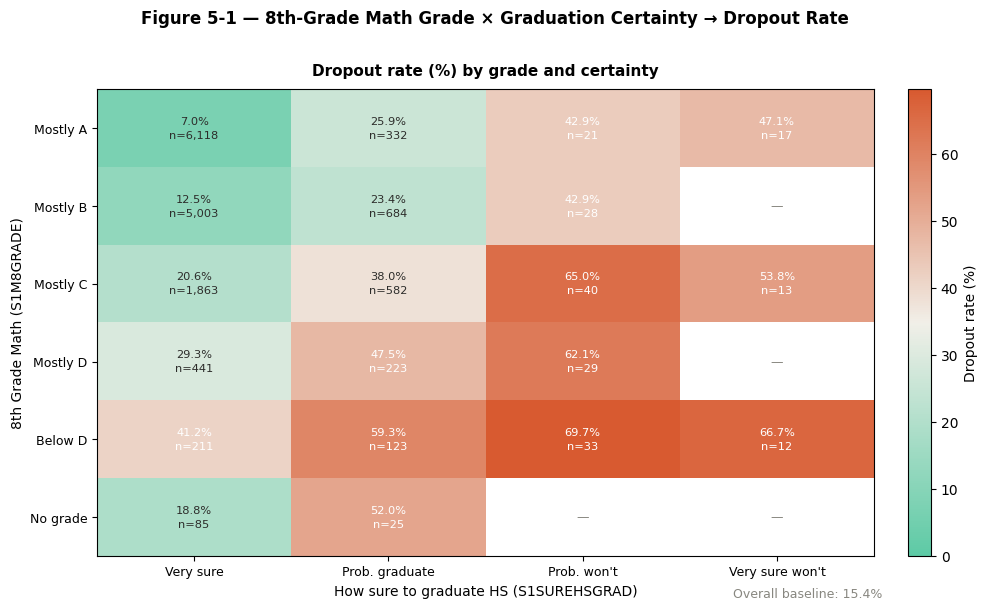

Saved → step5_fig1_grades_x_certainty.png


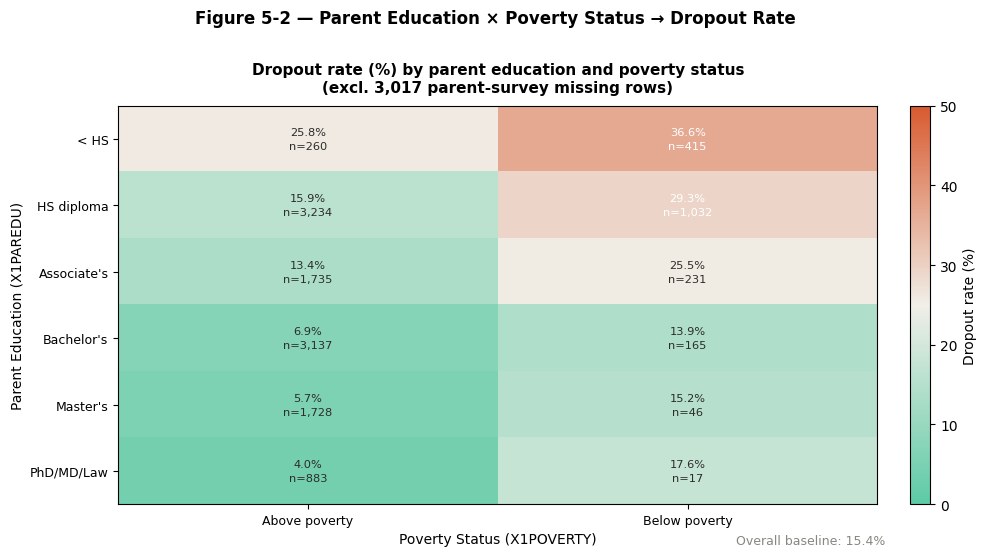

Saved → step5_fig2_paredu_x_poverty.png


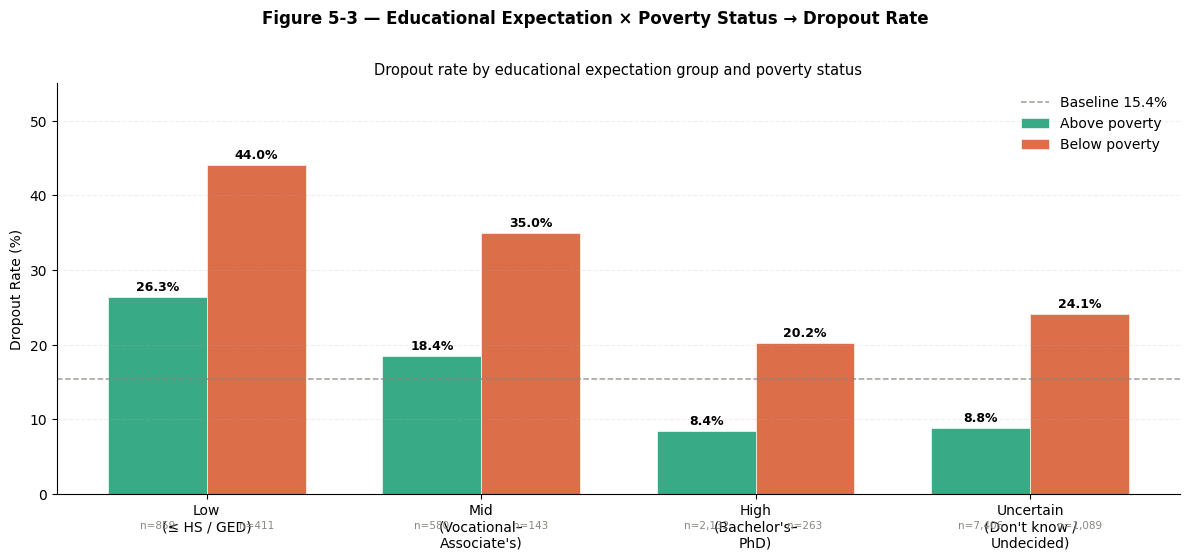

Saved → step5_fig3_eduexp_x_poverty.png


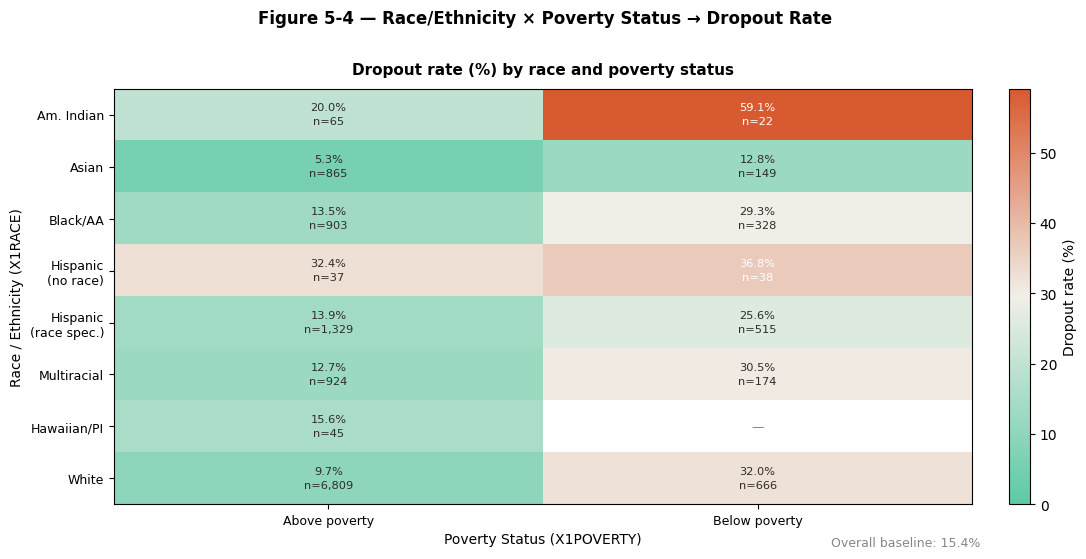

Saved → step5_fig4_race_x_poverty.png


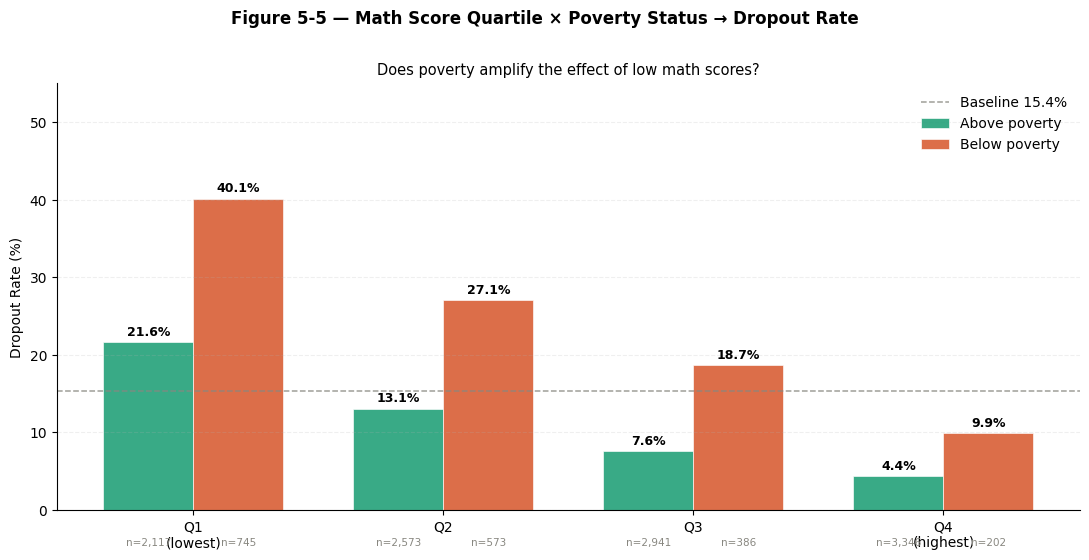

Saved → step5_fig5_mathscore_x_poverty.png


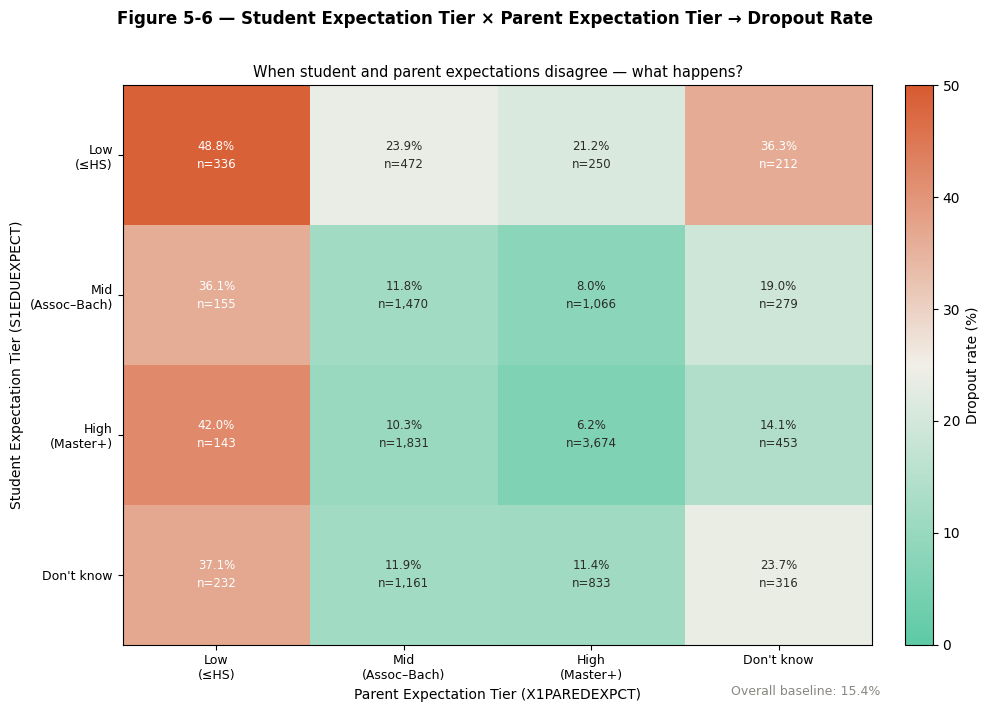

Saved → step5_fig6_stuexp_x_parexp.png


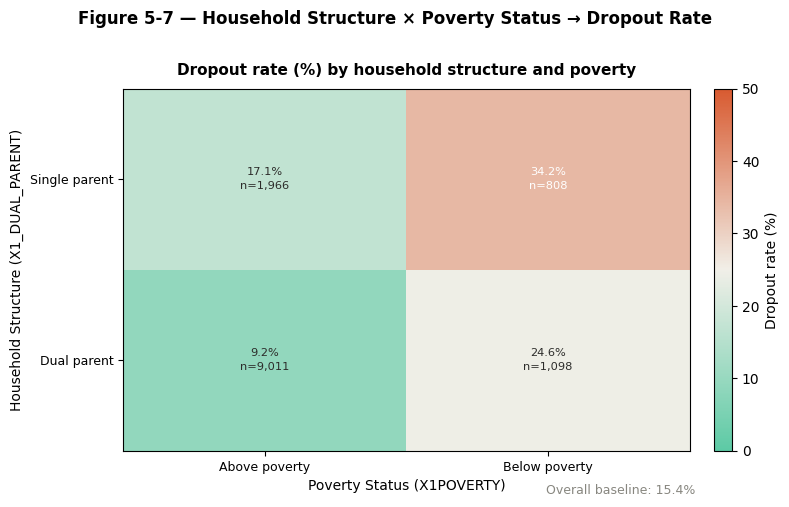

Saved → step5_fig7_dualparent_x_poverty.png


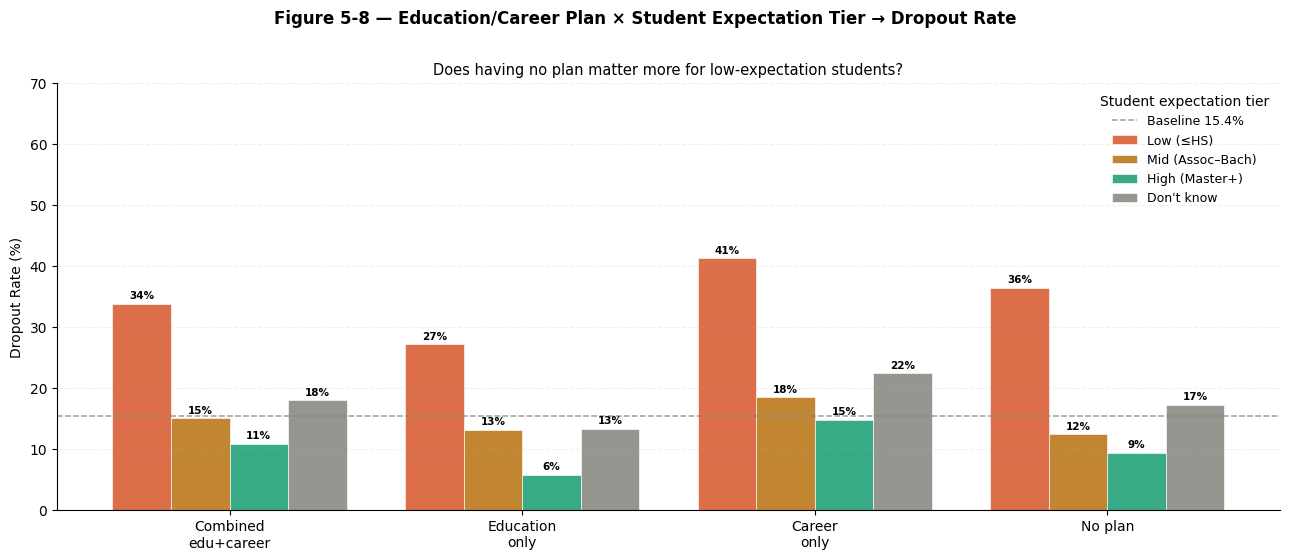

Saved → step5_fig8_plan_x_eduexpect.png


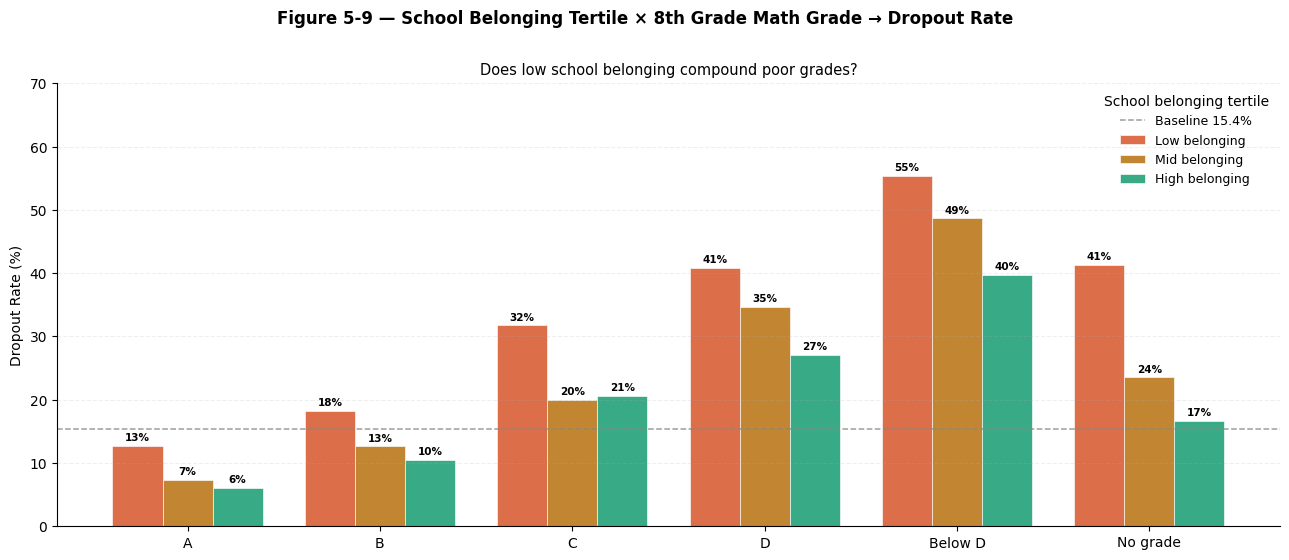

Saved → step5_fig9_belonging_x_grades.png


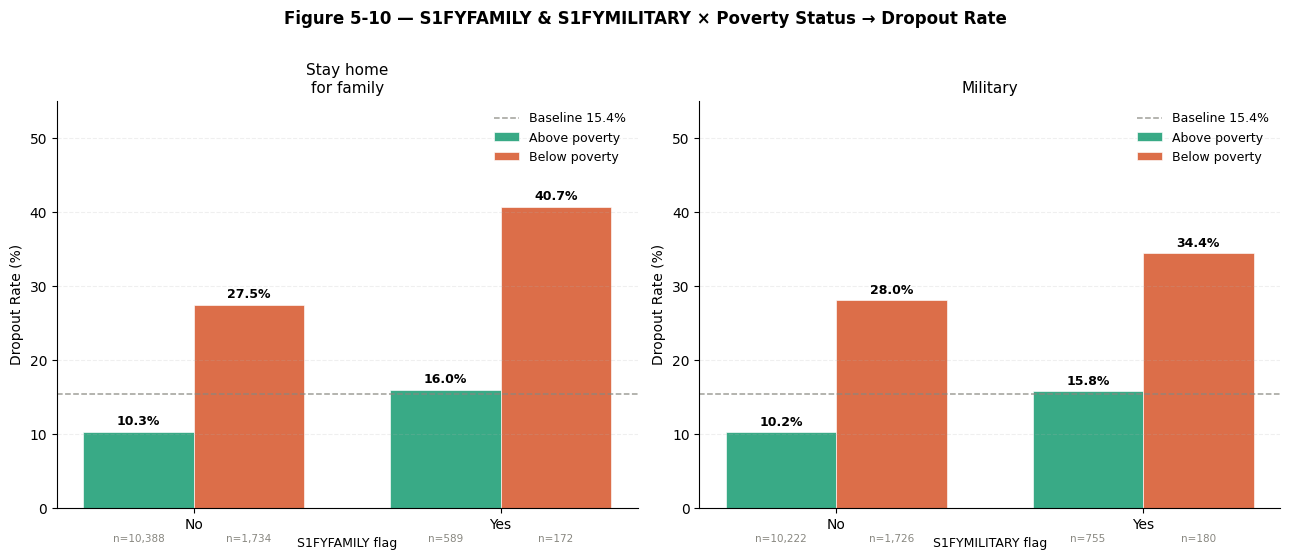

Saved → step5_fig10_fyfamily_fymilitary_x_poverty.png

  STEP 5 — MULTIVARIATE SUMMARY: KEY INTERACTION EFFECTS

  Baseline dropout rate: 15.4%

--- Fig 5-1: Grades × Graduation Certainty ---
  Lowest risk  (A grade, very sure)          : 7.0%
  A grade, prob. graduate                    : 25.9%
  Highest risk (below D, prob. won't grad.)  : 69.7%
  Range across all cells: 7.0% – 69.7%

--- Fig 5-2: Parent Education × Poverty ---
  Worst combo  (<HS + below poverty)         : 36.6%
  Best combo   (Master's + above poverty)    : 5.7%
  HS diploma: above=15.9% → below=29.3%
  Bachelor's: above=6.9%  → below=13.9%

--- Fig 5-3: Educational Expectation Group × Poverty ---
  Low
(≤ HS / GED): above=26.3%  below=44.0%  Δ=+17.7pp
  Mid
(Vocational–
Associate's): above=18.4%  below=35.0%  Δ=+16.5pp
  High
(Bachelor's–
PhD): above=8.4%  below=20.2%  Δ=+11.7pp
  Uncertain
(Don't know /
Undeci: above=8.8%  below=24.1%  Δ=+15.3pp

--- Fig 5-4: Race × Poverty ---
  Am. Indian               : above=

In [11]:
BASE_DR = df["X4EVERDROP"].mean() * 100

# ── Palette ───────────────────────────────────────────────────
C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

CMAP_DROP = LinearSegmentedColormap.from_list(
    "dropout", ["#5DCAA5", "#F1EFE8", "#D85A30"], N=256
)

def dropout_heatmap(ax, row_col, col_col, row_labels, col_labels,
                    title, row_name, col_name, fmt=".1f", min_n=10):
    piv_rate  = df.pivot_table(index=row_col, columns=col_col,
                                values="X4EVERDROP", aggfunc="mean") * 100
    piv_count = df.pivot_table(index=row_col, columns=col_col,
                                values="X4EVERDROP", aggfunc="count")

    row_keys = sorted([k for k in row_labels if k in piv_rate.index])
    col_keys = sorted([k for k in col_labels if k in piv_rate.columns])
    piv_rate  = piv_rate.reindex(index=row_keys, columns=col_keys)
    piv_count = piv_count.reindex(index=row_keys, columns=col_keys)

    mask = piv_count < min_n
    display = piv_rate.copy()
    display[mask] = np.nan

    im = ax.imshow(display.values, cmap=CMAP_DROP, aspect="auto",
                   vmin=0, vmax=max(50, np.nanmax(display.values)))

    for i in range(len(row_keys)):
        for j in range(len(col_keys)):
            val = display.values[i, j]
            n   = piv_count.values[i, j] if not np.isnan(piv_count.values[i, j]) else 0
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=9, color=C_GRAY)
            else:
                bg = val / max(50, np.nanmax(display.values))
                txt_color = "white" if bg > 0.55 else "#2C2C2A"
                ax.text(j, i, f"{val:{fmt}}%\nn={int(n):,}",
                        ha="center", va="center", fontsize=8.2,
                        color=txt_color, linespacing=1.5)

    ax.set_xticks(range(len(col_keys)))
    ax.set_yticks(range(len(row_keys)))
    ax.set_xticklabels([col_labels[k] for k in col_keys], fontsize=9)
    ax.set_yticklabels([row_labels[k] for k in row_keys], fontsize=9)
    ax.set_xlabel(col_name, fontsize=10)
    ax.set_ylabel(row_name, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    plt.colorbar(im, ax=ax, label="Dropout rate (%)", fraction=0.035, pad=0.04)
    return im


# ─────────────────────────────────────────────────────────────
# FIGURE 5-1 — Grades × Graduation Certainty
# ─────────────────────────────────────────────────────────────
grade_labels = {1:"Mostly A", 2:"Mostly B", 3:"Mostly C",
                4:"Mostly D", 5:"Below D",  6:"No grade"}
sure_labels  = {1:"Very sure", 2:"Prob. graduate",
                3:"Prob. won't", 4:"Very sure won't"}

fig1, ax = plt.subplots(figsize=(10, 6))
fig1.suptitle(
    "Figure 5-1 — 8th-Grade Math Grade × Graduation Certainty → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)
dropout_heatmap(ax, "S1M8GRADE", "S1SUREHSGRAD",
                grade_labels, sure_labels,
                "Dropout rate (%) by grade and certainty",
                "8th Grade Math (S1M8GRADE)",
                "How sure to graduate HS (S1SUREHSGRAD)")

ax.text(1.01, -0.09,
        f"Overall baseline: {BASE_DR:.1f}%",
        transform=ax.transAxes, fontsize=9,
        color=C_GRAY, ha="right")

plt.tight_layout()
plt.savefig("step5_fig1_grades_x_certainty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig1_grades_x_certainty.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-2 — Parent Education × Poverty
# ─────────────────────────────────────────────────────────────
paredu_labels  = {1:"< HS", 2:"HS diploma", 3:"Associate's",
                  4:"Bachelor's", 5:"Master's", 7:"PhD/MD/Law"}
poverty_labels = {0.0: "Above poverty", 1.0: "Below poverty"}

fig2, ax = plt.subplots(figsize=(10, 5.5))
fig2.suptitle(
    "Figure 5-2 — Parent Education × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)
dropout_heatmap(ax, "X1PAREDU", "X1POVERTY",
                paredu_labels, poverty_labels,
                "Dropout rate (%) by parent education and poverty status\n"
                "(excl. 3,017 parent-survey missing rows)",
                "Parent Education (X1PAREDU)",
                "Poverty Status (X1POVERTY)")

ax.text(1.01, -0.10,
        f"Overall baseline: {BASE_DR:.1f}%",
        transform=ax.transAxes, fontsize=9,
        color=C_GRAY, ha="right")

plt.tight_layout()
plt.savefig("step5_fig2_paredu_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig2_paredu_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-3 — Educational Expectation Group × Poverty
# ─────────────────────────────────────────────────────────────
df["EDUEXP_GRP"] = pd.cut(
    df["S1EDUEXPECT"],
    bins=[0, 2, 4, 7, 11],
    labels=["Low\n(≤ HS / GED)", "Mid\n(Vocational–\nAssociate's)",
            "High\n(Bachelor's–\nPhD)", "Uncertain\n(Don't know /\nUndecided)"]
)

grp_df = (
    df.dropna(subset=["X1POVERTY"])
      .groupby(["EDUEXP_GRP", "X1POVERTY"], observed=True)["X4EVERDROP"]
      .agg(["mean", "count"])
      .reset_index()
)
grp_df["rate"] = grp_df["mean"] * 100
grp_df["pov_label"] = grp_df["X1POVERTY"].map({0.0: "Above poverty", 1.0: "Below poverty"})

groups = grp_df["EDUEXP_GRP"].unique()
x      = np.arange(len(groups))
w      = 0.36

fig3, ax = plt.subplots(figsize=(12, 5.5))
fig3.suptitle(
    "Figure 5-3 — Educational Expectation × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)

for offset, pov_val, color, lbl in [
    (-w/2, 0.0, C_TEAL,  "Above poverty"),
    ( w/2, 1.0, C_CORAL, "Below poverty"),
]:
    sub = grp_df[grp_df["X1POVERTY"] == pov_val].set_index("EDUEXP_GRP")
    vals = [sub.loc[g, "rate"]  if g in sub.index else np.nan for g in groups]
    ns   = [sub.loc[g, "count"] if g in sub.index else 0       for g in groups]

    bars = ax.bar(x + offset, vals, width=w,
                  color=color, edgecolor="white",
                  linewidth=0.5, alpha=0.88, label=lbl)
    for bar, v, n in zip(bars, vals, ns):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{v:.1f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold")
            ax.text(bar.get_x() + bar.get_width()/2, -3.5,
                    f"n={int(n):,}", ha="center", va="top",
                    fontsize=7.5, color=C_GRAY)

ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
           linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=10)
ax.set_ylabel("Dropout Rate (%)", fontsize=10)
ax.set_ylim(0, 55)
ax.set_title("Dropout rate by educational expectation group and poverty status",
             fontsize=10.5)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("step5_fig3_eduexp_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig3_eduexp_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-4 — Race × Poverty
# ─────────────────────────────────────────────────────────────
race_labels = {
    1:"Am. Indian",          2:"Asian",          3:"Black/AA",
    4:"Hispanic\n(no race)", 5:"Hispanic\n(race spec.)", 6:"Multiracial",
    7:"Hawaiian/PI",         8:"White"
}

fig4, ax = plt.subplots(figsize=(11, 5.5))
fig4.suptitle(
    "Figure 5-4 — Race/Ethnicity × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)
dropout_heatmap(ax, "X1RACE", "X1POVERTY",
                race_labels, poverty_labels,
                "Dropout rate (%) by race and poverty status",
                "Race / Ethnicity (X1RACE)",
                "Poverty Status (X1POVERTY)",
                min_n=15)

ax.text(1.01, -0.10,
        f"Overall baseline: {BASE_DR:.1f}%",
        transform=ax.transAxes, fontsize=9,
        color=C_GRAY, ha="right")

plt.tight_layout()
plt.savefig("step5_fig4_race_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig4_race_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-5 — Math Score Quartile × Poverty         ← NEW
# ─────────────────────────────────────────────────────────────
# Bin continuous math score into quartiles for heatmap display
df["TXMTSCOR_Q"] = pd.qcut(df["X1TXMTSCOR"], q=4,
                            labels=["Q1\n(lowest)", "Q2", "Q3", "Q4\n(highest)"])

mathq_labels = {0:"Q1\n(lowest)", 1:"Q2", 2:"Q3", 3:"Q4\n(highest)"}

grp_mathpov = (
    df.dropna(subset=["X1POVERTY", "TXMTSCOR_Q"])
      .groupby(["TXMTSCOR_Q", "X1POVERTY"], observed=True)["X4EVERDROP"]
      .agg(["mean", "count"])
      .reset_index()
)
grp_mathpov["rate"] = grp_mathpov["mean"] * 100
grp_mathpov["pov_label"] = grp_mathpov["X1POVERTY"].map(
    {0.0: "Above poverty", 1.0: "Below poverty"})

quartiles = grp_mathpov["TXMTSCOR_Q"].unique()
x5 = np.arange(len(quartiles))

fig5, ax = plt.subplots(figsize=(11, 5.5))
fig5.suptitle(
    "Figure 5-5 — Math Score Quartile × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)

for offset, pov_val, color, lbl in [
    (-w/2, 0.0, C_TEAL,  "Above poverty"),
    ( w/2, 1.0, C_CORAL, "Below poverty"),
]:
    sub = grp_mathpov[grp_mathpov["X1POVERTY"] == pov_val].set_index("TXMTSCOR_Q")
    vals = [sub.loc[g, "rate"]  if g in sub.index else np.nan for g in quartiles]
    ns   = [sub.loc[g, "count"] if g in sub.index else 0       for g in quartiles]

    bars = ax.bar(x5 + offset, vals, width=w,
                  color=color, edgecolor="white",
                  linewidth=0.5, alpha=0.88, label=lbl)
    for bar, v, n in zip(bars, vals, ns):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{v:.1f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold")
            ax.text(bar.get_x() + bar.get_width()/2, -3.5,
                    f"n={int(n):,}", ha="center", va="top",
                    fontsize=7.5, color=C_GRAY)

ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
           linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
ax.set_xticks(x5)
ax.set_xticklabels(quartiles, fontsize=10)
ax.set_ylabel("Dropout Rate (%)", fontsize=10)
ax.set_ylim(0, 55)
ax.set_title("Does poverty amplify the effect of low math scores?", fontsize=10.5)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("step5_fig5_mathscore_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig5_mathscore_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-6 — Student Expectation × Parent Expectation  ← NEW
# ─────────────────────────────────────────────────────────────
# Group both into 3 tiers: Low (≤HS), Mid (Assoc–Bach), High (Master+/DK)
def expect_tier(col):
    return df[col].map(lambda x: (
        "Low\n(≤HS)"      if x in [1, 2] else
        "Mid\n(Assoc–Bach)" if x in [3, 4, 5, 6] else
        "High\n(Master+)"  if x in [7, 8, 9, 10] else
        "Don't know"       if x == 11 else np.nan
    ))

df["STU_EXP_TIER"] = expect_tier("S1EDUEXPECT")
df["PAR_EXP_TIER"] = expect_tier("X1PAREDEXPCT")

tier_order = ["Low\n(≤HS)", "Mid\n(Assoc–Bach)", "High\n(Master+)", "Don't know"]

grp_exp = (
    df.dropna(subset=["STU_EXP_TIER", "PAR_EXP_TIER"])
      .groupby(["STU_EXP_TIER", "PAR_EXP_TIER"], observed=True)["X4EVERDROP"]
      .agg(["mean", "count"])
      .reset_index()
)
grp_exp["rate"] = grp_exp["mean"] * 100

piv_exp  = grp_exp.pivot(index="STU_EXP_TIER",
                          columns="PAR_EXP_TIER", values="rate").reindex(
                              index=tier_order, columns=tier_order)
piv_exp_n = grp_exp.pivot(index="STU_EXP_TIER",
                           columns="PAR_EXP_TIER", values="count").reindex(
                               index=tier_order, columns=tier_order)

fig6, ax = plt.subplots(figsize=(10, 7))
fig6.suptitle(
    "Figure 5-6 — Student Expectation Tier × Parent Expectation Tier → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)

im = ax.imshow(piv_exp.values, cmap=CMAP_DROP, aspect="auto",
               vmin=0, vmax=max(50, np.nanmax(piv_exp.values)))

for i in range(len(tier_order)):
    for j in range(len(tier_order)):
        val = piv_exp.values[i, j]
        n   = piv_exp_n.values[i, j]
        if np.isnan(val):
            ax.text(j, i, "—", ha="center", va="center", fontsize=9, color=C_GRAY)
        else:
            bg = val / max(50, np.nanmax(piv_exp.values))
            txt_color = "white" if bg > 0.55 else "#2C2C2A"
            ax.text(j, i, f"{val:.1f}%\nn={int(n):,}",
                    ha="center", va="center", fontsize=8.5,
                    color=txt_color, linespacing=1.5)

ax.set_xticks(range(len(tier_order)))
ax.set_yticks(range(len(tier_order)))
ax.set_xticklabels(tier_order, fontsize=9)
ax.set_yticklabels(tier_order, fontsize=9)
ax.set_xlabel("Parent Expectation Tier (X1PAREDEXPCT)", fontsize=10)
ax.set_ylabel("Student Expectation Tier (S1EDUEXPECT)", fontsize=10)
ax.set_title("When student and parent expectations disagree — what happens?",
             fontsize=10.5)
plt.colorbar(im, ax=ax, label="Dropout rate (%)", fraction=0.035, pad=0.04)

ax.text(1.01, -0.09, f"Overall baseline: {BASE_DR:.1f}%",
        transform=ax.transAxes, fontsize=9, color=C_GRAY, ha="right")

plt.tight_layout()
plt.savefig("step5_fig6_stuexp_x_parexp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig6_stuexp_x_parexp.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-7 — Dual Parent × Poverty                    ← NEW
# ─────────────────────────────────────────────────────────────
dual_labels    = {0: "Single parent", 1: "Dual parent"}
poverty_labels = {0.0: "Above poverty", 1.0: "Below poverty"}

fig7, ax = plt.subplots(figsize=(8, 5))
fig7.suptitle(
    "Figure 5-7 — Household Structure × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)
dropout_heatmap(ax, "X1_DUAL_PARENT", "X1POVERTY",
                dual_labels, poverty_labels,
                "Dropout rate (%) by household structure and poverty",
                "Household Structure (X1_DUAL_PARENT)",
                "Poverty Status (X1POVERTY)")

ax.text(1.01, -0.12, f"Overall baseline: {BASE_DR:.1f}%",
        transform=ax.transAxes, fontsize=9, color=C_GRAY, ha="right")

plt.tight_layout()
plt.savefig("step5_fig7_dualparent_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig7_dualparent_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-8 — S1PLAN × Educational Expectation         ← NEW
# ─────────────────────────────────────────────────────────────
plan_labels = {1:"Combined\nedu+career", 2:"Education\nonly",
               3:"Career\nonly",         4:"No plan"}

grp_plan = (
    df.dropna(subset=["STU_EXP_TIER"])
      .groupby(["S1PLAN", "STU_EXP_TIER"], observed=True)["X4EVERDROP"]
      .agg(["mean", "count"])
      .reset_index()
)
grp_plan["rate"] = grp_plan["mean"] * 100

plan_keys  = [1, 2, 3, 4]
tier_order3 = ["Low\n(≤HS)", "Mid\n(Assoc–Bach)", "High\n(Master+)", "Don't know"]
colors_tier = [C_CORAL, C_AMBER, C_TEAL, C_GRAY]

x8  = np.arange(len(plan_keys))
w8  = 0.20
fig8, ax = plt.subplots(figsize=(13, 5.5))
fig8.suptitle(
    "Figure 5-8 — Education/Career Plan × Student Expectation Tier → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)

for k, (tier, color) in enumerate(zip(tier_order3, colors_tier)):
    sub = grp_plan[grp_plan["STU_EXP_TIER"] == tier].set_index("S1PLAN")
    vals = [sub.loc[p, "rate"]  if p in sub.index else np.nan for p in plan_keys]
    ns   = [sub.loc[p, "count"] if p in sub.index else 0       for p in plan_keys]
    offset = (k - 1.5) * w8
    bars = ax.bar(x8 + offset, vals, width=w8,
                  color=color, edgecolor="white",
                  linewidth=0.5, alpha=0.88, label=tier.replace("\n", " "))
    for bar, v, n in zip(bars, vals, ns):
        if not np.isnan(v) and n >= 10:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{v:.0f}%", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")

ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
           linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
ax.set_xticks(x8)
ax.set_xticklabels([plan_labels[p] for p in plan_keys], fontsize=10)
ax.set_ylabel("Dropout Rate (%)", fontsize=10)
ax.set_ylim(0, 70)
ax.set_title("Does having no plan matter more for low-expectation students?",
             fontsize=10.5)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=9, frameon=False, title="Student expectation tier")

plt.tight_layout()
plt.savefig("step5_fig8_plan_x_eduexpect.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig8_plan_x_eduexpect.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-9 — School Belonging × Grades               ← NEW
# ─────────────────────────────────────────────────────────────
# Bin school belonging into tertiles: Low / Mid / High
df["BEL_TERT"] = pd.qcut(df["X1SCHOOLBEL"], q=3,
                          labels=["Low\nbelonging", "Mid\nbelonging", "High\nbelonging"])

bel_labels   = {0:"Low\nbelonging", 1:"Mid\nbelonging", 2:"High\nbelonging"}
grade_labels2 = {1:"A", 2:"B", 3:"C", 4:"D", 5:"Below D", 6:"No grade"}

grp_bel = (
    df.dropna(subset=["BEL_TERT"])
      .groupby(["S1M8GRADE", "BEL_TERT"], observed=True)["X4EVERDROP"]
      .agg(["mean", "count"])
      .reset_index()
)
grp_bel["rate"] = grp_bel["mean"] * 100

grade_keys = [1, 2, 3, 4, 5, 6]
bel_terts  = ["Low\nbelonging", "Mid\nbelonging", "High\nbelonging"]
bel_colors = [C_CORAL, C_AMBER, C_TEAL]
w9 = 0.26
x9 = np.arange(len(grade_keys))

fig9, ax = plt.subplots(figsize=(13, 5.5))
fig9.suptitle(
    "Figure 5-9 — School Belonging Tertile × 8th Grade Math Grade → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)

for k, (tert, color) in enumerate(zip(bel_terts, bel_colors)):
    sub = grp_bel[grp_bel["BEL_TERT"] == tert].set_index("S1M8GRADE")
    vals = [sub.loc[g, "rate"]  if g in sub.index else np.nan for g in grade_keys]
    ns   = [sub.loc[g, "count"] if g in sub.index else 0       for g in grade_keys]
    offset = (k - 1) * w9
    bars = ax.bar(x9 + offset, vals, width=w9,
                  color=color, edgecolor="white",
                  linewidth=0.5, alpha=0.88, label=tert.replace("\n", " "))
    for bar, v, n in zip(bars, vals, ns):
        if not np.isnan(v) and n >= 10:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{v:.0f}%", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")

ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
           linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
ax.set_xticks(x9)
ax.set_xticklabels([grade_labels2[g] for g in grade_keys], fontsize=10)
ax.set_ylabel("Dropout Rate (%)", fontsize=10)
ax.set_ylim(0, 70)
ax.set_title("Does low school belonging compound poor grades?", fontsize=10.5)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, linestyle="--")
ax.legend(fontsize=9, frameon=False, title="School belonging tertile")

plt.tight_layout()
plt.savefig("step5_fig9_belonging_x_grades.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig9_belonging_x_grades.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 5-10 — S1FYFAMILY & S1FYMILITARY × Poverty    ← NEW
# ─────────────────────────────────────────────────────────────
fy_flags = {
    "S1FYFAMILY" : ("Stay home\nfor family", C_CORAL),
    "S1FYMILITARY": ("Military",             C_BLUE),
}

fig10, axes10 = plt.subplots(1, 2, figsize=(13, 5.5))
fig10.suptitle(
    "Figure 5-10 — S1FYFAMILY & S1FYMILITARY × Poverty Status → Dropout Rate",
    fontsize=12, fontweight="bold", y=1.01
)

for ax, (col, (title, color)) in zip(axes10, fy_flags.items()):
    grp = (
        df.dropna(subset=["X1POVERTY"])
          .groupby([col, "X1POVERTY"])["X4EVERDROP"]
          .agg(["mean", "count"])
          .reset_index()
    )
    grp["rate"] = grp["mean"] * 100
    grp["pov_label"] = grp["X1POVERTY"].map({0.0:"Above poverty", 1.0:"Below poverty"})
    grp["flag_label"] = grp[col].map({0:"No", 1:"Yes"})

    flag_vals = [0, 1]
    pov_vals  = [0.0, 1.0]
    pov_colors = [C_TEAL, C_CORAL]
    x10 = np.arange(len(flag_vals))

    for k, (pov, pc, pl) in enumerate(zip(pov_vals, pov_colors,
                                           ["Above poverty", "Below poverty"])):
        sub = grp[grp["X1POVERTY"] == pov].set_index(col)
        vals = [sub.loc[f, "rate"]  if f in sub.index else np.nan for f in flag_vals]
        ns   = [sub.loc[f, "count"] if f in sub.index else 0       for f in flag_vals]
        offset = (k - 0.5) * w
        bars = ax.bar(x10 + offset, vals, width=w,
                      color=pc, edgecolor="white",
                      linewidth=0.5, alpha=0.88, label=pl)
        for bar, v, n in zip(bars, vals, ns):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f"{v:.1f}%", ha="center", va="bottom",
                        fontsize=9, fontweight="bold")
                ax.text(bar.get_x() + bar.get_width()/2, -3.5,
                        f"n={int(n):,}", ha="center", va="top",
                        fontsize=7.5, color=C_GRAY)

    ax.axhline(BASE_DR, color=C_GRAY, linestyle="--",
               linewidth=1.1, alpha=0.8, label=f"Baseline {BASE_DR:.1f}%")
    ax.set_xticks(x10)
    ax.set_xticklabels(["No", "Yes"], fontsize=10)
    ax.set_xlabel(f"{col} flag", fontsize=9)
    ax.set_ylabel("Dropout Rate (%)", fontsize=10)
    ax.set_ylim(0, 55)
    ax.set_title(title, fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linestyle="--")
    ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("step5_fig10_fyfamily_fymilitary_x_poverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_fig10_fyfamily_fymilitary_x_poverty.png")


# ─────────────────────────────────────────────────────────────
# PRINTED SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  STEP 5 — MULTIVARIATE SUMMARY: KEY INTERACTION EFFECTS")
print("="*65)
print(f"\n  Baseline dropout rate: {BASE_DR:.1f}%\n")

print("--- Fig 5-1: Grades × Graduation Certainty ---")
piv = df.pivot_table(index="S1M8GRADE", columns="S1SUREHSGRAD",
                      values="X4EVERDROP", aggfunc="mean") * 100
print(f"  Lowest risk  (A grade, very sure)          : {piv.loc[1,1]:.1f}%")
print(f"  A grade, prob. graduate                    : {piv.loc[1,2]:.1f}%")
print(f"  Highest risk (below D, prob. won't grad.)  : {piv.loc[5,3]:.1f}%")
print(f"  Range across all cells: {piv.min().min():.1f}% – {piv.max().max():.1f}%")

print("\n--- Fig 5-2: Parent Education × Poverty ---")
piv2 = df.pivot_table(index="X1PAREDU", columns="X1POVERTY",
                       values="X4EVERDROP", aggfunc="mean") * 100
print(f"  Worst combo  (<HS + below poverty)         : {piv2.loc[1.0,1.0]:.1f}%")
print(f"  Best combo   (Master's + above poverty)    : {piv2.loc[5.0,0.0]:.1f}%")
print(f"  HS diploma: above={piv2.loc[2.0,0.0]:.1f}% → below={piv2.loc[2.0,1.0]:.1f}%")
print(f"  Bachelor's: above={piv2.loc[4.0,0.0]:.1f}%  → below={piv2.loc[4.0,1.0]:.1f}%")

print("\n--- Fig 5-3: Educational Expectation Group × Poverty ---")
for grp in grp_df["EDUEXP_GRP"].unique():
    sub0 = grp_df[(grp_df["EDUEXP_GRP"]==grp) & (grp_df["X1POVERTY"]==0.0)]
    sub1 = grp_df[(grp_df["EDUEXP_GRP"]==grp) & (grp_df["X1POVERTY"]==1.0)]
    if not sub0.empty and not sub1.empty:
        r0 = sub0["rate"].values[0]; r1 = sub1["rate"].values[0]
        print(f"  {str(grp)[:30]}: above={r0:.1f}%  below={r1:.1f}%  Δ={r1-r0:+.1f}pp")

print("\n--- Fig 5-4: Race × Poverty ---")
piv4 = df.dropna(subset=["X1POVERTY"]).pivot_table(
    index="X1RACE", columns="X1POVERTY",
    values="X4EVERDROP", aggfunc="mean") * 100
piv4_n = df.dropna(subset=["X1POVERTY"]).pivot_table(
    index="X1RACE", columns="X1POVERTY",
    values="X4EVERDROP", aggfunc="count")
for race_code, race_name in race_labels.items():
    if race_code in piv4.index:
        above   = piv4.loc[race_code, 0.0]
        below   = piv4.loc[race_code, 1.0] if 1.0 in piv4.columns else np.nan
        n_above = int(piv4_n.loc[race_code, 0.0])
        n_below = int(piv4_n.loc[race_code, 1.0]) if 1.0 in piv4_n.columns else 0
        diff    = below - above if not np.isnan(below) else np.nan
        print(f"  {race_name.replace(chr(10),' '):<25}: "
              f"above={above:.1f}%(n={n_above})  "
              f"below={below:.1f}%(n={n_below})  Δ={diff:+.1f}pp")

print("\n--- Fig 5-5: Math Score Quartile × Poverty ---")
for pov_val, pov_lbl in [(0.0, "Above poverty"), (1.0, "Below poverty")]:
    sub = grp_mathpov[grp_mathpov["X1POVERTY"] == pov_val]
    for _, row in sub.iterrows():
        print(f"  {pov_lbl} | {row['TXMTSCOR_Q']}: {row['rate']:.1f}%  (n={int(row['count']):,})")

print("\n--- Fig 5-6: Student Expectation × Parent Expectation ---")
print(piv_exp.round(1).to_string())

print("\n--- Fig 5-7: Dual Parent × Poverty ---")
piv7 = df.pivot_table(index="X1_DUAL_PARENT", columns="X1POVERTY",
                       values="X4EVERDROP", aggfunc="mean") * 100
for dp, lbl in [(0, "Single parent"), (1, "Dual parent")]:
    if dp in piv7.index:
        above = piv7.loc[dp, 0.0]; below = piv7.loc[dp, 1.0]
        print(f"  {lbl}: above={above:.1f}%  below={below:.1f}%  Δ={below-above:+.1f}pp")

print("\n--- Fig 5-8: S1PLAN × Student Expectation Tier ---")
for plan_k, plan_lbl in plan_labels.items():
    sub = grp_plan[grp_plan["S1PLAN"] == plan_k]
    vals_str = "  |  ".join(
        [f"{t.replace(chr(10),' ')}: {sub.loc[sub['STU_EXP_TIER']==t,'rate'].values[0]:.1f}%"
         for t in tier_order3 if t in sub["STU_EXP_TIER"].values]
    )
    print(f"  {plan_lbl.replace(chr(10),' '):<20}: {vals_str}")

print("\n--- Fig 5-9: School Belonging × Grades ---")
for tert in bel_terts:
    sub = grp_bel[grp_bel["BEL_TERT"] == tert]
    a_rate = sub.loc[sub["S1M8GRADE"]==1, "rate"].values
    d_rate = sub.loc[sub["S1M8GRADE"]==4, "rate"].values
    a_str = f"{a_rate[0]:.1f}%" if len(a_rate) else "—"
    d_str = f"{d_rate[0]:.1f}%" if len(d_rate) else "—"
    print(f"  {tert.replace(chr(10),' '):<20}: A-grade={a_str}  D-grade={d_str}")

print("\n--- Fig 5-10: S1FYFAMILY & S1FYMILITARY × Poverty ---")
for col in ["S1FYFAMILY", "S1FYMILITARY"]:
    grp_fy = (
        df.dropna(subset=["X1POVERTY"])
          .groupby([col, "X1POVERTY"])["X4EVERDROP"]
          .agg(["mean", "count"]).reset_index()
    )
    grp_fy["rate"] = grp_fy["mean"] * 100
    for flag_val, flag_lbl in [(0, "No"), (1, "Yes")]:
        sub = grp_fy[grp_fy[col] == flag_val]
        above = sub.loc[sub["X1POVERTY"]==0.0, "rate"].values
        below = sub.loc[sub["X1POVERTY"]==1.0, "rate"].values
        a_str = f"{above[0]:.1f}%" if len(above) else "—"
        b_str = f"{below[0]:.1f}%" if len(below) else "—"
        print(f"  {col}={flag_lbl}: above={a_str}  below={b_str}")

## Key Takeaways from Step 5 — Multivariate Analysis

### Figure 5-1 — Grades × Graduation Certainty
* This is the widest dropout range in the dataset: 7.0% (A grade, very sure) → 69.7% (below D, probably won't graduate) — a nearly 10× spread driven by just two features combined.
* Certainty adds independent risk within each grade band. An A-student who only "probably will graduate" already jumps to 25.9% — nearly 4× the best-case risk — showing that attitude and academic performance capture different dimensions of risk.
* The bottom-left (A/B + very sure) cells account for the bulk of the student population, making the top-right (C–D + uncertain) corner a genuinely identifiable, small, high-risk subgroup worth targeting in any early-warning system.

### Figure 5-2 — Parent Education × Poverty
* The SES gradient runs diagonally: the worst corner is <HS + below poverty at 36.6%, the best is Master's above poverty at 5.7% — a 6.4× gap.
* Poverty amplifies dropout risk at every education level, but the amplification is largest at lower tiers — HS diploma goes from 15.9% above poverty to 29.3% below poverty, nearly doubling. At Bachelor's level, poverty still pushes risk from 6.9% → 13.9%, staying near baseline.
* This suggests an interaction term between `X1PAREDU` and `X1POVERTY` may improve model performance.

### Figure 5-3 — Educational Expectation × Poverty
* Poverty acts as a consistent risk amplifier across all expectation groups: Low (+17.7pp), Mid (+16.5pp), Uncertain (+15.3pp), High (+11.7pp). Higher expectations partially dampen — but do not eliminate — the poverty penalty.
* The "Uncertain" group above poverty (8.8%) is nearly identical in risk to the High expectation group above poverty (8.4%) — suggesting that uncertainty about the future, in the absence of poverty, is not strongly predictive on its own. Poverty is what activates the risk.

### Figure 5-4 — Race × Poverty
* For every racial group, falling below the poverty line substantially increases dropout risk, though the poverty penalty is not uniform across groups.
* The largest poverty-driven jump is among American Indian students (+39.1pp: 20.0% → 59.1%), followed by White (+22.3pp) and Multiracial (+17.8pp). Small sample sizes in some cells (Am. Indian below poverty n=22) mean these estimates should be interpreted with caution.
* Asian students remain the lowest-risk group even below the poverty line (12.8%). Notably, Hispanic (no race) students show a small poverty gap (+4.4pp) because their above-poverty rate is already high at 32.4% — suggesting structural risk factors beyond poverty for this group.
* For most racial groups, above-poverty dropout rates cluster near or below baseline — reinforcing that poverty, not race, is the primary driver of excess risk.

### Figure 5-5 — Math Score Quartile × Poverty
* Poverty amplifies the effect of low math scores, but high math scores partially offset poverty. The gap is largest in Q1 (21.6% above poverty vs. 40.1% below poverty, +18.5pp) and shrinks substantially by Q4 (4.4% vs. 9.9%, +5.5pp).
* A high-scoring student in poverty (Q4, 9.9%) faces lower risk than a low-scoring student above poverty (Q1, 21.6%) — meaning strong academic ability is a meaningful protective factor even under economic hardship.
* This confirms that `X1TXMTSCOR` and `X1POVERTY` should both be in the model and may benefit from an interaction term.

### Figure 5-6 — Student Expectation × Parent Expectation
* This is one of the most important figures in the analysis. When both student and parent expectations are high (Master+), dropout is only 6.2%. When both are low (≤HS), it reaches 48.8%.
* The most striking finding: students with high expectations but low-expectation parents still drop out at 42.0% — nearly as bad as when both are low. Parent expectations appear to dominate: a student cannot fully overcome low parental expectations through their own aspirations alone.
* The reverse is also true but weaker: students with low expectations but high-expectation parents drop out at 21.2% — still elevated, but meaningfully lower than the 48.8% when both are low. Parent expectations act as a floor on risk.
* "Don't know" parent expectations carry elevated risk (14.1%–37.1% depending on student tier), confirming that parental uncertainty is a genuine risk signal, not just missing data.

### Figure 5-7 — Household Structure × Poverty
* The finding here is that poverty and household structure are largely **independent** risk factors rather than interacting. Single-parent above poverty: 17.1%; single-parent below poverty: 34.2% (+17.0pp). Dual-parent above poverty: 9.2%; dual-parent below poverty: 24.6% (+15.4pp). The poverty gap is nearly identical across household types.
* This means `X1_DUAL_PARENT` and `X1POVERTY` each contribute separately — an interaction term between them is unlikely to add much model value.

### Figure 5-8 — S1PLAN × Student Expectation
* Having no plan barely matters for high-expectation students (9% dropout for "No plan + High expectations") but is severely risky for low-expectation students (36% for "No plan + Low expectations").
* The riskiest combination in this figure is Career-only plan + Low expectations at 41% — higher than "No plan" at the same expectation tier (36%). A career-only orientation combined with low academic aspirations is a stronger warning sign than having no plan at all.
* Education-only planners are the most protected group at every expectation tier, dropping as low as 6% for high-expectation students.

### Figure 5-9 — School Belonging × Grades
* Low belonging compounds poor grades significantly. A below-D student with low belonging hits 55% dropout vs. 40% for high belonging — a 15pp difference within the same grade band.
* For A-students, belonging barely matters (13% vs. 6%) — strong academic performance largely overrides belonging effects at the top. The compounding effect is most severe at the bottom of the grade distribution.
* This confirms `X1SCHOOLBEL` adds independent signal beyond grades and should be retained in the model, particularly for identifying students already struggling academically.

### Figure 5-10 — S1FYFAMILY & S1FYMILITARY × Poverty
* The key finding here is that both flags' bivariate risk signal from Step 4 was largely driven by poverty overlap rather than the plan itself. Above poverty, S1FYFAMILY=Yes is only 16.0% and S1FYMILITARY=Yes is 15.8% — both at or barely above baseline.
* Below poverty, both flags spike (40.7% and 34.4% respectively), but so does the "No" group — meaning poor students are high-risk regardless of whether they plan to stay home for family or join the military.
* Conclusion: these flags are not independently predictive once poverty is controlled for. They can likely be deprioritised in modeling.

---



## Hypotheses for the Report

1. **The grades × certainty interaction will be one of the most informative feature pairs.** A binned interaction term between `S1M8GRADE` and `S1SUREHSGRAD` could capture the high-risk corner (poor grades + low certainty) that neither feature detects alone — spanning 7.0% to 69.7% dropout in this analysis.

2. **Parent expectations dominate student expectations.** Figure 5-6 shows that a student's own high aspirations cannot fully overcome low parental expectations (42.0% dropout). Both should be in the model simultaneously, and their interaction — particularly the "student high, parent low" mismatch cell — may be worth engineering as a feature.

3. **Poverty is a universal risk amplifier but interacts differently across features.** It nearly doubles the grade effect (Fig 5-5), compounds racial disparities unevenly (Fig 5-4), and operates independently of household structure (Fig 5-7). The model should include `X1POVERTY` as a main effect and test interaction terms with `X1TXMTSCOR` and `X1PAREDU` specifically.

4. **Racial disparities in dropout are substantially driven by poverty rather than race alone.** For most groups, above-poverty rates cluster near baseline — a model without SES controls risks misattributing poverty effects to race. The exception is Hispanic (no race) students, who show high dropout rates even above poverty, suggesting structural risk factors beyond income for this specific group.

5. **S1FYFAMILY and S1FYMILITARY should be deprioritised.** Their Step 4 signal was poverty-driven. Above poverty, both flags sit at baseline. They are unlikely to survive feature selection once poverty is in the model.

6. **Plan type only matters when combined with low expectations.** "No plan" is not a standalone risk factor (9% dropout for high-expectation students with no plan). The meaningful risk is the combination of low expectations + career-only or no plan. An interaction term between `S1PLAN` and `S1EDUEXPECT` is worth testing.

# EDA - Step 6: Correlation Analysis

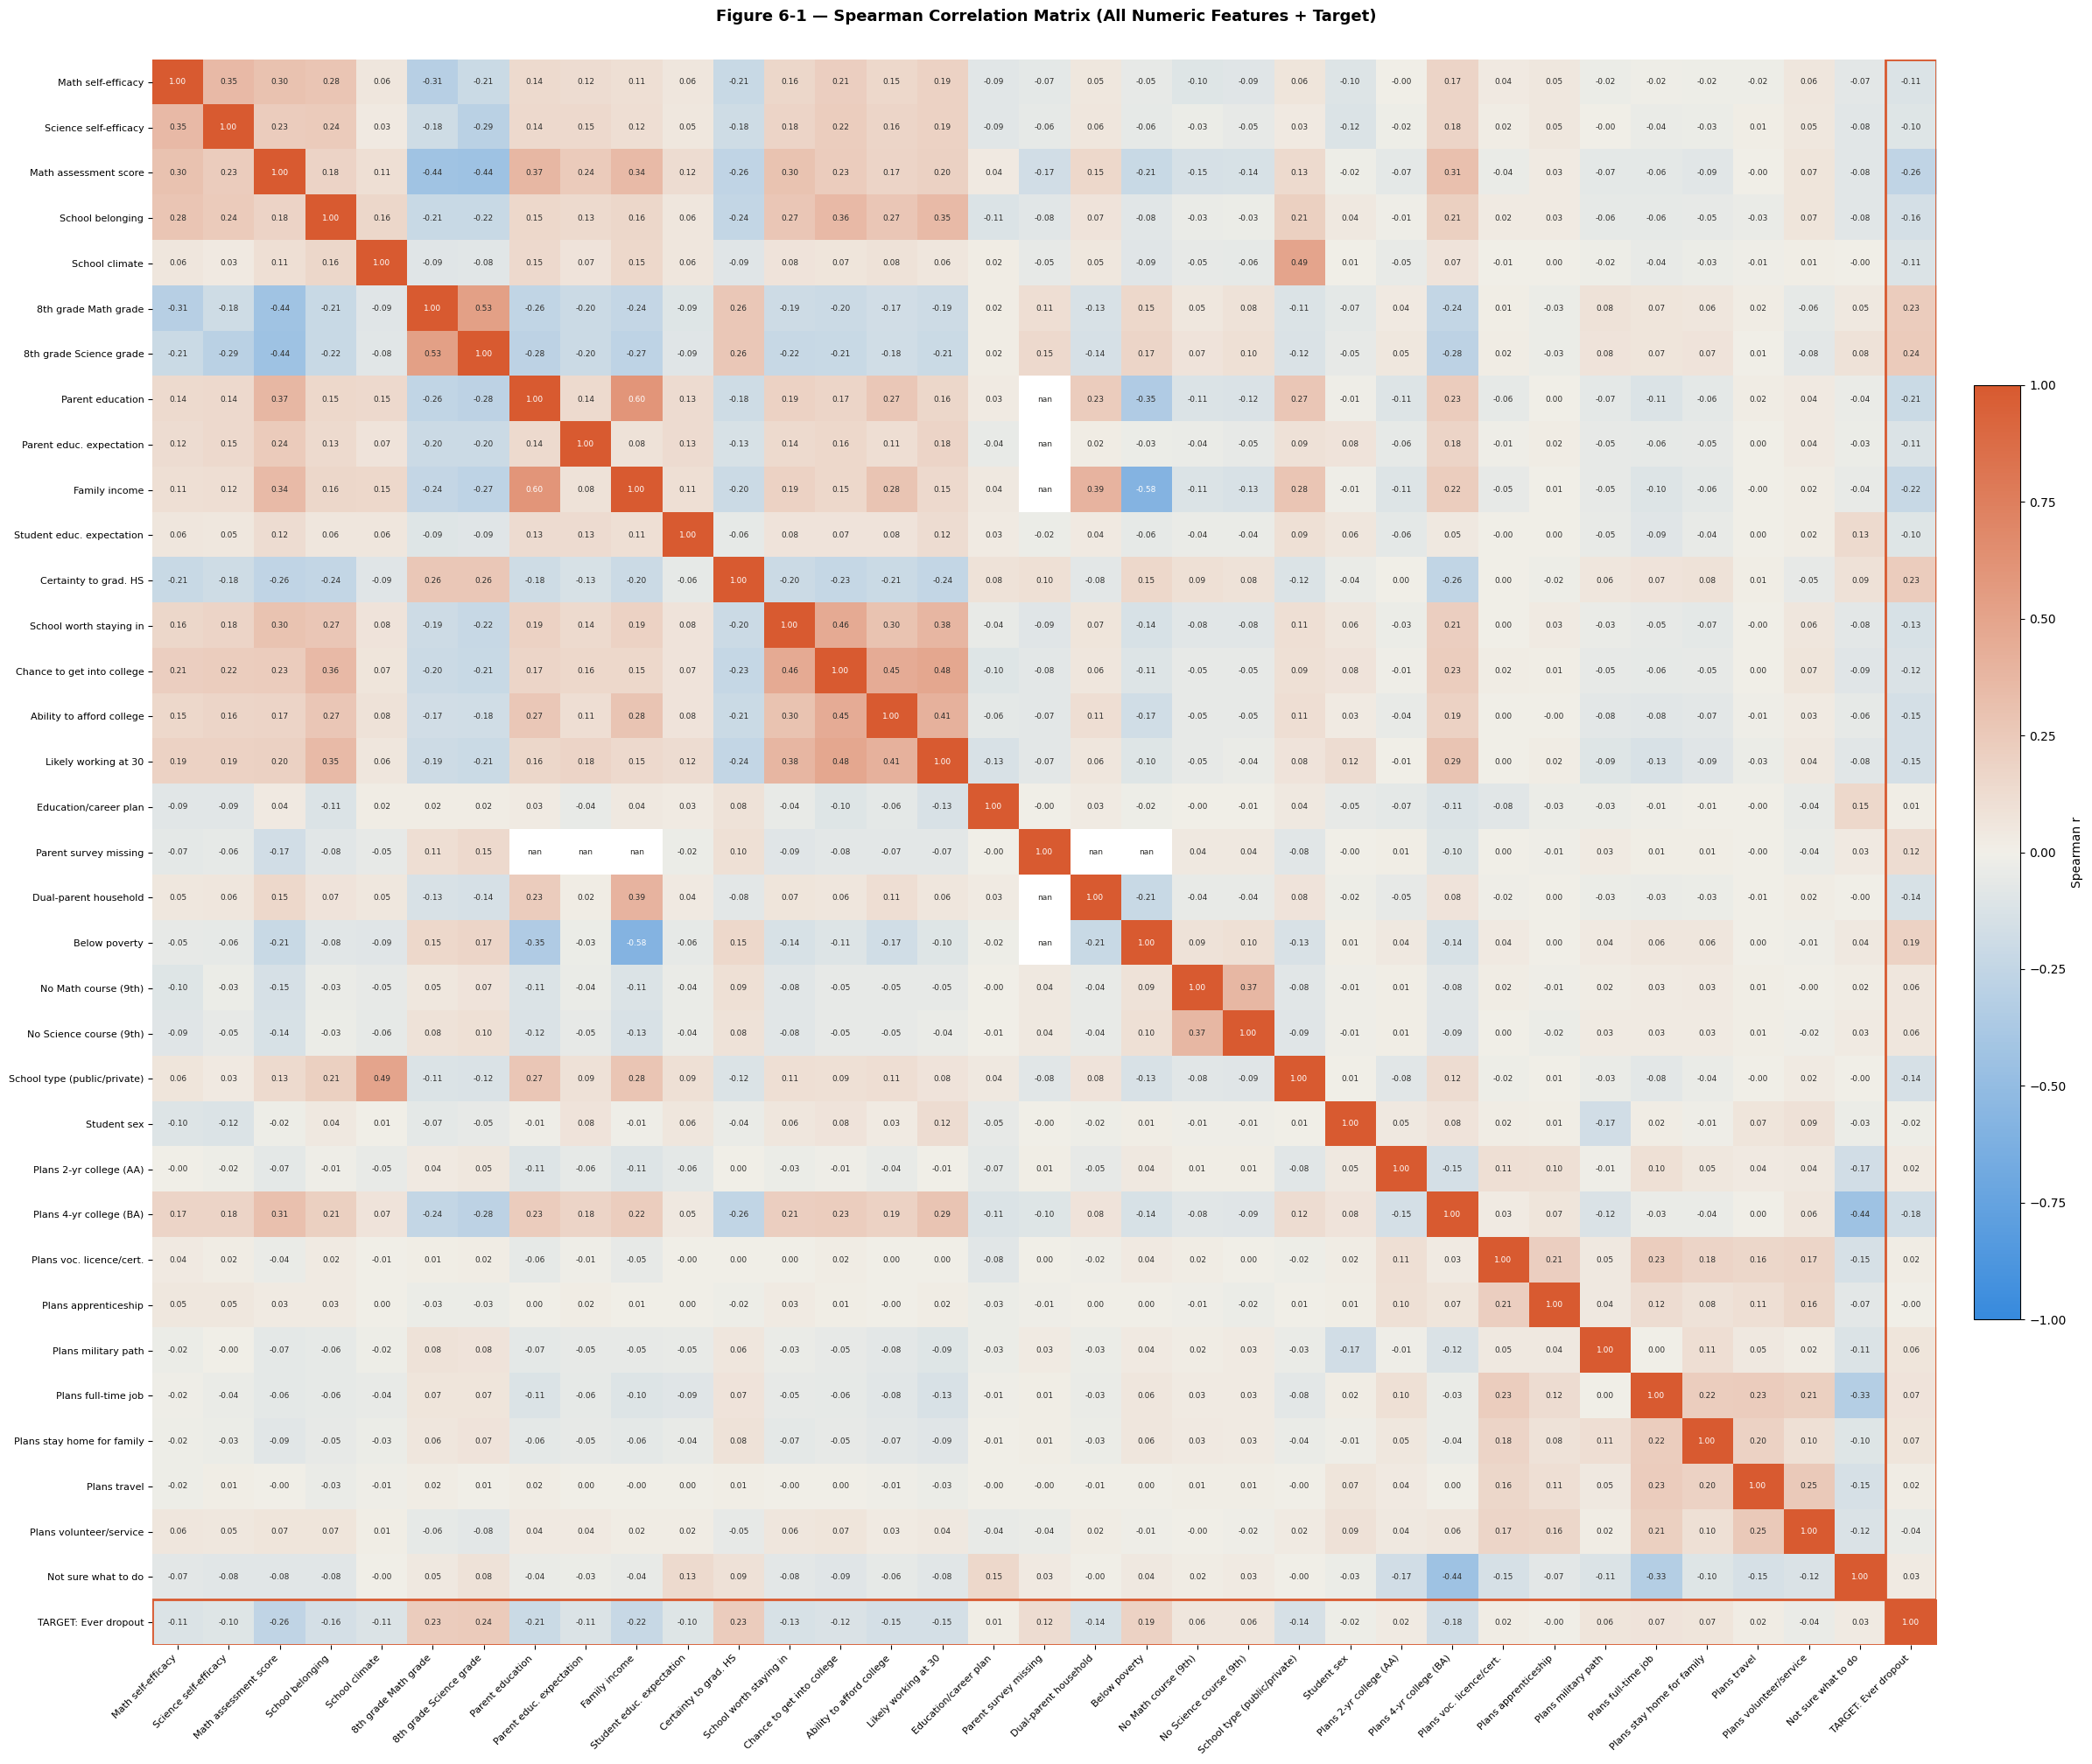

Saved → step6_fig1_corr_heatmap.png


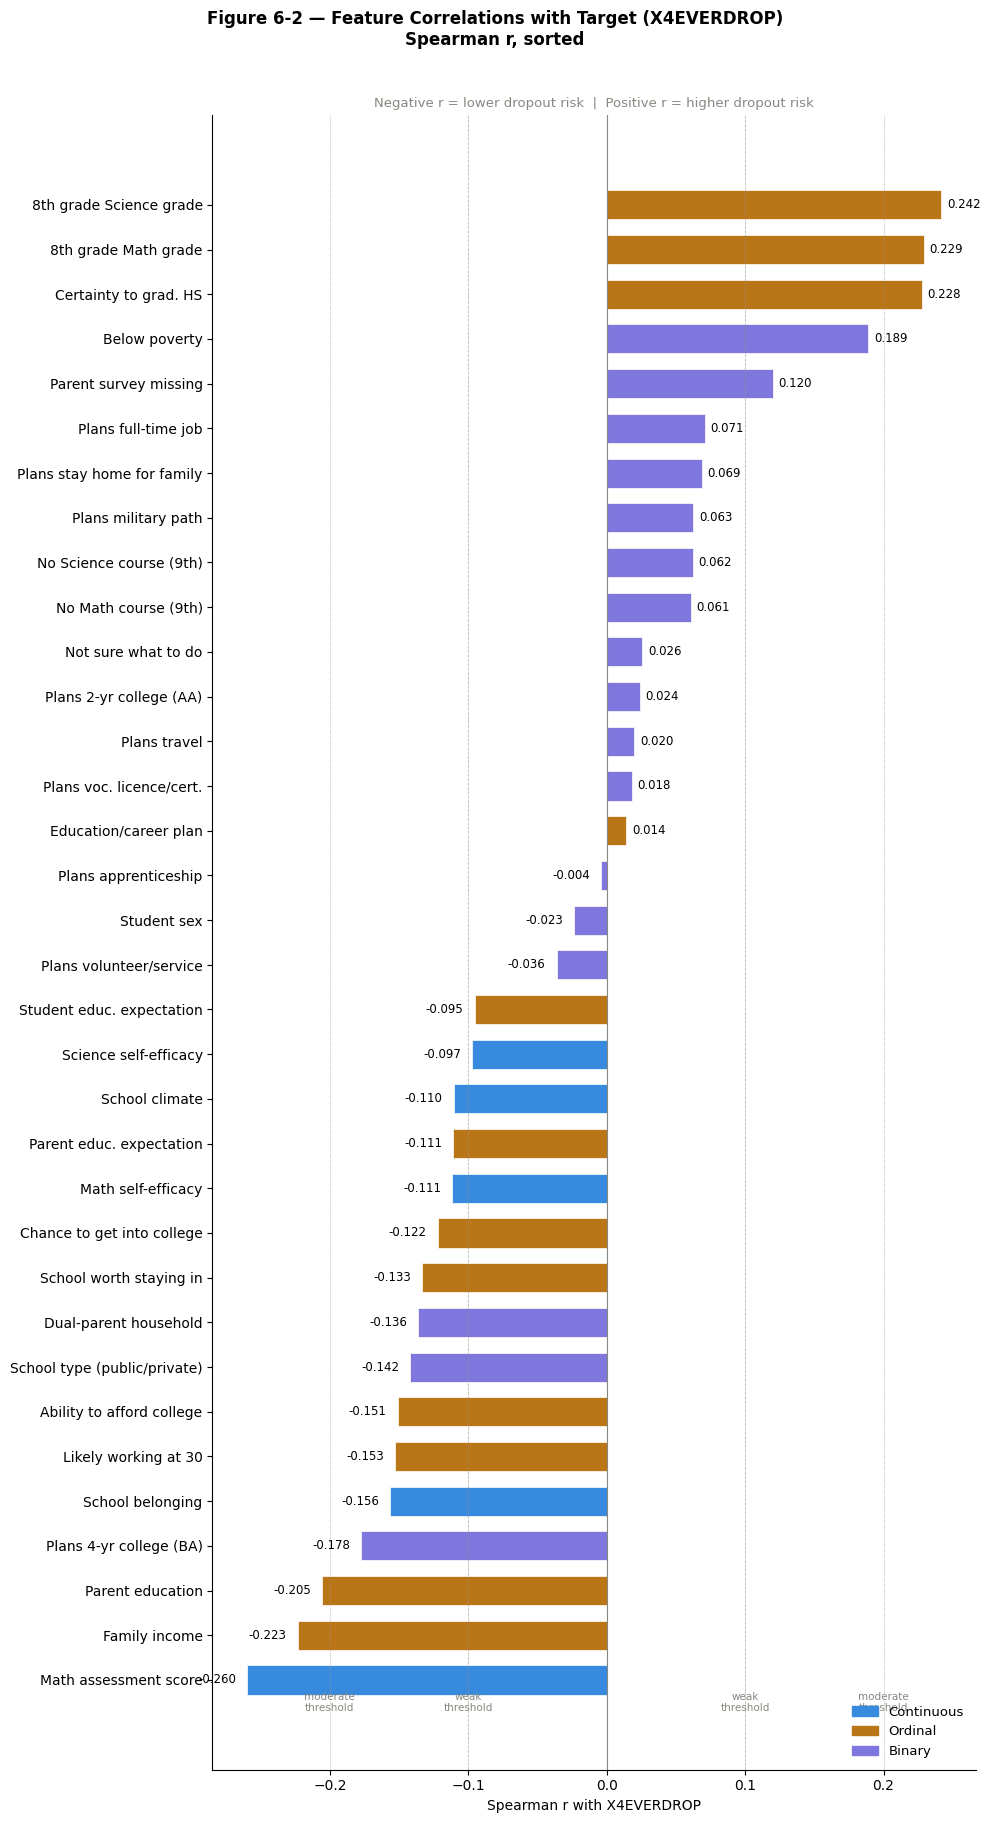

Saved → step6_fig2_target_corr_ranked.png


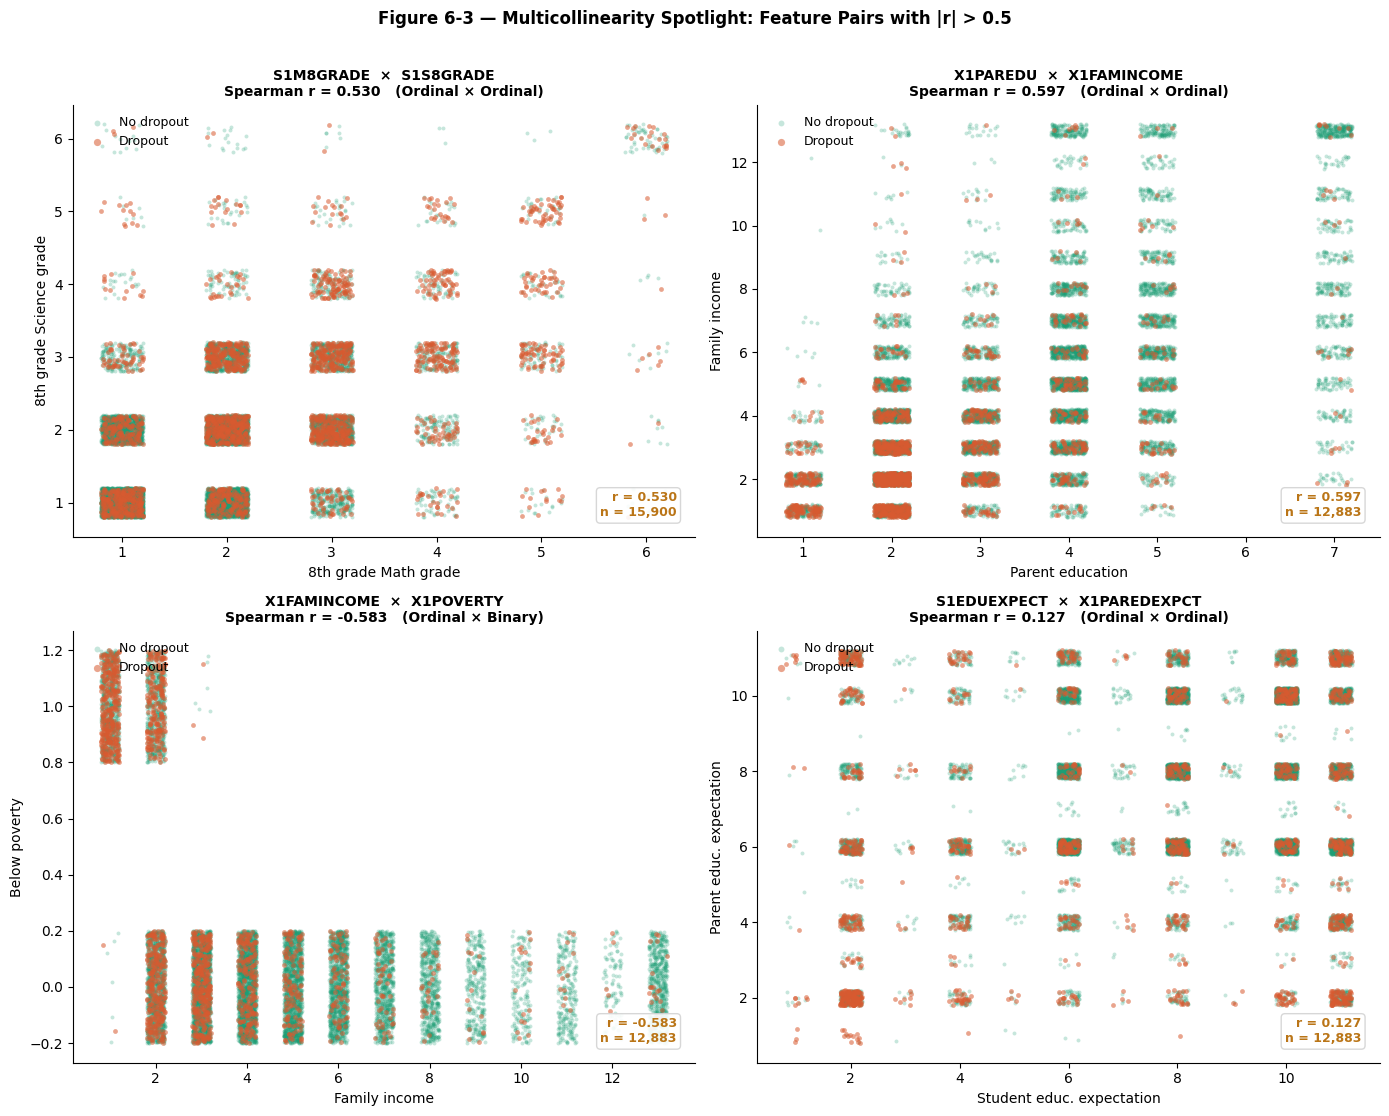

Saved → step6_fig3_multicollinearity.png

  STEP 6 — CORRELATION ANALYSIS SUMMARY

--- Spearman r with X4EVERDROP (all features) ---
  Math assessment score              : r = -0.260  |strong|
  Family income                      : r = -0.223  |strong|
  Parent education                   : r = -0.205  |strong|
  Plans 4-yr college (BA)            : r = -0.178  |moderate|
  School belonging                   : r = -0.156  |moderate|
  Likely working at 30               : r = -0.153  |moderate|
  Ability to afford college          : r = -0.151  |moderate|
  School type (public/private)       : r = -0.142  |moderate|
  Dual-parent household              : r = -0.136  |moderate|
  School worth staying in            : r = -0.133  |moderate|
  Chance to get into college         : r = -0.122  |moderate|
  Math self-efficacy                 : r = -0.111  |moderate|
  Parent educ. expectation           : r = -0.111  |moderate|
  School climate                     : r = -0.110  |moderate|
  Sci

In [12]:
from scipy.stats import spearmanr

# ── Feature groups ────────────────────────────────────────────
continuous  = ["X1MTHEFF","X1SCIEFF","X1TXMTSCOR","X1SCHOOLBEL","X1SCHOOLCLI"]
ordinal     = ["S1M8GRADE","S1S8GRADE","X1PAREDU","X1PAREDEXPCT","X1FAMINCOME",
               "S1EDUEXPECT","S1SUREHSGRAD","S1PAYOFF","S1GETINTOCLG","S1AFFORD",
               "S1WORKING","S1PLAN"]
# CHANGED: added X1CONTROL and X2SEX
binary      = ["X1PAR_SURVEY_MISSING","X1_DUAL_PARENT","X1POVERTY","MATH_NO_CLASS",
               "SCI_NO_CLASS","X1CONTROL","X2SEX","S1FYAA","S1FYBA","S1FYLICENSE",
               "S1FYAPPR","S1FYMILITARY","S1FYJOB","S1FYFAMILY","S1FYTRAVEL",
               "S1FYVOLUN","S1FYNOTSURE"]

all_features = continuous + ordinal + binary
all_cols     = all_features + ["X4EVERDROP"]

# ── Friendly display names ────────────────────────────────────
# CHANGED: added X1CONTROL and X2SEX entries
NAMES = {
    "X1MTHEFF"             : "Math self-efficacy",
    "X1SCIEFF"             : "Science self-efficacy",
    "X1TXMTSCOR"           : "Math assessment score",
    "X1SCHOOLBEL"          : "School belonging",
    "X1SCHOOLCLI"          : "School climate",
    "S1M8GRADE"            : "8th grade Math grade",
    "S1S8GRADE"            : "8th grade Science grade",
    "X1PAREDU"             : "Parent education",
    "X1PAREDEXPCT"         : "Parent educ. expectation",
    "X1FAMINCOME"          : "Family income",
    "S1EDUEXPECT"          : "Student educ. expectation",
    "S1SUREHSGRAD"         : "Certainty to grad. HS",
    "S1PAYOFF"             : "School worth staying in",
    "S1GETINTOCLG"         : "Chance to get into college",
    "S1AFFORD"             : "Ability to afford college",
    "S1WORKING"            : "Likely working at 30",
    "S1PLAN"               : "Education/career plan",
    "X1PAR_SURVEY_MISSING" : "Parent survey missing",
    "X1_DUAL_PARENT"       : "Dual-parent household",
    "X1POVERTY"            : "Below poverty",
    "MATH_NO_CLASS"        : "No Math course (9th)",
    "SCI_NO_CLASS"         : "No Science course (9th)",
    "X1CONTROL"            : "School type (public/private)",
    "X2SEX"                : "Student sex",
    "S1FYAA"               : "Plans 2-yr college (AA)",
    "S1FYBA"               : "Plans 4-yr college (BA)",
    "S1FYLICENSE"          : "Plans voc. licence/cert.",
    "S1FYAPPR"             : "Plans apprenticeship",
    "S1FYMILITARY"         : "Plans military path",
    "S1FYJOB"              : "Plans full-time job",
    "S1FYFAMILY"           : "Plans stay home for family",
    "S1FYTRAVEL"           : "Plans travel",
    "S1FYVOLUN"            : "Plans volunteer/service",
    "S1FYNOTSURE"          : "Not sure what to do",
    "X4EVERDROP"           : "TARGET: Ever dropout",
}

# ── Palette ───────────────────────────────────────────────────
C_TEAL  = "#1D9E75"
C_CORAL = "#D85A30"
C_BLUE  = "#378ADD"
C_AMBER = "#BA7517"
C_GRAY  = "#888780"
C_PURP  = "#7F77DD"

# ── Compute Spearman correlation matrix ──────────────────────
df_num  = df[all_cols].copy()
corr_sp = df_num.corr(method="spearman")
disp_labels = [NAMES.get(c, c) for c in all_cols]


# ─────────────────────────────────────────────────────────────
# FIGURE 6-1 — Full Spearman Heatmap
# ─────────────────────────────────────────────────────────────
CMAP_DIV = LinearSegmentedColormap.from_list(
    "div", ["#378ADD", "#F1EFE8", "#D85A30"], N=256
)

n = len(all_cols)
# CHANGED: increased figsize to accommodate 34 features
fig1, ax = plt.subplots(figsize=(24, 20))
fig1.suptitle(
    "Figure 6-1 — Spearman Correlation Matrix (All Numeric Features + Target)",
    fontsize=13, fontweight="bold", y=1.005
)

im = ax.imshow(corr_sp.values, cmap=CMAP_DIV, vmin=-1, vmax=1, aspect="auto")

for i in range(n):
    for j in range(n):
        val = corr_sp.values[i, j]
        txt_color = "white" if abs(val) > 0.55 else "#2C2C2A"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6.5, color=txt_color)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(disp_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(disp_labels, fontsize=8)

for spine in ax.spines.values():
    spine.set_visible(False)

target_idx = all_cols.index("X4EVERDROP")
ax.add_patch(plt.Rectangle(
    (target_idx - 0.5, -0.5), 1, n,
    fill=False, edgecolor="#D85A30", linewidth=2, zorder=5
))
ax.add_patch(plt.Rectangle(
    (-0.5, target_idx - 0.5), n, 1,
    fill=False, edgecolor="#D85A30", linewidth=2, zorder=5
))

plt.colorbar(im, ax=ax, label="Spearman r", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.savefig("step6_fig1_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step6_fig1_corr_heatmap.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 6-2 — Ranked correlations with target
# ─────────────────────────────────────────────────────────────
target_corr = (
    corr_sp["X4EVERDROP"]
    .drop("X4EVERDROP")
    .sort_values()
)

feature_type = {}
for c in continuous : feature_type[c] = "Continuous"
for c in ordinal    : feature_type[c] = "Ordinal"
for c in binary     : feature_type[c] = "Binary"

color_by_type = {
    "Continuous": C_BLUE,
    "Ordinal"   : C_AMBER,
    "Binary"    : C_PURP,
}

bar_colors = [color_by_type[feature_type[c]] for c in target_corr.index]

# CHANGED: increased height to 18 to fit 34 features
fig2, ax = plt.subplots(figsize=(10, 18))
fig2.suptitle(
    "Figure 6-2 — Feature Correlations with Target (X4EVERDROP)\nSpearman r, sorted",
    fontsize=12, fontweight="bold", y=1.01
)

bars = ax.barh(
    [NAMES.get(c, c) for c in target_corr.index],
    target_corr.values,
    color=bar_colors, edgecolor="white", linewidth=0.5, height=0.65
)

for bar, val in zip(bars, target_corr.values):
    xpos = val - 0.008 if val < 0 else val + 0.004
    ha   = "right"     if val < 0 else "left"
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha=ha, fontsize=8.5)

ax.axvline(0,    color=C_GRAY, linewidth=0.8, linestyle="-")
ax.axvline( 0.1, color=C_GRAY, linewidth=0.6, linestyle="--", alpha=0.5)
ax.axvline(-0.1, color=C_GRAY, linewidth=0.6, linestyle="--", alpha=0.5)
ax.axvline( 0.2, color=C_GRAY, linewidth=0.6, linestyle=":",  alpha=0.5)
ax.axvline(-0.2, color=C_GRAY, linewidth=0.6, linestyle=":",  alpha=0.5)

ax.set_xlabel("Spearman r with X4EVERDROP", fontsize=10)
ax.set_title("Negative r = lower dropout risk  |  Positive r = higher dropout risk",
             fontsize=9.5, color=C_GRAY, pad=6)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2, linestyle="--")

ax.text( 0.1,  -0.7, "weak\nthreshold",     ha="center", fontsize=7.5, color=C_GRAY)
ax.text(-0.1,  -0.7, "weak\nthreshold",     ha="center", fontsize=7.5, color=C_GRAY)
ax.text( 0.2,  -0.7, "moderate\nthreshold", ha="center", fontsize=7.5, color=C_GRAY)
ax.text(-0.2,  -0.7, "moderate\nthreshold", ha="center", fontsize=7.5, color=C_GRAY)

legend_patches = [
    mpatches.Patch(color=C_BLUE,  label="Continuous"),
    mpatches.Patch(color=C_AMBER, label="Ordinal"),
    mpatches.Patch(color=C_PURP,  label="Binary"),
]
ax.legend(handles=legend_patches, fontsize=9.5, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("step6_fig2_target_corr_ranked.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step6_fig2_target_corr_ranked.png")


# ─────────────────────────────────────────────────────────────
# FIGURE 6-3 — Multicollinearity Spotlight
# ─────────────────────────────────────────────────────────────
multicoll_pairs = [
    ("S1M8GRADE",   "S1S8GRADE",    "Ordinal × Ordinal"),
    ("X1PAREDU",    "X1FAMINCOME",  "Ordinal × Ordinal"),
    ("X1FAMINCOME", "X1POVERTY",    "Ordinal × Binary"),
    ("S1EDUEXPECT", "X1PAREDEXPCT", "Ordinal × Ordinal"),
]

fig3, axes = plt.subplots(2, 2, figsize=(14, 11))
fig3.suptitle(
    "Figure 6-3 — Multicollinearity Spotlight: Feature Pairs with |r| > 0.5",
    fontsize=12, fontweight="bold", y=1.01
)
axes_flat = axes.flatten()

for ax, (col_a, col_b, pair_type) in zip(axes_flat, multicoll_pairs):
    sub = df[[col_a, col_b, "X4EVERDROP"]].dropna()
    r, p = spearmanr(sub[col_a], sub[col_b])

    jitter_a = sub[col_a] + np.random.uniform(-0.2, 0.2, len(sub))
    jitter_b = sub[col_b] + np.random.uniform(-0.2, 0.2, len(sub))

    for drop_val, color, label, alpha, size in [
        (0, C_TEAL,  "No dropout", 0.25, 8),
        (1, C_CORAL, "Dropout",    0.55, 12),
    ]:
        mask = sub["X4EVERDROP"] == drop_val
        ax.scatter(jitter_a[mask], jitter_b[mask],
                   c=color, alpha=alpha, s=size, linewidths=0,
                   label=label, rasterized=True)

    ax.set_xlabel(NAMES.get(col_a, col_a), fontsize=10)
    ax.set_ylabel(NAMES.get(col_b, col_b), fontsize=10)
    ax.set_title(
        f"{col_a}  ×  {col_b}\n"
        f"Spearman r = {r:.3f}   ({pair_type})",
        fontsize=10, fontweight="bold"
    )
    ax.spines[["top","right"]].set_visible(False)

    ax.text(0.97, 0.04,
            f"r = {r:.3f}\nn = {len(sub):,}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, fontweight="bold",
            color=C_CORAL if abs(r) >= 0.6 else C_AMBER,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.9))

    ax.legend(fontsize=9, frameon=False, markerscale=1.5, loc="upper left")

plt.tight_layout()
plt.savefig("step6_fig3_multicollinearity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step6_fig3_multicollinearity.png")


# ─────────────────────────────────────────────────────────────
# PRINTED SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  STEP 6 — CORRELATION ANALYSIS SUMMARY")
print("="*65)

print("\n--- Spearman r with X4EVERDROP (all features) ---")
for col in target_corr.index:
    strength = ("|strong|"   if abs(target_corr[col]) >= 0.2
                else "|moderate|" if abs(target_corr[col]) >= 0.1
                else "|weak|")
    print(f"  {NAMES.get(col,col):<35}: r = {target_corr[col]:+.3f}  {strength}")

print("\n--- Multicollinear pairs (|r| > 0.5) ---")
for col_a, col_b, pair_type in multicoll_pairs:
    sub = df[[col_a, col_b]].dropna()
    r, _ = spearmanr(sub[col_a], sub[col_b])
    print(f"  {col_a:<30} × {col_b:<30}: r = {r:+.3f}  [{pair_type}]")

print("\n--- Near-threshold pairs (0.4 < |r| ≤ 0.5) — monitor in modeling ---")
near_threshold = [
    ("X1TXMTSCOR",  "S1M8GRADE"),
    ("X1TXMTSCOR",  "S1S8GRADE"),
    ("S1GETINTOCLG","S1WORKING"),
    ("S1PAYOFF",    "S1GETINTOCLG"),
    ("S1GETINTOCLG","S1AFFORD"),
    ("S1AFFORD",    "S1WORKING"),
]
for col_a, col_b in near_threshold:
    sub = df[[col_a, col_b]].dropna()
    r, _ = spearmanr(sub[col_a], sub[col_b])
    print(f"  {col_a:<30} × {col_b:<30}: r = {r:+.3f}")

## Key Takeaways from Step 6 — Correlation Analysis

### Figure 6-1 — Full Spearman Heatmap
* The target row (highlighted in red) shows a clear split: SES and academic variables pull left (protective), while grade severity, poverty, and graduation uncertainty push right (risk).
* A dense orange cluster is visible around the SES block (`X1PAREDU` × `X1FAMINCOME` × `X1POVERTY`), confirming the multicollinearity flagged in Fig 6-3.
* The attitude cluster (`S1PAYOFF` × `S1GETINTOCLG` × `S1AFFORD` × `S1WORKING`) shows moderate internal correlation (r = 0.41–0.48), meaning these four variables are partly redundant even though no single pair exceeds the |r| > 0.5 threshold.
* `S1FYBA` (Plans 4-yr college) shows a clear blue cell against the target — one of the strongest binary protective signals, confirmed at r = −0.178.

### Figure 6-2 — Ranked correlations with target
* The top 3 positive correlates with dropout are all ordinal: 8th grade Science grade (r = +0.242), 8th grade Math grade (r = +0.229), and graduation certainty (r = +0.228). Note these are coded so that higher number = worse grade / less certain, hence the positive sign.
* The top 3 negative (protective) correlates are Math assessment score (r = −0.260), family income (r = −0.223), and parent education (r = −0.205) — all SES or academic performance signals.
* `S1FYBA` (Plans 4-yr college, r = −0.178) is the strongest binary protective feature — stronger than dual-parent household (r = −0.136) and school type (r = −0.142). Its signal is comparable to school belonging (r = −0.156).
* `X1CONTROL` (school type public/private, r = −0.142) ranks higher than expected for a binary feature — confirming the 13pp gap seen in Step 4 is real, though likely SES-confounded.
* `S1EDUEXPECT` and `X1PAREDEXPCT` show deceptively weak linear correlations (r = −0.095 and −0.111) despite being among the strongest bivariate predictors in Step 4. This is because category 11 ("Don't know") is encoded as the highest numeric value but carries elevated dropout risk — breaking the monotonic relationship and compressing the linear signal. Their true predictive power will be better captured by tree-based models.
* `X2SEX` (r = −0.023) confirms what Step 4 showed — the male/female gap is real but very small and unlikely to be a meaningful standalone predictor.
* The weakest features by linear correlation are `S1FYAPPR` (r ≈ 0), `S1FYNOTSURE` (r = +0.026), and the remaining S1FY* flags (r = 0.018–0.071). This does not mean they are useless — their signal showed up in bivariate analysis — it means their relationship with dropout is non-linear or conditional, and tree-based models will capture it better.

### Figure 6-3 — Multicollinearity Spotlight
* Only **3 pairs** genuinely exceed |r| = 0.5 — the 4th pair (`S1EDUEXPECT` × `X1PAREDEXPCT`) came back at only r = +0.127, meaning these two expectation variables are **not** actually multicollinear and can safely be kept together in any model:
  * `S1M8GRADE` × `S1S8GRADE` (r = +0.530): students perform consistently across subjects — both can be kept as they are not perfectly redundant and each adds independent signal.
  * `X1PAREDU` × `X1FAMINCOME` (r = +0.597): the strongest SES collinearity — these measure overlapping constructs. For linear models, one may need to be dropped; for tree models, both can stay.
  * `X1FAMINCOME` × `X1POVERTY` (r = −0.583): expected by construction — poverty is a threshold derived from income. In linear models, prefer one over the other; `X1POVERTY` is simpler and showed a larger bivariate gap.
* The finding that `S1EDUEXPECT` × `X1PAREDEXPCT` is only r = +0.127 is actually important — it means student and parent expectations are **measuring different things** and both should be retained. This is consistent with the Step 5 finding that parent expectations dominate student expectations independently.
* `X1TXMTSCOR` correlates moderately with both grade variables (r ≈ −0.44), sitting just below the spotlight threshold — worth monitoring in linear models specifically.
* The four attitude variables (`S1PAYOFF`, `S1GETINTOCLG`, `S1AFFORD`, `S1WORKING`) all sit in the 0.41–0.48 near-threshold zone with each other. No single pair exceeds 0.5, but their combined redundancy means that including all four in a regularised model may cause their individual coefficients to understate their true importance.

## Hypotheses for the Report

1. **Grade variables will be the top predictors.** They have the strongest linear correlations (r = +0.229 to +0.242) and their interaction with graduation certainty spans 7% to 69.7% dropout — the widest range in the entire analysis.

2. **The three SES variables (`X1PAREDU`, `X1FAMINCOME`, `X1POVERTY`) largely measure the same thing.** In linear models, use only one — `X1POVERTY` is the simplest and showed the largest gap (+18.1pp). In tree-based models, all three can stay and the model will sort it out.

3. **`S1EDUEXPECT` and `X1PAREDEXPCT` should both stay in the model.** Their weak correlations (r ≈ −0.10) are a measurement artefact, not a sign of low predictive power. Step 6 confirmed they are not redundant with each other (r = +0.127), and Step 5 showed they contribute independently.

4. **Don't drop features just because their correlation is near zero.** `MATH_NO_CLASS` and `SCI_NO_CLASS` showed real dropout gaps in earlier steps. Their relationship with dropout is conditional, not linear — tree models will pick this up.

5. **The four attitude variables are partly redundant.** `S1PAYOFF`, `S1GETINTOCLG`, `S1AFFORD`, and `S1WORKING` correlate with each other at r = 0.41–0.48. In linear models, test whether a single combined score works better than all four separately.

6. **`S1FYBA` is the only S1FY* flag worth prioritising** (r = −0.178, strongly protective). `S1FYFAMILY` and `S1FYMILITARY` have weak but real signal. The remaining six S1FY* flags are candidates for dropping unless tree-based importance scores suggest otherwise.

# EDA - Step 7: EDA Summary Table

Saved → step7_eda_summary.csv

  EDA SUMMARY TABLE   |   Baseline dropout rate: 15.4%
  Total features: 37   |   n = 15,900 students
             Feature        Type       Missing                 Distribution        DR: group 0         DR: group 1         Gap Spearman r   Signal
            X1MTHEFF  Continuous      0 (0.0%)   μ=0.07, σ=0.93, skew=-0.37             μ=0.11             μ=-0.19       -0.30     -0.111 Moderate
            X1SCIEFF  Continuous      0 (0.0%)   μ=0.06, σ=0.89, skew=-0.22             μ=0.10             μ=-0.16       -0.26     -0.097     Weak
          X1TXMTSCOR  Continuous      0 (0.0%) μ=52.01, σ=10.01, skew=-0.06            μ=53.13             μ=45.88       -7.24      -0.26   Strong
         X1SCHOOLBEL  Continuous      0 (0.0%)   μ=0.10, σ=0.98, skew=-0.53             μ=0.17             μ=-0.28       -0.45     -0.156 Moderate
         X1SCHOOLCLI  Continuous      0 (0.0%)  μ=-0.36, σ=0.94, skew=-0.53            μ=-0.31             μ=-0.62       -0.30      

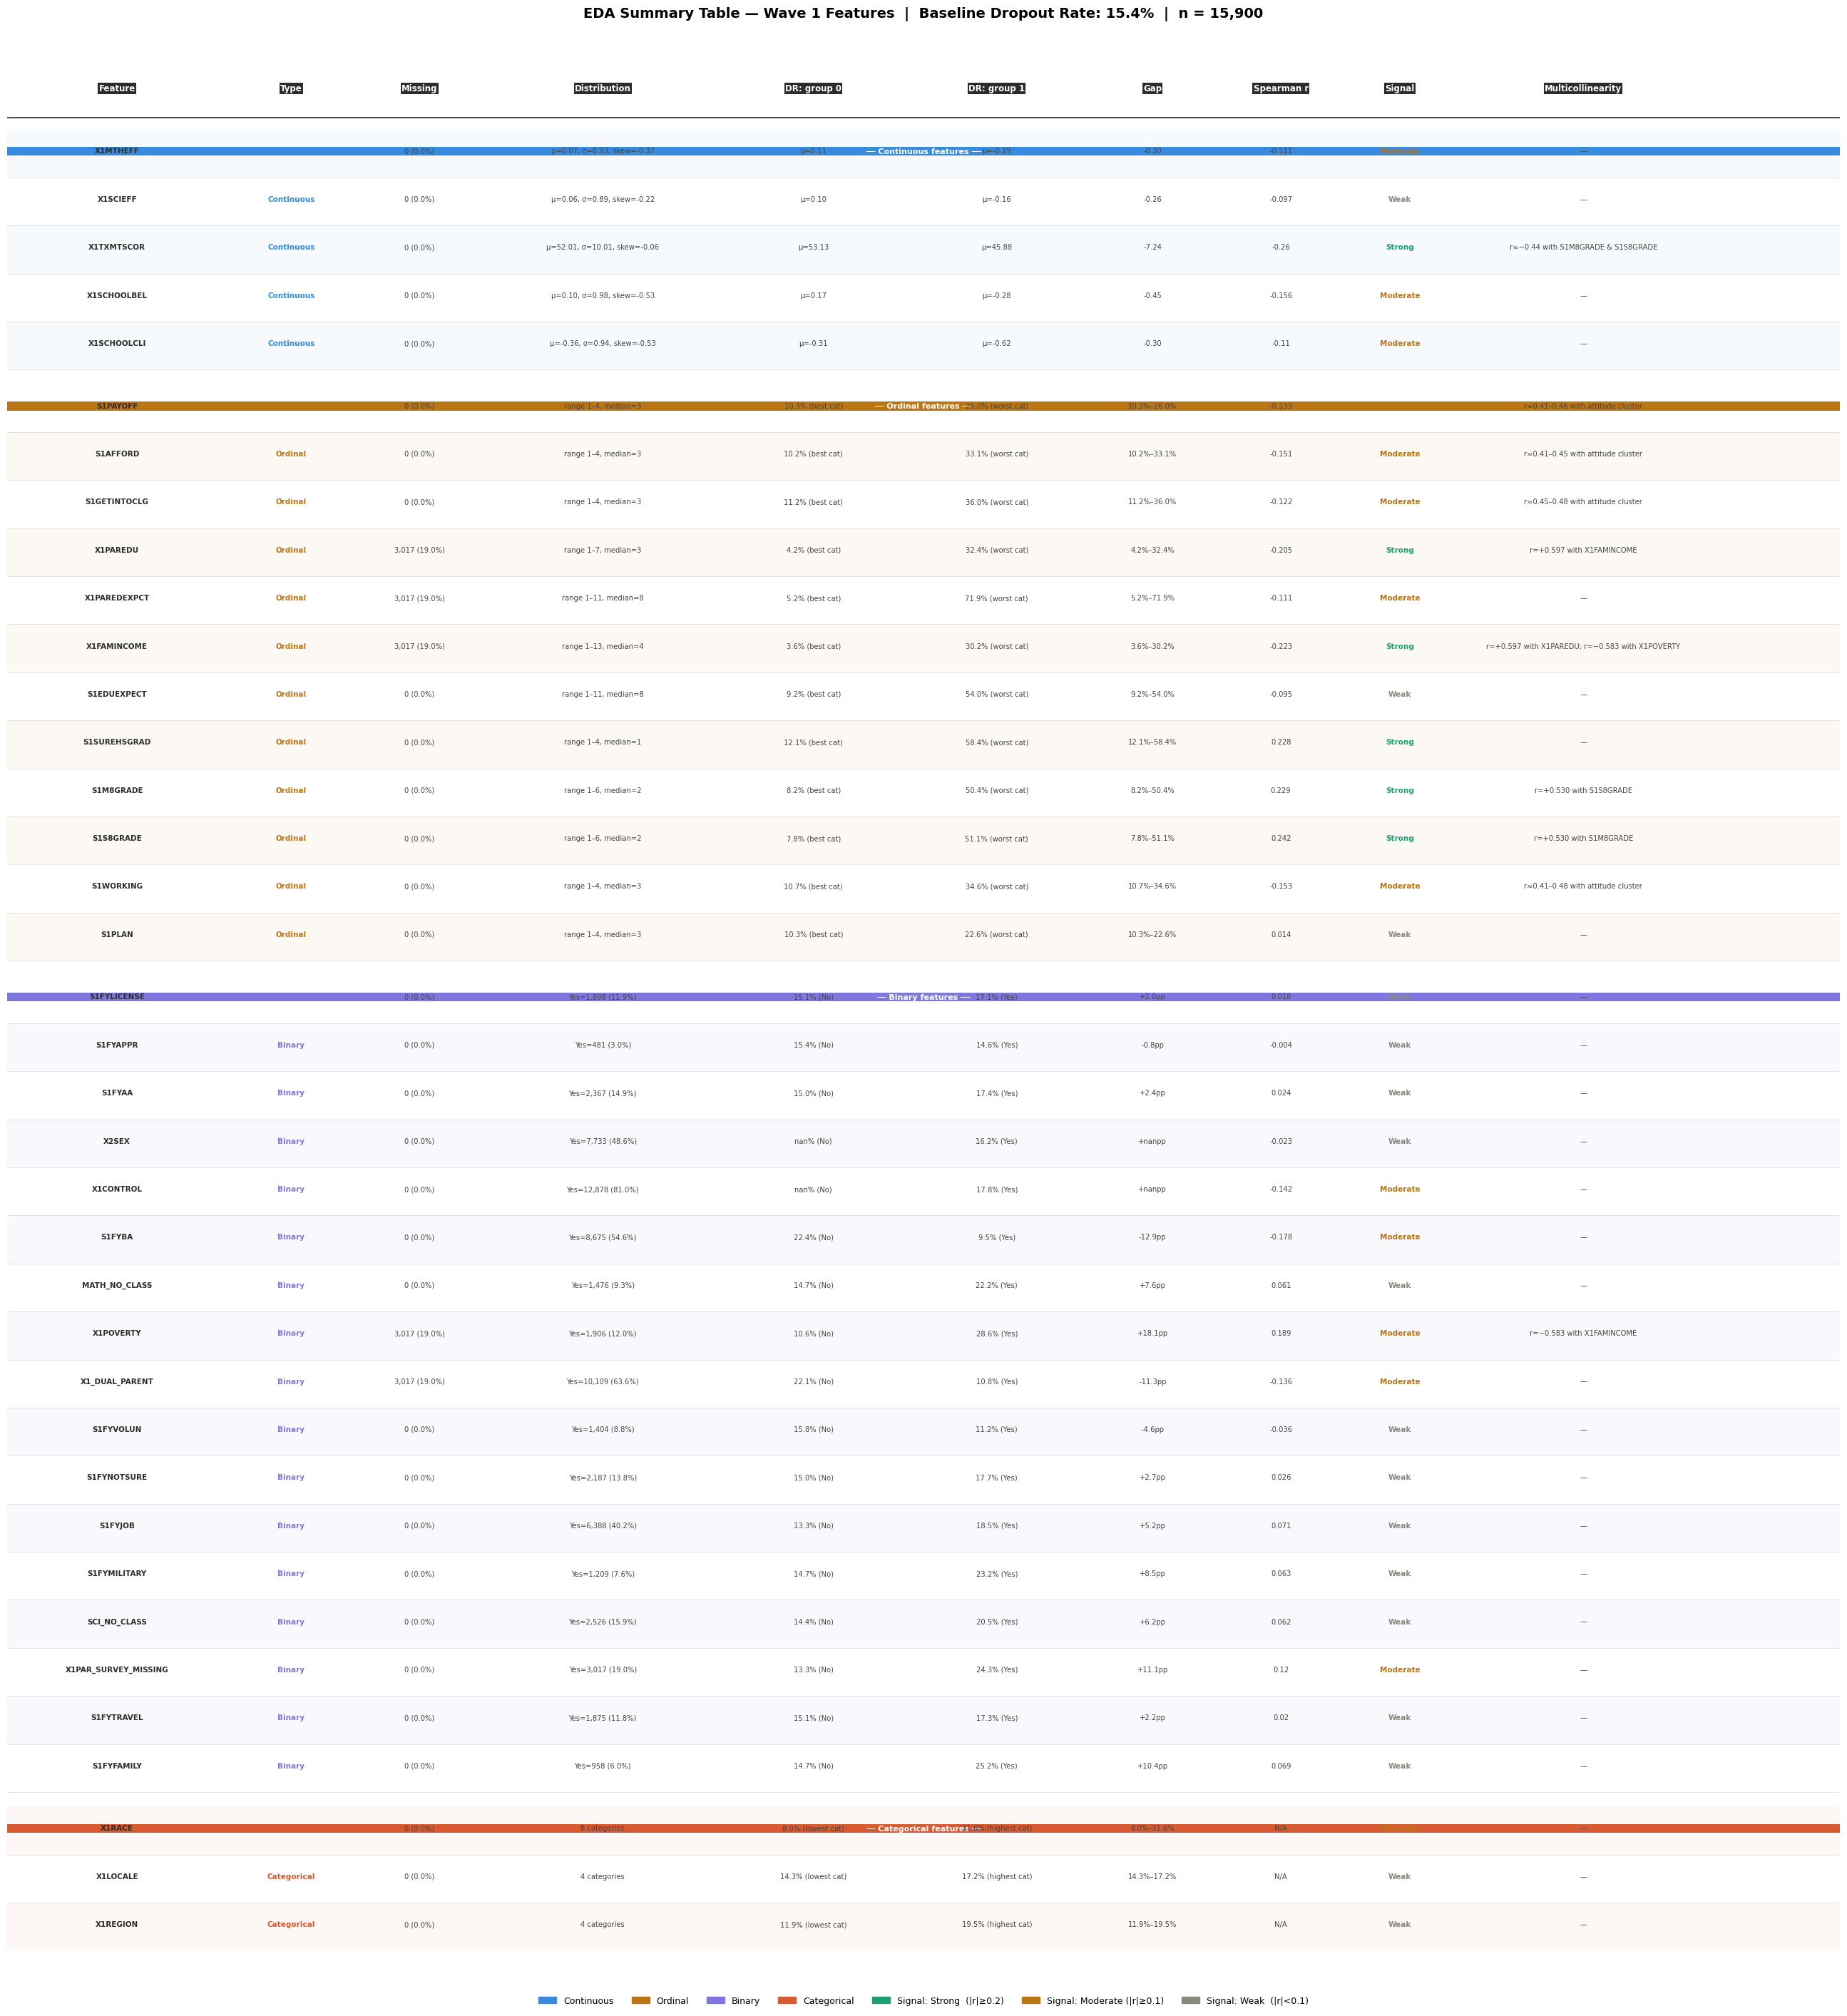

Saved → step7_eda_summary_table.png


In [13]:
from scipy.stats import spearmanr
from matplotlib.colors import to_rgba

BASE_DR = df["X4EVERDROP"].mean() * 100

# ── Feature groups ────────────────────────────────────────────
continuous  = ["X1MTHEFF","X1SCIEFF","X1TXMTSCOR","X1SCHOOLBEL","X1SCHOOLCLI"]
ordinal     = ["S1M8GRADE","S1S8GRADE","X1PAREDU","X1PAREDEXPCT","X1FAMINCOME",
               "S1EDUEXPECT","S1SUREHSGRAD","S1PAYOFF","S1GETINTOCLG","S1AFFORD",
               "S1WORKING","S1PLAN"]
binary      = ["X1PAR_SURVEY_MISSING","X1_DUAL_PARENT","X1POVERTY","MATH_NO_CLASS",
               "SCI_NO_CLASS","X1CONTROL","X2SEX","S1FYAA","S1FYBA","S1FYLICENSE",
               "S1FYAPPR","S1FYMILITARY","S1FYJOB","S1FYFAMILY","S1FYTRAVEL",
               "S1FYVOLUN","S1FYNOTSURE"]
categorical = ["X1RACE","X1LOCALE","X1REGION"]

# ── Missing handling recommendations (from Step 2) ───────────
HANDLING = {
    "X1MTHEFF"             : "Fill NaN → 0; keep MATH_NO_CLASS flag",
    "X1SCIEFF"             : "Fill NaN → 0; keep SCI_NO_CLASS flag",
    "X1PAREDU"             : "Within-group median imputation",
    "X1PAREDEXPCT"         : "Within-group median imputation",
    "X1FAMINCOME"          : "Within-group median imputation",
    "X1_DUAL_PARENT"       : "Within-group median imputation",
    "X1POVERTY"            : "Within-group median imputation",
}

# ── Multicollinearity flags (from Step 6) ────────────────────
MULTICOLL = {
    "S1M8GRADE"    : "r=+0.530 with S1S8GRADE",
    "S1S8GRADE"    : "r=+0.530 with S1M8GRADE",
    "X1PAREDU"     : "r=+0.597 with X1FAMINCOME",
    "X1FAMINCOME"  : "r=+0.597 with X1PAREDU; r=−0.583 with X1POVERTY",
    "X1POVERTY"    : "r=−0.583 with X1FAMINCOME",
    "S1PAYOFF"     : "r≈0.41–0.46 with attitude cluster",
    "S1GETINTOCLG" : "r≈0.45–0.48 with attitude cluster",
    "S1AFFORD"     : "r≈0.41–0.45 with attitude cluster",
    "S1WORKING"    : "r≈0.41–0.48 with attitude cluster",
    "X1TXMTSCOR"   : "r≈−0.44 with S1M8GRADE & S1S8GRADE",
}

# ── Key multivariate interaction notes (from Step 5) ─────────
INTERACTION = {
    "S1M8GRADE"    : "× S1SUREHSGRAD: 7%–70% range",
    "S1SUREHSGRAD" : "× S1M8GRADE: 7%–70% range",
    "X1PAREDU"     : "× X1POVERTY: 5.7%–36.6% range",
    "X1POVERTY"    : "× X1PAREDU & S1EDUEXPECT amplifier",
    "S1EDUEXPECT"  : "× X1POVERTY: 8.4%–44.0% range",
    "X1PAREDEXPCT" : "Independent of S1EDUEXPECT (r=+0.127); parent expectations dominate",
    "X1RACE"       : "× X1POVERTY: Am. Indian +39pp under poverty",
    "X1FAMINCOME"  : "Inverse SES gradient; poverty amplifies all levels",
    "X1SCHOOLBEL"  : "× S1M8GRADE: low belonging compounds poor grades (55% below-D)",
    "S1PLAN"       : "× S1EDUEXPECT: no plan only risky for low-expectation students",
    "S1FYBA"       : "Strongest protective S1FY* flag (r=−0.178, −12.9pp)",
    "S1FYFAMILY"   : "Signal largely poverty-driven (above poverty: 16.0%)",
    "S1FYMILITARY" : "Signal largely poverty-driven (above poverty: 15.8%)",
}

# ── Build summary rows ────────────────────────────────────────
rows = []

def signal_strength(r_val):
    if r_val == "N/A":
        return "—"
    r = abs(float(r_val))
    return "Strong" if r >= 0.2 else "Moderate" if r >= 0.1 else "Weak"

# Continuous
for col in continuous:
    d   = df[col]
    d0  = df.loc[df["X4EVERDROP"]==0, col].dropna()
    d1  = df.loc[df["X4EVERDROP"]==1, col].dropna()
    sub = df[[col,"X4EVERDROP"]].dropna()
    r, _ = spearmanr(sub[col], sub["X4EVERDROP"])
    miss_n = d.isnull().sum()
    rows.append({
        "Feature"           : col,
        "Type"              : "Continuous",
        "Missing"           : f"{miss_n:,} ({miss_n/len(df)*100:.1f}%)",
        "Distribution"      : f"μ={d.mean():.2f}, σ={d.std():.2f}, skew={d.skew():.2f}",
        "DR: group 0"       : f"μ={d0.mean():.2f}",
        "DR: group 1"       : f"μ={d1.mean():.2f}",
        "Gap"               : f"{d1.mean()-d0.mean():+.2f}",
        "Spearman r"        : round(r, 3),
        "Signal"            : signal_strength(r),
        "Multicollinearity" : MULTICOLL.get(col, "—"),
        "Key interaction"   : INTERACTION.get(col, "—"),
        "Missing handling"  : HANDLING.get(col, "Complete — no action needed"),
    })

# Binary
for col in binary:
    d   = df[col]
    dr0 = df.loc[df[col]==0, "X4EVERDROP"].mean()*100
    dr1 = df.loc[df[col]==1, "X4EVERDROP"].mean()*100
    sub = df[[col,"X4EVERDROP"]].dropna()
    r, _ = spearmanr(sub[col], sub["X4EVERDROP"])
    miss_n = d.isnull().sum()
    rows.append({
        "Feature"           : col,
        "Type"              : "Binary",
        "Missing"           : f"{miss_n:,} ({miss_n/len(df)*100:.1f}%)",
        "Distribution"      : f"Yes={int((d==1).sum()):,} ({(d==1).mean()*100:.1f}%)",
        "DR: group 0"       : f"{dr0:.1f}% (No)",
        "DR: group 1"       : f"{dr1:.1f}% (Yes)",
        "Gap"               : f"{dr1-dr0:+.1f}pp",
        "Spearman r"        : round(r, 3),
        "Signal"            : signal_strength(r),
        "Multicollinearity" : MULTICOLL.get(col, "—"),
        "Key interaction"   : INTERACTION.get(col, "—"),
        "Missing handling"  : HANDLING.get(col, "Complete — no action needed"),
    })

# Ordinal
for col in ordinal:
    d   = df[col]
    sub = df[[col,"X4EVERDROP"]].dropna()
    r, _ = spearmanr(sub[col], sub["X4EVERDROP"])
    grp  = sub.groupby(col)["X4EVERDROP"].mean()*100
    miss_n = d.isnull().sum()
    rows.append({
        "Feature"           : col,
        "Type"              : "Ordinal",
        "Missing"           : f"{miss_n:,} ({miss_n/len(df)*100:.1f}%)",
        "Distribution"      : f"range {int(d.min())}–{int(d.max())}, median={d.median():.0f}",
        "DR: group 0"       : f"{grp.min():.1f}% (best cat)",
        "DR: group 1"       : f"{grp.max():.1f}% (worst cat)",
        "Gap"               : f"{grp.min():.1f}%–{grp.max():.1f}%",
        "Spearman r"        : round(r, 3),
        "Signal"            : signal_strength(r),
        "Multicollinearity" : MULTICOLL.get(col, "—"),
        "Key interaction"   : INTERACTION.get(col, "—"),
        "Missing handling"  : HANDLING.get(col, "Complete — no action needed"),
    })

# Categorical
for col in categorical:
    d   = df[col]
    sub = df[[col,"X4EVERDROP"]].dropna()
    grp  = sub.groupby(col)["X4EVERDROP"].mean()*100
    miss_n = d.isnull().sum()
    rows.append({
        "Feature"           : col,
        "Type"              : "Categorical",
        "Missing"           : f"{miss_n:,} ({miss_n/len(df)*100:.1f}%)",
        "Distribution"      : f"{d.nunique()} categories",
        "DR: group 0"       : f"{grp.min():.1f}% (lowest cat)",
        "DR: group 1"       : f"{grp.max():.1f}% (highest cat)",
        "Gap"               : f"{grp.min():.1f}%–{grp.max():.1f}%",
        "Spearman r"        : "N/A",
        "Signal"            : "Moderate" if grp.max()-grp.min() >= 10 else "Weak",
        "Multicollinearity" : MULTICOLL.get(col, "—"),
        "Key interaction"   : INTERACTION.get(col, "—"),
        "Missing handling"  : HANDLING.get(col, "Complete — no action needed"),
    })

summary_df = pd.DataFrame(rows)

# ── CSV export ────────────────────────────────────────────────
summary_df.to_csv("step7_eda_summary.csv", index=False)
print("Saved → step7_eda_summary.csv")

# ── Console print ─────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"  EDA SUMMARY TABLE   |   Baseline dropout rate: {BASE_DR:.1f}%")
print(f"  Total features: {len(summary_df)}   |   n = {len(df):,} students")
print(f"{'='*80}")
display_cols = ["Feature","Type","Missing","Distribution",
                "DR: group 0","DR: group 1","Gap","Spearman r","Signal"]
print(summary_df[display_cols].to_string(index=False))

print(f"\n--- Signal strength breakdown ---")
print(summary_df["Signal"].value_counts().to_string())

# ── Visual table ──────────────────────────────────────────────
SIGNAL_COLORS = {
    "Strong"   : "#1D9E75",
    "Moderate" : "#BA7517",
    "Weak"     : "#888780",
}
TYPE_COLORS = {
    "Continuous" : "#378ADD",
    "Ordinal"    : "#BA7517",
    "Binary"     : "#7F77DD",
    "Categorical": "#D85A30",
}

fig, ax = plt.subplots(figsize=(26, 28))
ax.set_axis_off()
fig.suptitle(
    f"EDA Summary Table — Wave 1 Features  |  Baseline Dropout Rate: {BASE_DR:.1f}%  |  n = {len(df):,}",
    fontsize=14, fontweight="bold", y=0.995
)

disp_cols = ["Feature","Type","Missing","Distribution",
             "DR: group 0","DR: group 1","Gap","Spearman r","Signal","Multicollinearity"]

col_widths = [0.12, 0.07, 0.07, 0.13, 0.10, 0.10, 0.07, 0.07, 0.06, 0.14]
col_starts = [sum(col_widths[:i]) for i in range(len(col_widths))]

n_rows = len(summary_df)
row_h  = 1.0 / (n_rows + 2)
y_top  = 0.97

# ── Header row ────────────────────────────────────────────────
for j, (colname, xpos) in enumerate(zip(disp_cols, col_starts)):
    ax.text(xpos + col_widths[j]*0.5, y_top,
            colname, ha="center", va="center",
            fontsize=8.5, fontweight="bold",
            transform=ax.transAxes,
            bbox=dict(boxstyle="square,pad=0.1", fc="#2C2C2A", ec="none"))
    ax.texts[-1].set_color("white")

ax.plot([0, 1], [y_top - row_h*0.6, y_top - row_h*0.6],
        color="#2C2C2A", linewidth=1.2, transform=ax.transAxes)

# ── Data rows ─────────────────────────────────────────────────
type_order = ["Continuous","Ordinal","Binary","Categorical"]
sorted_df  = summary_df.copy()
sorted_df["_type_order"] = sorted_df["Type"].map({t:i for i,t in enumerate(type_order)})
sorted_df  = sorted_df.sort_values("_type_order").reset_index(drop=True)

prev_type = None
row_y = y_top - row_h

for idx, row in sorted_df.iterrows():
    if row["Type"] != prev_type:
        ax.add_patch(plt.Rectangle(
            (0, row_y - row_h*0.4), 1, row_h*0.18,
            transform=ax.transAxes, fc=TYPE_COLORS[row["Type"]],
            ec="none", clip_on=False
        ))
        ax.text(0.5, row_y - row_h*0.4 + row_h*0.09,
                f"── {row['Type']} features ──",
                ha="center", va="center",
                fontsize=8, fontweight="bold",
                color="white", transform=ax.transAxes)
        row_y -= row_h * 0.3
        prev_type = row["Type"]

    bg_alpha = 0.04 if idx % 2 == 0 else 0.0
    ax.add_patch(plt.Rectangle(
        (0, row_y - row_h*0.55), 1, row_h,
        transform=ax.transAxes,
        fc=TYPE_COLORS[row["Type"]], alpha=bg_alpha,
        ec="none", clip_on=False
    ))

    for j, colname in enumerate(disp_cols):
        val = str(row[colname])
        xpos = col_starts[j] + col_widths[j] * 0.5

        if colname == "Signal":
            sig_color = SIGNAL_COLORS.get(val, "#888780")
            ax.text(xpos, row_y, val,
                    ha="center", va="center",
                    fontsize=7.5, fontweight="bold",
                    color=sig_color, transform=ax.transAxes)
        elif colname == "Type":
            ax.text(xpos, row_y, val,
                    ha="center", va="center",
                    fontsize=7.5, fontweight="bold",
                    color=TYPE_COLORS.get(val, "#2C2C2A"),
                    transform=ax.transAxes)
        elif colname == "Feature":
            ax.text(xpos, row_y, val,
                    ha="center", va="center",
                    fontsize=7.5, fontweight="bold",
                    color="#2C2C2A", transform=ax.transAxes)
        else:
            ax.text(xpos, row_y, val,
                    ha="center", va="center",
                    fontsize=7.2, color="#444441",
                    transform=ax.transAxes)

    ax.plot([0, 1], [row_y - row_h*0.55, row_y - row_h*0.55],
            color="#D3D1C7", linewidth=0.4, transform=ax.transAxes)

    row_y -= row_h

# ── Legend ────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=TYPE_COLORS["Continuous"],  label="Continuous"),
    mpatches.Patch(color=TYPE_COLORS["Ordinal"],     label="Ordinal"),
    mpatches.Patch(color=TYPE_COLORS["Binary"],      label="Binary"),
    mpatches.Patch(color=TYPE_COLORS["Categorical"], label="Categorical"),
    mpatches.Patch(color=SIGNAL_COLORS["Strong"],    label="Signal: Strong  (|r|≥0.2)"),
    mpatches.Patch(color=SIGNAL_COLORS["Moderate"],  label="Signal: Moderate (|r|≥0.1)"),
    mpatches.Patch(color=SIGNAL_COLORS["Weak"],      label="Signal: Weak  (|r|<0.1)"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=7, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("step7_eda_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step7_eda_summary_table.png")

## Key Takeaways from Step 7 — EDA Summary Table

Across all 37 features, the signal landscape breaks down into three tiers:

**Strong signal (6 features, |r| ≥ 0.2)**
- `X1TXMTSCOR` (r = −0.260), `X1FAMINCOME` (r = −0.223), `X1PAREDU` (r = −0.205), `S1SUREHSGRAD` (r = +0.228), `S1M8GRADE` (r = +0.229), `S1S8GRADE` (r = +0.242).
- They span academic performance, SES, and graduation attitude — no single domain dominates.

**Moderate signal (14 features, 0.1 ≤ |r| < 0.2)**
- School engagement: `X1SCHOOLBEL` (r = −0.156), `X1SCHOOLCLI` (r = −0.110)
- College attitudes: `S1AFFORD` (r = −0.151), `S1WORKING` (r = −0.153), `S1PAYOFF` (r = −0.133), `S1GETINTOCLG` (r = −0.122)
- Structural: `X1_DUAL_PARENT` (r = −0.136), `X1CONTROL` (r = −0.142), `S1FYBA` (r = −0.178)
- Risk flags: `X1POVERTY` (r = +0.189), `X1PAR_SURVEY_MISSING` (r = +0.120)
- Other: `X1MTHEFF` (r = −0.111), `X1PAREDEXPCT` (r = −0.111)
- These features will add real value in combination, especially in tree-based models.

**Weak signal by linear correlation (17 features)**
- `X1SCIEFF`, `S1EDUEXPECT`, `S1PLAN`, `MATH_NO_CLASS`, `SCI_NO_CLASS`, `X2SEX`, and all remaining S1FY* flags except `S1FYBA`.
- Weak Spearman r does not mean useless. `MATH_NO_CLASS` (+7.6pp) and `SCI_NO_CLASS` (+6.2pp) showed clear bivariate gaps. `S1EDUEXPECT` produces a 44% dropout rate when combined with poverty. `S1FYFAMILY` (+10.4pp) and `S1FYMILITARY` (+8.5pp) show real bivariate gaps despite low r — their signal is conditional on poverty, not linear. These features should be retained and evaluated by non-linear methods.
- Note: `X1CONTROL` and `X2SEX` show `nan%` in the "DR: group 0" column because they are encoded as 1/2 rather than 0/1 — the dropout rate comparison still works through the Spearman r and the bivariate analysis from Step 4.

**Multicollinearity watch list (3 confirmed pairs, |r| > 0.5)**
- `S1M8GRADE` × `S1S8GRADE` (r = +0.530): consistent cross-subject performance — both can be kept as they are not perfectly redundant.
- `X1PAREDU` × `X1FAMINCOME` (r = +0.597): strongest SES collinearity. Drop one in linear models; both can stay in tree models. `X1POVERTY` is the simplest SES representative if only one is kept.
- `X1FAMINCOME` × `X1POVERTY` (r = −0.583): poverty is a threshold derived from income — prefer one over the other in linear models.
- `S1EDUEXPECT` × `X1PAREDEXPCT` were expected to be collinear but confirmed at only r = +0.127 — both should be retained as they measure different things.
- The four attitude variables (`S1PAYOFF`, `S1GETINTOCLG`, `S1AFFORD`, `S1WORKING`) sit in the 0.41–0.48 near-threshold zone with each other — no single pair exceeds 0.5 but their combined redundancy may suppress individual coefficients in regularised models.

## Feature Selection

**Final dataset:** 23 features + target (`X4EVERDROP`) | 15,900 students | Baseline dropout rate: 15.4%

---

### Continuous Features (5)

| Feature | Justification |
|---|---|
| `X1TXMTSCOR` | Strongest continuous predictor (r = −0.260, Δμ = −7.24). Dropout students score nearly 7.5 points lower on average with clear distributional separation in KDE analysis. The most reliable single numeric signal in the dataset. |
| `X1MTHEFF` | Math self-efficacy (r = −0.111). Captures students' belief in their own academic ability — a dimension distinct from actual test performance. Dropout students score meaningfully lower (μ = −0.19 vs +0.11). |
| `X1SCIEFF` | Science self-efficacy (r = −0.097). Mirrors the math efficacy pattern and adds independent coverage of academic self-perception across subjects. |
| `X1SCHOOLBEL` | School belonging (r = −0.156), second strongest continuous predictor. Dropout students feel significantly less connected to school (μ = −0.28 vs +0.17). Step 5 confirmed it compounds poor grades — below-D students with low belonging reach 55% dropout. |
| `X1SCHOOLCLI` | School climate (r = −0.110). The entire sample rates climate negatively (mean = −0.36), and dropout students rate it even lower (μ = −0.62). Captures school-level environment effects not measured by individual belonging. |

---

### Ordinal Features (10)

| Feature | Justification |
|---|---|
| `S1M8GRADE` | r = +0.229 — strong monotonic dropout gradient from 8.2% (A) to 50.4% (below D). One of the top 3 strongest predictors overall. Step 5 confirmed a 7%–70% interaction range with graduation certainty. |
| `S1S8GRADE` | r = +0.242 — strongest ordinal correlate with dropout. Mirrors the math grade pattern across science (7.8%–51.1% gradient). Retained alongside math grade as the two are correlated (r = +0.530) but not redundant — each adds independent signal. |
| `X1PAREDU` | r = −0.205 — students whose parents didn't finish high school drop out at 32.4% vs. 4.2% for PhD/MD/Law-educated parents (nearly 8× ratio). Step 5 confirmed poverty amplifies this gradient further. `X1FAMINCOME` was excluded to avoid multicollinearity (r = +0.597 with `X1PAREDU`); `X1POVERTY` is retained as the simpler SES threshold. |
| `X1PAREDEXPCT` | Parent expectations show the steepest dropout gradient of any feature — 71.9% dropout at the lowest category, the single highest rate in the entire analysis. Step 5 confirmed parent expectations dominate student expectations independently (r between the two = +0.127, confirming they are not redundant). |
| `S1EDUEXPECT` | Despite weak linear correlation (r = −0.095 — an encoding artefact from category 11 "Don't know"), this is among the strongest bivariate predictors. Students expecting only HS or less drop out at 54%. Step 5 showed that even high-expectation students face 20.2% dropout under poverty, making this feature essential for the expectations × poverty interaction. |
| `S1SUREHSGRAD` | r = +0.228 — "Probably won't graduate" group reaches 58.4% dropout, higher than "Very sure won't" (51.8%). Drives the grades × certainty interaction (Step 5: 7%–70% range). Low-variance but extremely high-signal in the minority group. |
| `S1PAYOFF` | Pessimism about school value shows a clean 2× dropout gradient (21.1% Strongly agree → 10.3% Strongly disagree). Part of the college attitude cluster — captures whether students believe education is worth the investment. |
| `S1GETINTOCLG` | Perceived college access — students who strongly agree they won't get in drop out at 36.0%, the steepest gradient in the attitude cluster. Captures a distinct barrier (perceived access) from `S1AFFORD` (perceived cost). |
| `S1AFFORD` | Perceived inability to afford college (33.1% dropout for Strongly agree). Step 5 confirmed poverty amplifies this — students below poverty who also feel they can't afford college face compounded risk. |
| `S1WORKING` | Work-over-college orientation shows a near-binary dropout pattern: Strongly agree/Agree = 34.6%/33.5% vs. Disagree = 14.4%. Captures students whose priorities compete directly with staying in school. |

---

### Binary Features (8)

| Feature | Justification |
|---|---|
| `X1PAR_SURVEY_MISSING` | MNAR (Missing Not At Random) flag — parents who skipped the survey are associated with 24.3% dropout vs. 13.3% for respondents (+11.1pp). The missingness itself is informative and must be retained as a feature rather than treated as noise. |
| `X1_DUAL_PARENT` | Household structure — single-parent students drop out at 22.1% vs. 10.8% for dual-parent households (−11.3pp). Step 5 confirmed this operates independently of poverty: both single and dual-parent households show similar poverty amplification (+17pp and +15.4pp respectively), meaning the two features contribute separately. |
| `X1POVERTY` | Strongest binary predictor (+18.1pp, 28.6% vs. 10.6%) and a universal risk amplifier confirmed across every racial group, education level, math score quartile, and expectation tier in Step 5. Retained over `X1FAMINCOME` as the simpler, more direct SES threshold. |
| `MATH_NO_CLASS` | Students with no 9th grade Math course drop out at 22.2% (+7.6pp). Captures structural academic disengagement — absence from a core course is a behavioral signal that goes beyond attitudinal measures. |
| `SCI_NO_CLASS` | Students with no 9th grade Science course drop out at 20.5% (+6.2pp). Retained alongside `MATH_NO_CLASS` as the two capture course avoidance across different subjects and are not redundant. |
| `S1FYFAMILY` | 25.2% dropout rate (+10.4pp) — the largest gap among S1FY* flags. Step 5 confirmed this has some poverty overlap (40.7% below poverty vs. 16.0% above), but the 16.0% above-poverty rate is still above baseline, suggesting family obligations carry independent risk beyond economic hardship. |
| `S1FYMILITARY` | 23.2% dropout rate (+8.5pp). Step 5 showed above-poverty military-path students sit at 15.8% (near baseline), meaning most of the signal is poverty-driven — however, the military path represents a distinct post-HS orientation not captured by any other retained feature, justifying inclusion. |
| `X1CONTROL` | Public vs. private school type — 17.8% vs. 4.8% dropout (−13.0pp gap), one of the largest categorical gaps in the dataset. Acknowledged to be SES-confounded, but captures school-level structural differences not fully explained by individual-level SES variables. |

---

### Features Excluded and Why

| Feature | Reason for exclusion |
|---|---|
| `X1FAMINCOME` | Multicollinear with both `X1PAREDU` (r = +0.597) and `X1POVERTY` (r = −0.583). `X1POVERTY` is retained as the simpler SES threshold; `X1PAREDU` covers the education dimension. |
| `S1PLAN` | Weak linear signal (r = +0.014). Step 4 showed "No plan" students sit exactly at baseline (15.4%) — the feature's signal comes entirely from the career-only subgroup (22.6%), which is partially captured by `S1WORKING` and expectation variables. |
| `S1FYBA` | Despite a strong protective signal (r = −0.178, −12.9pp), the college-going intention is already well-represented by `S1EDUEXPECT`, `X1PAREDEXPCT`, and the attitude cluster. Adding `S1FYBA` would introduce redundancy with those features. |
| `X1RACE`, `X1LOCALE`, `X1REGION` | One-hot encoded during preprocessing but excluded from the final feature set. Racial disparities are substantially driven by poverty (confirmed Step 5) and are better controlled through SES features. Geographic variables showed modest gaps (locale: 2.9pp, region: 7.6pp) insufficient to justify the dimensionality increase from dummy encoding. |
| `S1FYAA`, `S1FYLICENSE`, `S1FYAPPR`, `S1FYTRAVEL`, `S1FYNOTSURE` | All under 3pp bivariate gap and near-zero Spearman r. No meaningful signal in any analysis step. |
| `S1FYVOLUN` | Mildly protective (−4.6pp) but weak and not independently informative once other features are included. |
| `S1FYBA`, `S1FYJOB` | Covered by attitude and expectation variables already in the model. |
| `X2SEX` | 1.7pp gap — not practically meaningful as a standalone predictor. |
| `STU_ID` | Row identifier — no predictive value. |

# Saving outputs

In [14]:
import os
import zipfile
from google.colab import files

zip_name = "png_files.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for fname in os.listdir("."):
        if os.path.isfile(fname) and fname.endswith(".png"):
            z.write(fname)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>